# [이론] 분해와 정상성 — 자기상관과 ADF·KPSS 검정

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## 0. 오늘 배울 것

<div style="background:linear-gradient(135deg,#faf6ee,#f0e6d2);color:#5a4a33;padding:40px;border-radius:12px;border:1px solid #e0d5bd">
<h1 style="color:#5a4a33;margin:0 0 12px 0">시계열 데이터의 문법 — 분해와 정상성</h1>
<div style="font-size:1.08em;line-height:1.7">오늘부터 여섯 번의 수업 동안 여러분은 <b>서울 공유자전거 운영팀의 수요예측 담당자</b>입니다. 첫 출근일에 받은 파일은 1년치 시간당 대여 기록 8,760행입니다.<br/><br/>
팀장이 다음과 같이 질문합니다. <b>"대여 수요에 어떤 계절 주기가 있고, 달마다 수요 수준이 달라지는 이 자료를 그대로 예측 모형에 입력해도 됩니까?"</b></div>
</div>

본문은 필수이고, 접힌 상자(「자세히」·「더 깊이」)는 선택입니다.

수업에서는 「오늘의 순서」 표와 주제마다 나오는 그림, 마지막 9번의 「오늘의 정리」를 함께 보고 본문은 각자 읽습니다.

## 0. 오늘 배울 것

첫 출근일에 받은 8,760행은 시각 하나마다 그 시각의 대여 대수 하나가 있고, 시간 순서대로 늘어서 있습니다. 이렇게 시간 순서대로 늘어선 값 한 줄을 앞으로 **계열**이라고 부르겠습니다.

이 계열을 석 달씩 넷으로 나누면 12～2월·3～5월·6～8월·9～11월입니다. 네 묶음의 평균은 차례로 225.5·730.0·1,034.1·819.6대/시간입니다. 1,034.1 ÷ 225.5 = 4.6 이라 여름 석 달이 겨울 석 달의 4.6배입니다.

그 차이가 큰지는 예측 오차로 확인합니다. 먼저 8,760시간을 전체 평균 704.6대/시간 하나로 예측합니다. 시각마다 실제 값과 704.6의 차이를 구하고, 부호 없이 크기만 남깁니다. 그 8,760개를 평균한 값이 520대/시간이고, 이것을 평균 절대 오차라고 부릅니다.

이번에는 석 달 묶음 넷의 평균으로 계절마다 다르게 예측합니다. 같은 방법으로 구한 오차가 428대/시간입니다. 계절을 넷으로 나눈 것만으로 한 시각의 오차가 92대 줄었습니다. 평균 하나는 이 계열을 대표하지 못합니다.

> **오늘의 질문 — 이 대여 수요의 계절 주기는 무엇이고, 이 계열을 그대로 예측 모형에 입력해도 되는가.**

**계절 주기(seasonal period)** 는 봄·여름 같은 철과 상관없이 같은 형태가 되풀이되는 간격입니다. 한 계열에 둘 이상 겹칠 수 있습니다. 24시간과 1년이 뚜렷하게 겹친 호주 빅토리아주 전력 수요를 먼저 봅니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/edemand-1.png" width="640" height="288"/>
<p align="center"><em>▲ 2014년 호주 빅토리아주 30분 간격 전력 수요 — 1월에는 가장 높은 값이 며칠에만 나타나고 7월에는 높은 수준이 여러 주 이어진다. 1월의 모습은 7월과 다르고, 1월과 같은 모습은 이듬해 1월에야 다시 온다. 이 1년이 1년 주기다 (출처: fpp3, otexts.com/fpp3)</em></p>

세로축 `GW` 가 전력 수요, 가로축 `Time [30m]` 이 시각입니다. 세로선 하나가 그 하루의 30분 간격 값 48개입니다. 아래 끝이 그날 최솟값, 위 끝이 그날 최댓값입니다. 그 세로선 365개, 곧 365일이 나란히 이어져 1년을 이룹니다.

1월의 가장 높은 날은 위 끝이 9,300 근처입니다. 4월의 낮은 날은 아래 끝이 2,900 근처입니다. 높은 쪽이 낮은 쪽의 3배가 넘습니다.

하루 안의 차이가 365번 되풀이된 것이 24시간 주기입니다. 세로선 전체가 1월과 7월에 높고 4월과 10월에 낮은 것이 1년 주기입니다. 빅토리아주는 남반구라 1월이 여름입니다.

## 오늘의 순서

왜 이 차례인가. 한 곡선을 단순한 곡선 몇 개로 가르면 그중 무엇이 되풀이되는지 잴 수 있습니다. 이 계열에서 비교하는 두 간격은 24시간과 7일입니다. 그 되풀이를 확인한 뒤에야 이 자료를 모형에 그대로 입력해도 되는지 판정합니다.

| 주제 | 새로 정의하는 용어 |
|---|---|
| 1. 행 순서가 정보인 자료 | 시계열 · 독립동일분포 가정 · 자기의존 · 시간 그림 |
| 2. 시간 인덱스와 관측 간격 | 시간 인덱스 · 관측 간격 · 집계 단위 · 리샘플 · 시차 k |
| 3. 추세·계절 성분·잔차로 나누는 분해 | 추세 · 계절성 · 순환 · 잔차 · 가법과 승법 · 이동평균 · STL |
| 4. 계절 강도: 주기 24와 주기 7의 비교 | 계절 강도 F_S · 측정 구간 · 시각별 프로파일 |
| 5. 자기상관과 ACF | 시차 산점도 · 자기상관 · 자기공분산 · ACF · 백색잡음 · 랜덤워크 · 판정선 |
| 6. 정상성: 언제 측정해도 같은 값이 나오는 성질 | 정상성 · 눈으로 판정하는 3조건 |
| 7. ADF와 KPSS: 귀무가설이 반대인 두 검정 | 단위근 · ADF · KPSS · 임계값 · 판정 조합표 |
| 8. 차분: 비정상을 정상으로 바꾸는 변환 | 레벨 차분 · 계절차분 · 과차분 |
| 9. 이 계열의 판정과 오늘의 정리 | 준비 5단계 · 집계 단위별 변환 |

<details class="lms-extra"><summary>자세히 — 읽기 전에 뜻을 확인할 개념 7가지</summary>

오늘 다루는 내용은 아래 개념 위에 쌓입니다. 뜻이 바로 떠오르지 않는 항목만 읽고 넘어가십시오.

- **귀무가설과 p값, 유의수준** : 귀무가설은 반증되기 전까지 참이라고 두는 문장이고, p값은 그 문장이 참일 때 관측한 만큼 또는 그보다 더 극단적인 결과가 나올 확률이며, p값이 미리 정한 기준인 유의수준(흔히 5%)보다 작으면 귀무가설을 기각합니다. (통계적 검정과 인과추론)
- **분산과 표준편차** : 값들이 평균에서 떨어진 거리를 제곱해 평균한 값이 분산이고, 그 제곱근이 표준편차입니다. (통계적 검정과 인과추론)
- **표준오차** : 추정값의 표준편차이고, 같은 크기의 표본을 다시 뽑을 때 추정값이 표본마다 얼마나 달라지는지를 나타냅니다. 표준편차가 10인 자료에서 100개를 뽑아 평균을 추정하면 표준오차는 10 ÷ √100 = 1 입니다. (통계적 검정과 인과추론)
- **공분산과 상관계수** : 두 값이 각각의 평균에서 벗어난 편차를 곱해 평균한 값이 공분산이고, 이것을 두 표준편차로 나누어 −1 과 +1 사이로 맞춘 값이 상관계수입니다.
- **정규분포의 95% 구간** : 정규분포에서 평균을 중심으로 가운데 95% 를 차지하는 구간이고, 그 경계는 평균에서 표준편차의 1.96배만큼 떨어진 두 지점입니다. (통계적 검정과 인과추론)
- **로그와 지수함수** : 로그는 곱셈을 덧셈으로 바꾸는 함수이고, 지수함수는 그 역연산이어서 덧셈을 곱셈으로 바꿉니다.
- **pandas 의 Series 와 시간 인덱스** : Series 는 값의 나열에 인덱스를 부여한 자료 구조이고, 인덱스가 시각이면 `resample` 로 집계 단위를 바꿀 수 있습니다. (데이터 랭글링)

</details>

## 1. 행 순서가 정보인 자료

**여기서 할 일**

1. 행을 재배열하면 무엇이 사라지는지 확인합니다.
2. 8월 8일 하루의 시간당 값 24개를 두 순서로 대조합니다.
3. 시간 그림에서 볼 것 여섯 가지를 이 계열에 적용합니다.

**계열(series)** 은 값을 하나씩 이어 적은 줄입니다. 날마다 적은 몸무게도, 분기마다 발표하는 매출도 계열입니다.

**시계열(time series)** 은 그 줄의 순서가 시각이고 값과 값 사이 간격이 일정할 때 부르는 이름입니다. 대여 기록은 값 8,760개마다 몇 시의 값인지가 함께 적혀 있고, 값 사이 간격이 모두 1시간입니다.

작은 예는 2018년 8월 8일 세 시각과 하루 전 같은 시각입니다.

| 시각 | 대여 수요(대/시간) |
|---|---|
| 8일 4시 | 183 |
| 8일 17시 | 1,266 |
| 8일 18시 | 2,326 |
| 7일 18시 | 2,274 |

이름 둘을 구분합니다. 하나는 분석의 가정, 하나는 이 자료의 성질입니다.

- **독립동일분포 가정(iid)** — 원어는 independent and identically distributed 입니다. 서로 영향을 주지 않는 것이 독립입니다. 값들이 모두 같은 조건에서 나왔다는 것이 동일분포입니다. 이 가정이 맞으면 어느 값이 몇 번째에 있는지는 값의 크기와 상관없습니다. 그래서 순서를 버려도 잃는 것이 없고, 남는 것은 평균·분산 같은 요약뿐입니다. 위 표의 8일 세 시각(4시·17시·18시)을 재배열해도 평균 1,258.3대/시간은 그대로입니다.
- **자기의존(serial dependence)** — 현재 값이 자신의 과거 값에 의존하는 성질입니다. 8일 18시 2,326 은 하루 전 18시 2,274 와 52대/시간 차이입니다. 바로 앞 17시 1,266 과는 1,060대/시간 차이입니다. 이 하루 24개 값은 평균 995대/시간에서 표준편차 587대/시간만큼 오르내립니다. 52대/시간 차이는 그 표준편차의 10분의 1에도 못 미치고, 1,060대/시간 차이는 1.8배입니다.

가장 닮은 값이 바로 앞이 아니라 하루 전 같은 시각입니다. 24시간마다 같은 모양이 되풀이된다는 신호입니다. 값이 이렇게 규칙적으로 이어져 있으면 관측끼리 영향을 주지 않는다는 독립 가정이 깨집니다. 그래서 이 자료에서는 iid 대신 자기의존을 전제로 분석합니다.

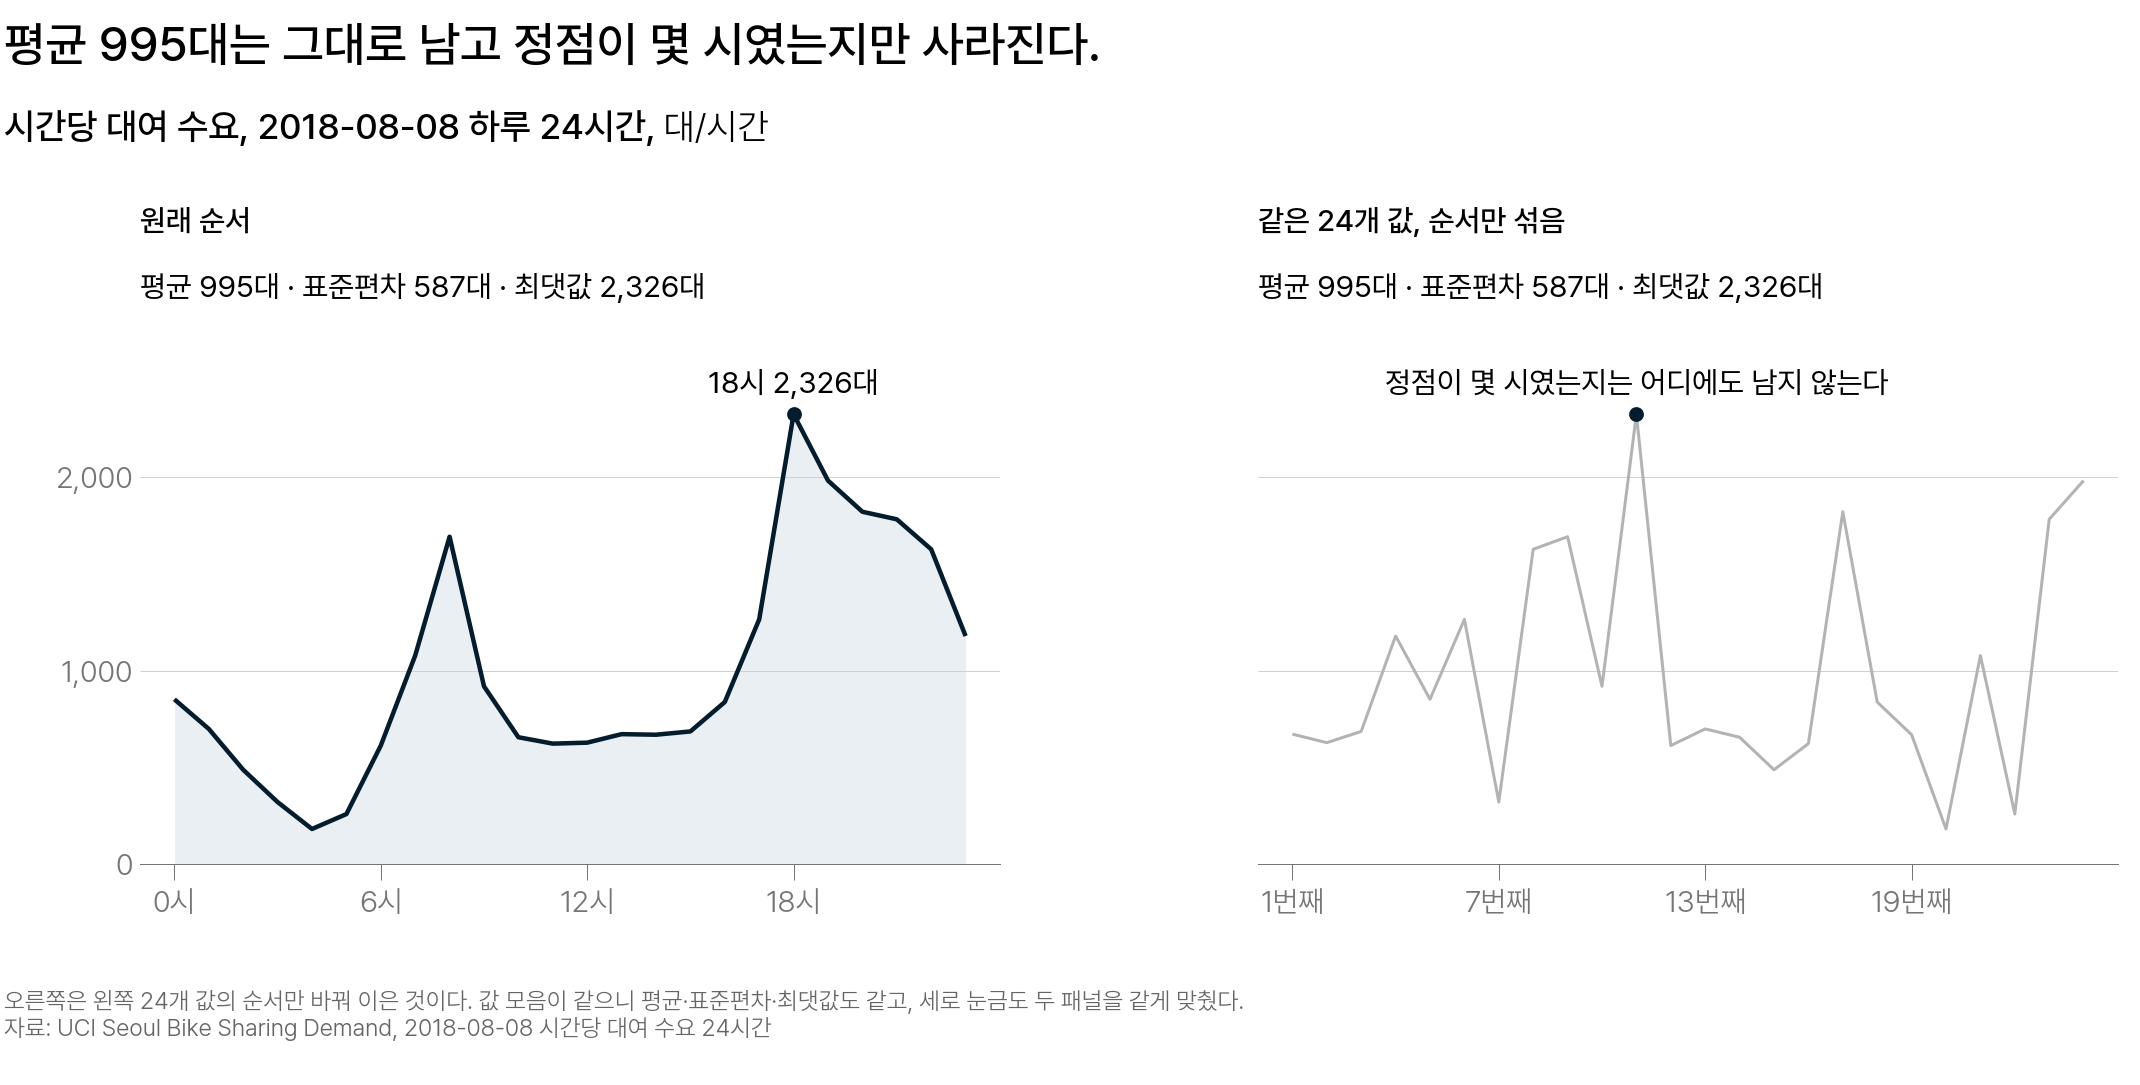

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 8월 8일 하루의 시간당 값 24개 — 왼쪽은 시간 순서대로, 오른쪽은 순서를 무작위로 바꿨다. 평균 995 · 표준편차 587 · 최댓값 2,326대/시간이 같다</em></p>

**원래 순서** 8월 8일 0시부터 23시까지 차례로 이었습니다. 새벽에 가장 낮고 18시에 2,326대/시간으로 가장 높습니다. 하루 중 언제 많이 빌리는가를 묻는다면 답은 18시, 곧 퇴근 무렵입니다.

**순서만 섞음** 같은 8월 8일 하루의 값 24개를 무작위 순서로 이었습니다. 최댓값 2,326대/시간이 섞은 순서에서 11번째 자리에 있습니다. 값은 남고 시각만 없어져 같은 질문에 답하지 못합니다. iid 를 가정하고 분석하면 시각 정보를 쓰지 않으므로, 이 자료는 오른쪽 패널처럼 순서 없는 값 24개가 됩니다.

그래서 첫 단계는 요약통계가 아니라 **시간 그림(time plot)** 입니다. 가로축이 시각, 세로축이 값입니다. 왼쪽 패널이 그 예입니다. 다음은 1년치입니다.

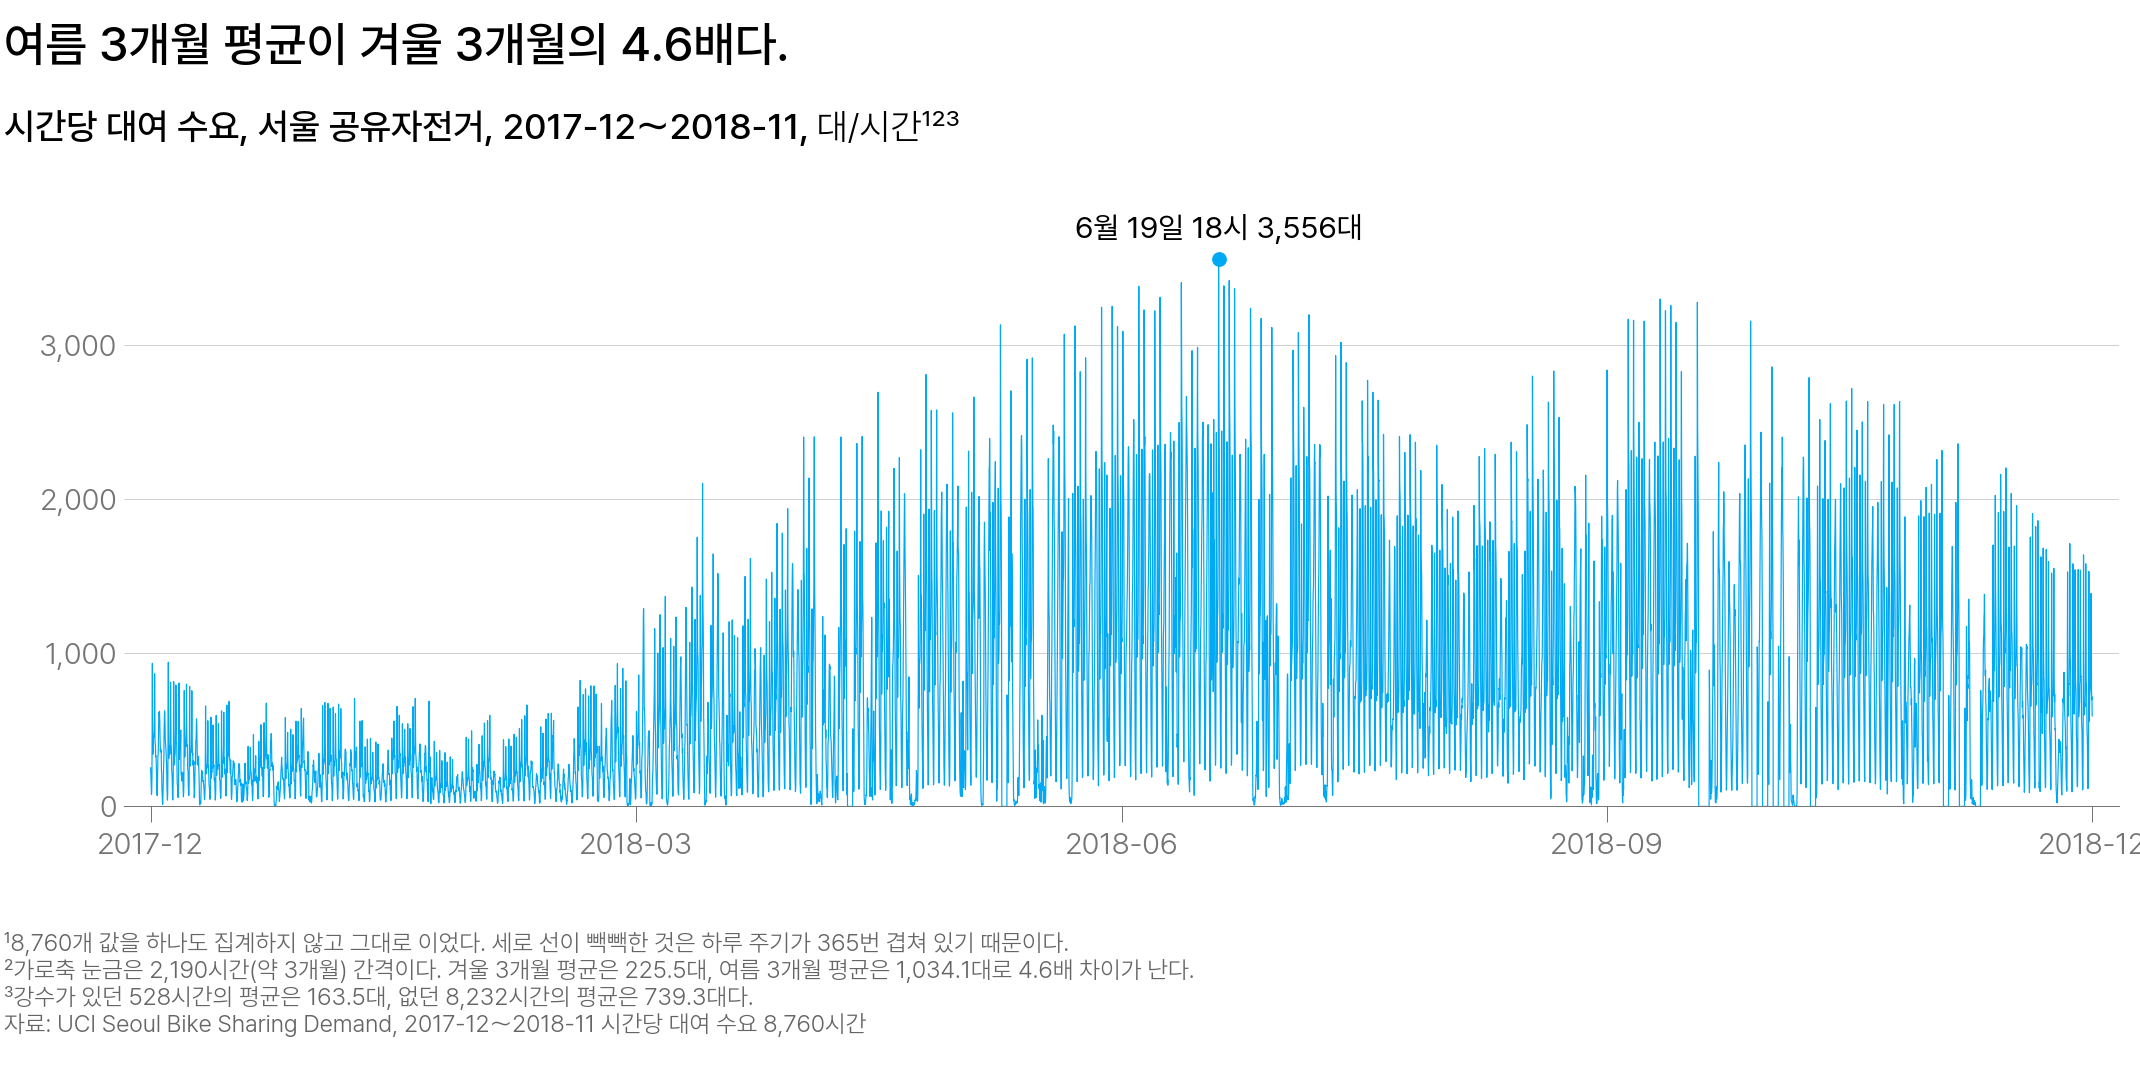

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 1년치 시간 그림, 시간당 대여 수요 8,760시간 — 겨울 구간은 낮고 여름 구간이 높다</em></p>

세로 선 하나가 하루입니다. 새벽에 낮고 저녁에 높은 오르내림이 그 한 선에 있습니다.

겨울 3개월의 평균은 225.5대/시간이고 여름 3개월은 1,034.1대/시간입니다. 1,034.1 ÷ 225.5 = 4.6 이 그림 맨 위 문장의 4.6배입니다.

시간 그림에서 볼 것은 여섯 가지입니다.

| 항목 | 확인할 것 | 이 계열에서 확인한 내용 |
|---|---|---|
| 1. 추세(trend) | 한 방향으로 서서히 움직이는가 | 한 방향은 아니다. 여름까지 4.6배 오른 뒤 내려간다 |
| 2. 계절성(seasonality) | 고정된 주기로 되풀이되는가 | 세로 선 하나의 모양이 24시간마다 되풀이된다 |
| 3. 순환(cycle) | 되풀이되는데 간격이 들쭉날쭉한 변동이 있는가 | 1년치 자료여서 판정할 수 없다 |
| 4. 이상(outlier) | 유독 크거나 작은 시각이 있는가 | 최댓값 6월 19일 18시 3,556대/시간, 0 은 휴무 295시간 |
| 5. 분산(variance) | 변동성이 구간마다 다른가 | 여름의 세로 선이 더 길다. 하루 안 최댓값−최솟값이 겨울에는 평균 483대/시간, 여름에는 2,148대/시간이다 |
| 6. 급변(structural break) | 수준이 갑자기 바뀌는가 | 보이지 않는다 |

3번 **순환(cycle)** 은 2번 계절성과 간격이 다릅니다. 계절성은 24시간마다 오지만, 순환은 경기 순환처럼 한 번은 3년 뒤 다음은 7년 뒤에 옵니다.

4번의 **휴무 295시간** 은 운영 여부 열이 `No` 인 시간이고, 그 0 은 운영하지 않았다는 뜻입니다. 이 시간은 지우지 않고 0 그대로 둡니다. 빼면 1시간 간격이 어긋나기 때문입니다.

<details class="lms-extra"><summary>자세히 — 1년치로 연 주기와 추세를 가를 수 있는가</summary>

여름에 높아졌다 낮아지는 움직임이 해마다 되풀이되는지 보려면 두 번째 해가 필요합니다. 이 자료는 1년치뿐이라 그 되풀이를 확인할 수 없습니다. 그래서 1번 항목에 「한 방향은 아니다」라고만 적었고, 이 자료에서 확인되는 되풀이는 24시간까지입니다.

</details>

**그래서** 계절성이 있으므로 분해로 성분을 나눕니다. 시계열에서는 값과 그 값이 몇 시의 것인지가 함께 있어야 정보입니다.

> **[문제] 시각이 따로 적혀 있지 않고 행 순서에만 시간 정보가 담긴 계열이라면, 행을 무작위로 재배열해도 각 값은 그대로 남으므로 평균·분산이 그대로인 것처럼 분석 결과도 달라지지 않는다.**
>
> O 를 고르고 싶어지는 이유는 「분석 결과」를 요약통계로만 생각했기 때문입니다. 요약통계까지는 맞는 말이지만, 문장이 말하는 범위는 분석 전체입니다. 가장 조심할 점은 순서를 재배열해도 오류 메시지가 뜨지 않는다는 것입니다. 숫자는 그대로 나오고 그 숫자가 틀립니다.
>
> 1. O (맞다)
> 2. X (틀리다)

## 2. 시간 인덱스와 관측 간격

**여기서 할 일**

1. 한 행이 몇 시의 값인지, 행과 행이 몇 시간 차이인지 확인합니다.
2. 시각을 인덱스로 지정하고 간격·중복·순서를 확인합니다.
3. 몇 시간마다 한 값으로 볼지 바꾸는 리샘플과 시차 k 를 정의합니다.

**시간 인덱스(DatetimeIndex)** 는 행의 이름이 시각인 인덱스입니다. 문자열도 정수도 아닙니다. 첫 두 행의 이름은 `2017-12-01 00:00` 과 `2017-12-01 01:00` 입니다.

왜 시각을 이름으로 다는가. 위아래 위치에 맡긴 순서는 정렬 한 번으로 사라집니다. 이름에 적으면 남습니다.

이 주제의 코드 3개는 ▶ 를 눌러 바로 실행할 수 있습니다. 주석에 나오는 `실행 카드` 는 ▶ 가 달린 이 코드 상자입니다.

In [ ]:
import pandas as pd

try:
    raw = load_csv("datasets/SeoulBikeData.csv")            # 실행 카드가 주는 읽기 함수
except NameError:                                           # 이 함수가 없는 곳에서는 원본을 받는다
    SRC = ("https://archive.ics.uci.edu/static/public/560/"
           "seoul+bike+sharing+demand.zip")
    raw = pd.read_csv(SRC, encoding="cp1252", compression="zip")
raw = raw.rename(columns={"Date": "date", "Hour": "hour",
                          "Rented Bike Count": "count"})    # 원본 열 이름을 줄인다
stamp = (pd.to_datetime(raw["date"], format="%d/%m/%Y")     # 01/12/2017 = 2017년 12월 1일
         + pd.to_timedelta(raw["hour"], unit="h"))          # 그 행의 시각을 더한다
hourly = pd.Series(raw["count"].values, index=stamp).sort_index()
print(hourly.head(3))                                       # 첫 세 행 · 행 이름이 시각이다

**관측 간격(sampling interval)** 은 자료가 원래 몇 시간마다 기록되었는가입니다. 앞의 두 행 이름이 1시간 차이이므로 이 계열의 관측 간격은 1시간입니다.

## 빠진 시각, 두 번 기록된 시각, 뒤바뀐 순서가 없는지 확인하기

시각을 인덱스로 지정해도 1시간 간격이 보장되지는 않습니다. 세 가지를 확인합니다.

| 확인할 것 | 무엇을 보는가 | 어긋나면 | 걸리면 하는 일 |
|---|---|---|---|
| 간격 | 두 시각의 차이가 한 종류인가 | 한 행 앞이 1시간 전이 아니게 된다 | 빠진 시각을 채운다 |
| 중복 | 같은 시각이 두 번 있는가 | 같은 시점이 두 번 집계된다 | 한 값으로 합친다 |
| 순서 | 시각이 오름차순인가 | 한 행 앞이 아무 시각이나 된다 | `sort_index()` 로 정렬한다 |

In [ ]:
import pandas as pd

try:
    raw = load_csv("datasets/SeoulBikeData.csv")            # 실행 카드가 주는 읽기 함수
except NameError:                                           # 이 함수가 없는 곳에서는 원본을 받는다
    SRC = ("https://archive.ics.uci.edu/static/public/560/"
           "seoul+bike+sharing+demand.zip")
    raw = pd.read_csv(SRC, encoding="cp1252", compression="zip")
raw = raw.rename(columns={"Date": "date", "Hour": "hour",
                          "Rented Bike Count": "count"})    # 원본 열 이름을 줄인다
stamp = (pd.to_datetime(raw["date"], format="%d/%m/%Y")     # 01/12/2017 = 2017년 12월 1일
         + pd.to_timedelta(raw["hour"], unit="h"))          # 그 행의 시각을 더한다
hourly = pd.Series(raw["count"].values, index=stamp).sort_index()

gaps = hourly.index.to_series().diff().value_counts()   # 간격이 한 종류면 빠진 시각이 없다
dups = hourly.index.duplicated().sum()                  # 0 이어야 한다
ordered = hourly.index.is_monotonic_increasing          # True 여야 한다
print(gaps)
print("중복 시각", dups, "건 · 오름차순", ordered)

세 가지 모두 이상이 없습니다. 간격 한 종류(`0 days 01:00:00`), 중복 0건, 오름차순 `True` 입니다. 출력의 8,759 는 8,760행에서 1 을 뺀 이웃 쌍의 수이고, 그 쌍이 전부 1시간 차이라는 뜻입니다.

간격이 한 종류인 계열을 **규칙 간격(regular)** 이라 합니다.

<details class="lms-extra"><summary>자세히 — 휴무 295시간이 빠진 시각도 두 번 기록된 시각도 아닌 까닭</summary>

휴무 295시간은 값이 0 으로 기록되어 있을 뿐 행 자체는 있습니다. 빠진 시각도 두 번 기록된 시각도 아니므로 간격·중복·순서 어디에도 걸리지 않습니다.

오늘의 탐색과 검정은 원본을 그대로 사용합니다. 실습의 준비 셀이 이 295시간을 채워 둔 계열은 둘째 날 모형 학습에서 처음 사용합니다.

pandas 는 이 간격을 글자 하나로 적고, 그 글자를 **빈도 문자(frequency alias)** 라 합니다.

| 빈도 문자 | 관측 간격 | 이 권에서 쓰는 곳 |
|---|---|---|
| `"h"` | 1시간 | 계열을 읽는 간격 |
| `"D"` | 하루 | 일 수요를 만들 때 |

</details>

## 시간당 값을 하루 값으로 합치기: 리샘플

**리샘플(resample)** 은 자료를 몇 시간마다 한 값으로 볼지 바꾸는 일이고, 그 몇 시간이 **집계 단위** 입니다. 관측 간격은 이미 기록된 간격이고, 집계 단위는 다시 묶어 보는 간격입니다.

- **다운샘플** — 집계 단위를 더 길게. 시간당 값 8,760개를 하루씩 더해 일 수요 365개로 만듭니다.
- **업샘플** — 집계 단위를 더 짧게. 하루 값 하나에서 시간당 24행을 만드는 쪽입니다. 없던 값을 무엇으로 채울지 규칙이 필요해 오늘은 쓰지 않습니다.

아래 코드의 `"D"` 는 하루 단위를 뜻하는 pandas 표기입니다. 1시간은 `"h"` 입니다.

In [ ]:
import pandas as pd

try:
    raw = load_csv("datasets/SeoulBikeData.csv")            # 실행 카드가 주는 읽기 함수
except NameError:                                           # 이 함수가 없는 곳에서는 원본을 받는다
    SRC = ("https://archive.ics.uci.edu/static/public/560/"
           "seoul+bike+sharing+demand.zip")
    raw = pd.read_csv(SRC, encoding="cp1252", compression="zip")
raw = raw.rename(columns={"Date": "date", "Hour": "hour",
                          "Rented Bike Count": "count"})    # 원본 열 이름을 줄인다
stamp = (pd.to_datetime(raw["date"], format="%d/%m/%Y")     # 01/12/2017 = 2017년 12월 1일
         + pd.to_timedelta(raw["hour"], unit="h"))          # 그 행의 시각을 더한다
hourly = pd.Series(raw["count"].values, index=stamp).sort_index()

daily = hourly.resample("D").sum()   # 시간당 수요 8,760개 -> 일 수요 365개
print(daily.head(3))
print("2018-08-08 일 수요", daily.loc["2018-08-08"], "대")

8월 8일 하루의 시간당 값 24개를 더하면 23,880대이고, 이 값이 그날의 일 수요입니다. **일 수요** 는 시간당 수요를 하루씩 더한 365개 값이고 단위는 대/일입니다.

<details class="lms-extra"><summary>자세히 — 업샘플의 채울 규칙과 합계·평균</summary>

하루 값 하나를 24행으로 펴려면 채울 규칙이 필요합니다. 8월 8일의 일 수요가 23,880대/일이라면, 앞 값 그대로 채워 24행을 모두 23,880 으로 두거나, 24 로 나눠 모두 995대/시간으로 둡니다. 대여 수요는 나간 대수이므로 합계로 합칩니다.

합계는 그날 나간 자전거 대수를 지키고, 평균은 한 시간에 몇 대였는지를 지킵니다. 하루에 몇 대가 나갔는지를 묻는다면 합계를 씁니다.

</details>

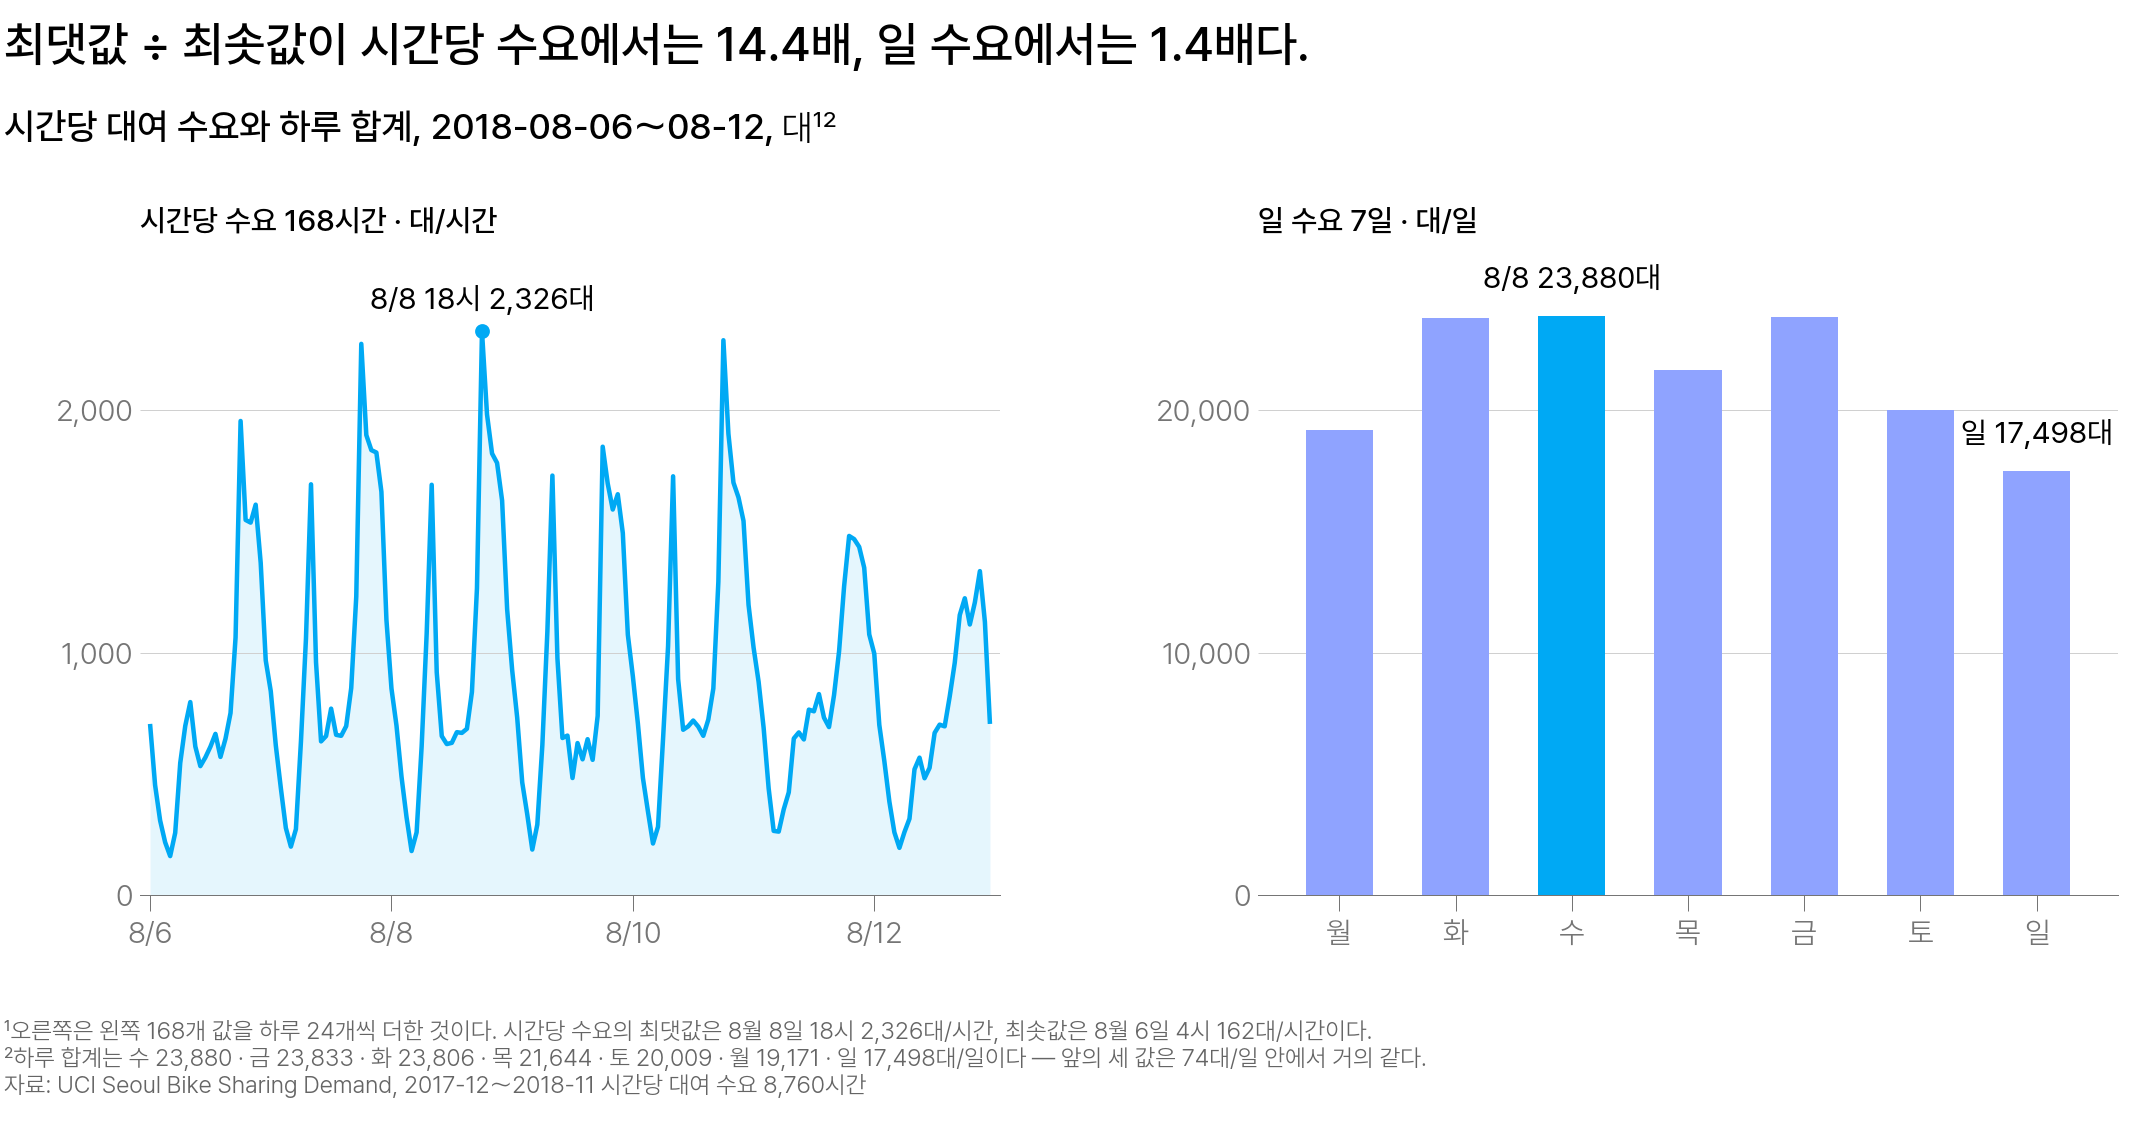

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 같은 한 주를 두 집계 단위로 — 왼쪽은 시간당 수요 168시간, 오른쪽은 하루씩 합친 일 수요 7일</em></p>

**시간당 수요 168시간** 최댓값은 8월 8일 18시 2,326대/시간, 최솟값은 8월 6일 4시 162대/시간입니다. 왼쪽 패널은 몇 시가 높고 몇 시가 낮은지를 보여 줍니다. 같은 모양이 하루에 한 번씩 7번 되풀이되면 하루 주기가 있다는 뜻입니다.

**일 수요 7일** 막대는 왼쪽부터 월요일입니다. 가장 큰 날은 수요일 23,880대/일, 가장 작은 날은 일요일 17,498대/일입니다. 가장 큰 세 날인 수요일·금요일·화요일은 74대/일 안에 있어 요일 사이 차이는 작습니다.

시간당 수요와 일 수요는 단위가 다르니 최댓값 ÷ 최솟값을 집계 단위마다 따로 구합니다. 시간당 수요는 2,326 ÷ 162 = 14.4배, 일 수요는 23,880 ÷ 17,498 = 1.4배입니다. 하루 안의 차이가 날 사이의 차이보다 10배 넘게 큽니다.

왜 줄어드는가. 하루 안의 오르내림이 하루 합계 하나에 들어가기 때문입니다. **다운샘플은 집계 단위보다 짧은 주기를 지웁니다.**

## 시차(lag) k: 몇 시간 전 값과 비교하는가

**시차(lag) $k$** 는 지금 값을 **몇 시간 전 값과 비교하는지** 정하는 수입니다. 일상에서는 「오늘 매출을 어제 매출과 견준다」가 시차 1, 「이번 주 월요일을 지난주 월요일과 견준다」가 시차 7 입니다.

예를 들어 8월 9일 02시의 대여 수요는 466대/시간입니다.

- 시차 1: 1시간 전인 8월 9일 01시의 733대/시간과 비교합니다.
- 시차 24: 어제인 8월 8일 02시의 489대/시간과 비교합니다.

지금 시각을 $t$ 라 하면 지금 값이 $y_t$, $k$ 시간 전 값이 $y_{t-k}$ 입니다. 시차가 24 면 $y_{t-24}$ 가 어제 같은 시각의 값입니다.

왜 필요한가. 「어제 같은 시각과 얼마나 닮았는가」를 재려면 어제 값을 지금 값 옆에 적어야 합니다. 뒤에 나오는 자기상관은 시차 $k$ 를 하나 정해 두고 이 비교를 8,760개 시각 전부에 대해 한꺼번에 합니다.

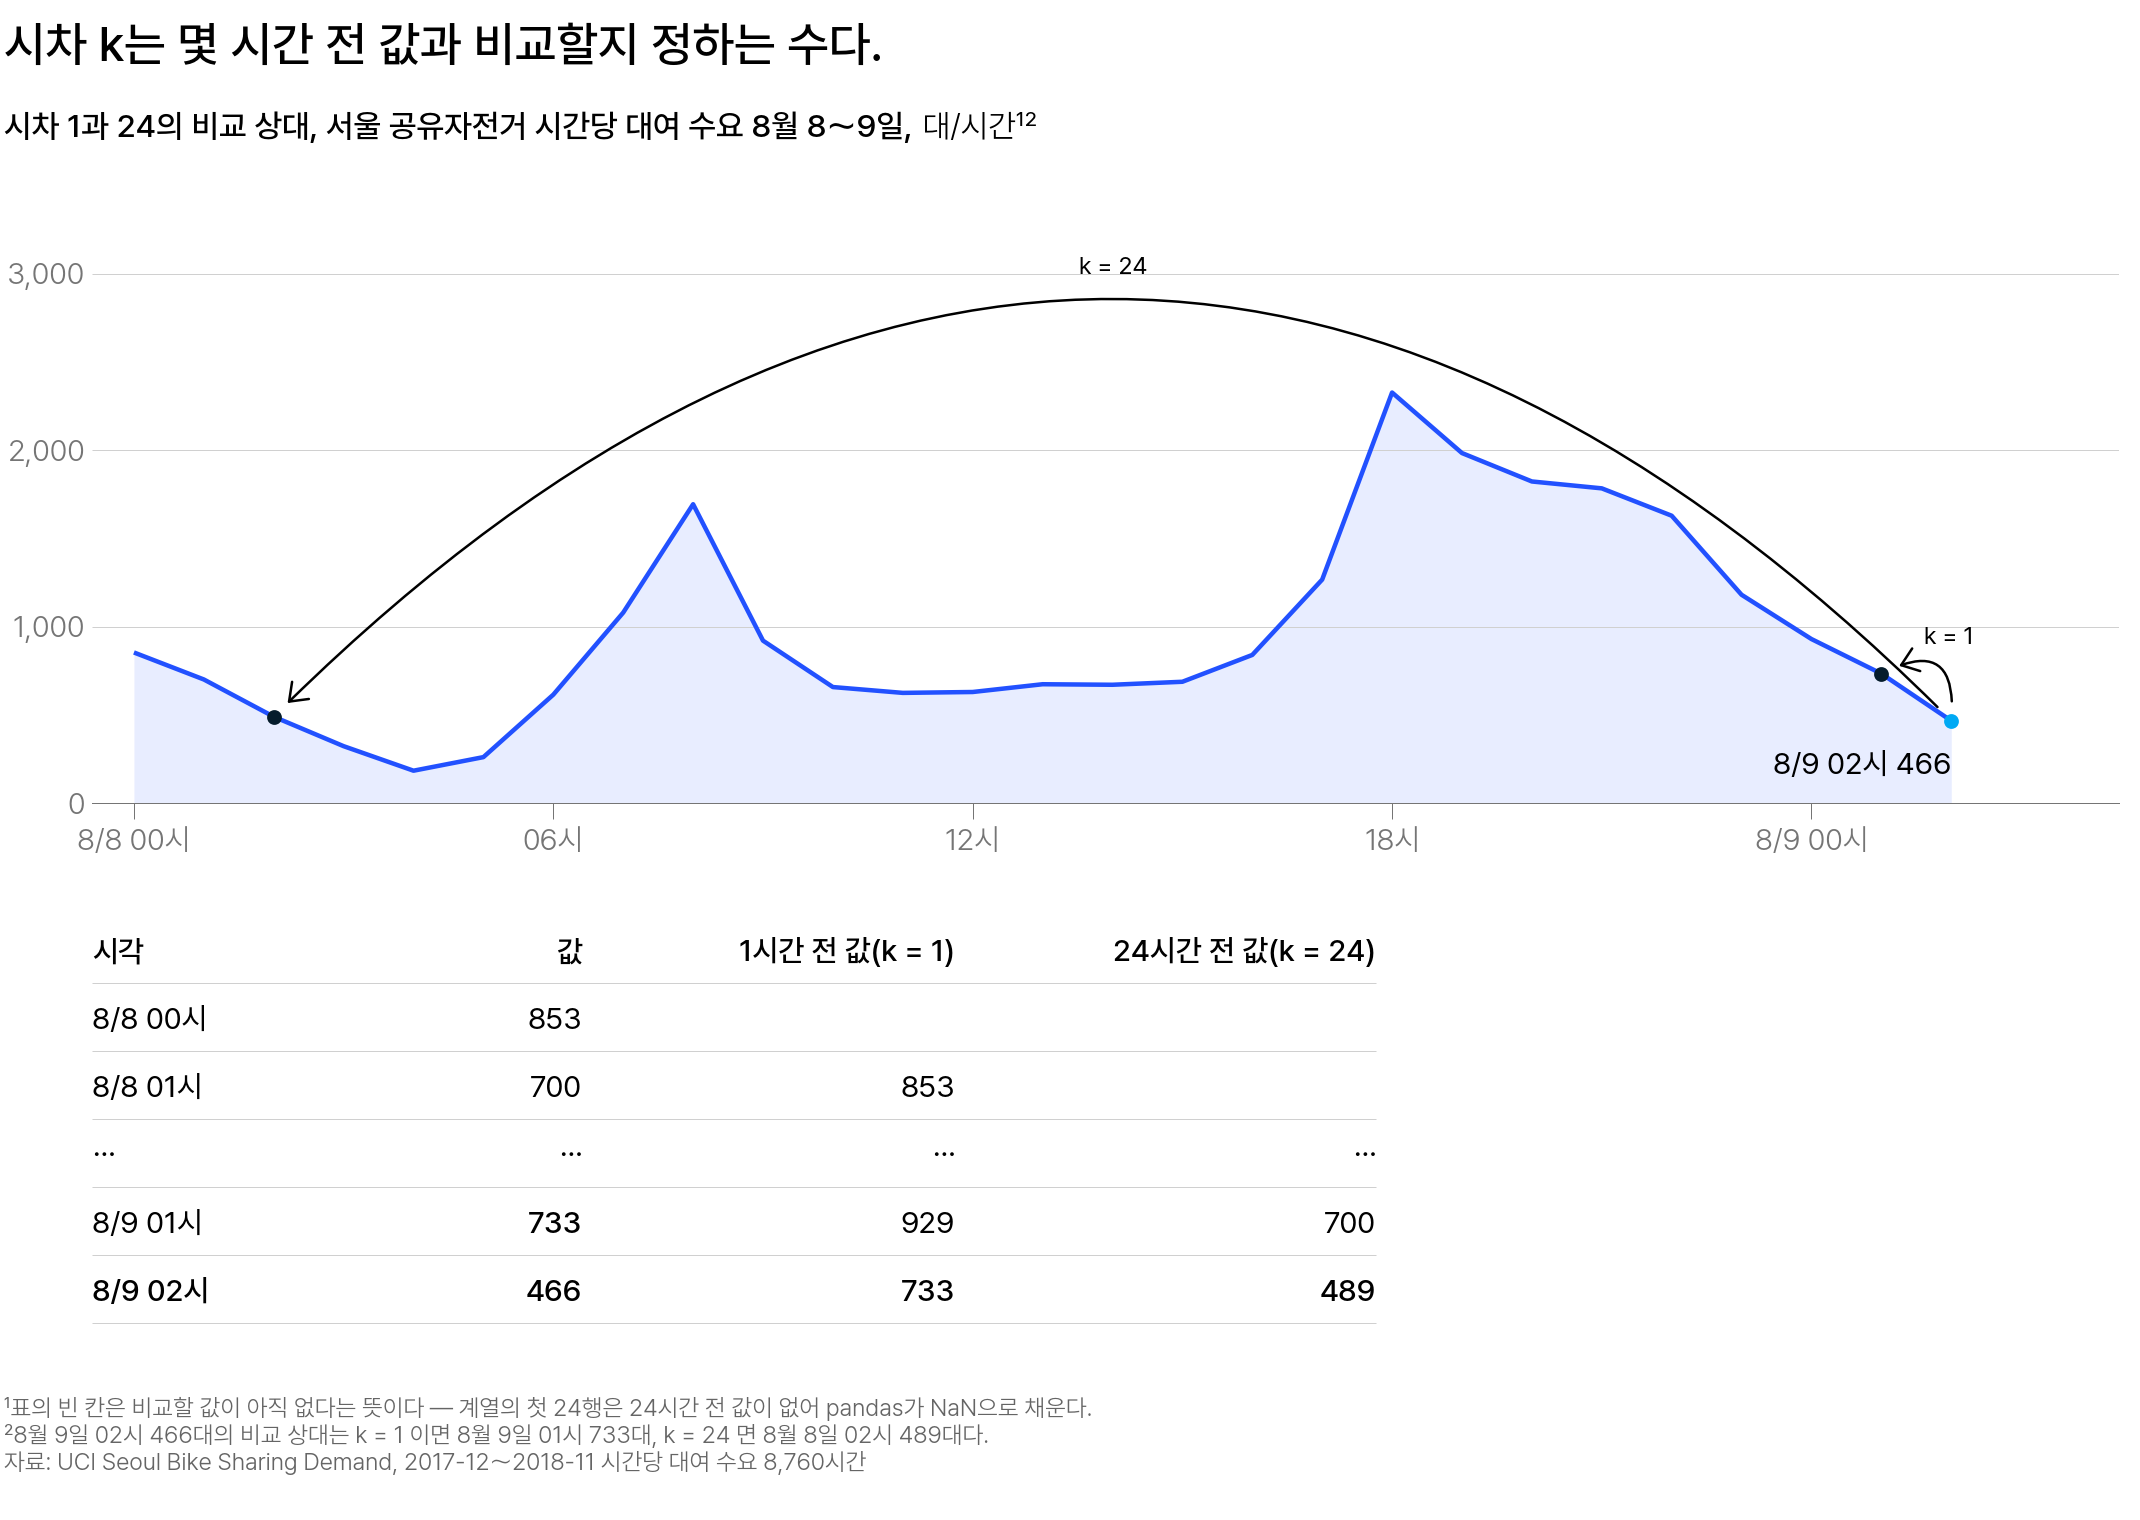

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 8월 9일 02시(466)에서 1시간 전(733)과 24시간 전(489)으로 — 시차는 몇 시간 전과 비교할지 정하는 수다</em></p>

pandas 는 `shift(24)` 로 24행 전 값을 같은 행으로 옮깁니다. 24행 전이 곧 24시간 전인 것은 간격·중복·순서를 확인한 계열에서만입니다. 그림 아래 표의 빈칸은 표를 8월 8일 00시부터 잘라 보여 주기 때문입니다. 계열 맨 앞 24행은 24시간 전 값이 없어 `NaN` 입니다.

<details class="lms-extra"><summary>자세히 — shift 의 기준은 시각이 아니라 행</summary>

서울 공유자전거 시간당 대여 수요는 세 가지 모두 이상이 없으므로 24행 전이 곧 24시간 전입니다. 통과하지 못한 계열에서는 오류 메시지 없이 다른 시각의 값이 따라옵니다.

$k$ 를 키우면 맨 앞 $k$ 개 행에는 비교할 값이 없습니다. 그래서 비교하는 행의 수가 전체 행 수 $T$ 에서 $k$ 를 뺀 $T - k$ 로 줄어듭니다. 이 계열은 $T$ 가 8,760 이라 $k$ 가 24 면 8,736개 행에서, $k$ 가 8,759 면 1개 행에서만 비교합니다.

비교한 행이 적으면 그 값을 믿기 어렵습니다. 그래서 시차는 주기 24 의 두세 배까지 봅니다.

</details>

**한 문장으로** — 시각을 인덱스로 지정하고 간격·중복·순서를 확인해야 리샘플과 시차 k 가 시간의 뜻을 갖습니다.

> **[문제] 8월 6일～12일 시간당 수요에서 8월 8일 03시 한 행이 통째로 빠진 채 저장되었다고 하겠습니다. 이 계열에 `shift(24)` 를 적용하면, 8월 9일 02시 행에 따라오는 값은 언제의 값입니까?**
>
> 8월 8일 02시는 행이 다 있을 때의 답이고, 지금은 그보다 한 시간 더 앞의 값이 따라옵니다. 8월 9일 01시는 `shift(1)` 의 결과입니다. `NaN` 은 계열 맨 앞 24행에서만 나오는데 8월 9일 02시는 맨 앞이 아닙니다. 어느 경우에도 오류 메시지는 뜨지 않으므로, 간격·중복·순서를 먼저 확인하거나 빠진 시각을 채워야 합니다.
>
> 1. 8월 8일 02시
> 2. 8월 8일 01시
> 3. 8월 9일 01시
> 4. 따라올 값이 없어 `NaN` 이 된다

## 3. 추세·계절 성분·잔차로 나누는 분해

**여기서 할 일**

1. 한 시각의 값을 세 성분으로 나눕니다.
2. 성분을 더할지 곱할지 고릅니다.
3. STL 로 8월 744시간을 분해합니다.

8월 6일부터 12일까지 한 주를 시간당 수요로 그린 앞 그림을 다시 봅니다. 눈에 보이는 것이 셋입니다.

1. 매일 같은 모양이 되풀이됩니다. 새벽에 가장 낮고, 8시에 한 번 오르고, 18시에 가장 높습니다.
2. 그 되풀이 위에 며칠에 걸친 큰 흐름이 함께 있습니다. 하루 평균이 8일 995대/시간에서 12일 729대/시간으로 내려갑니다.
3. 둘로 설명되지 않는 값이 있습니다. 비가 0.5mm 내린 8월 6일 08시는 797대/시간입니다. 비가 오지 않은 같은 주 평일 08시는 1,693～1,731대/시간입니다.

**분해(decomposition)** 는 이 셋을 따로 떼어 계열 3개로 만드는 일입니다.

- 2번 큰 흐름이 **추세(trend)** $T_t$ 입니다. 「매출이 5년 동안 꾸준히 는다」, 「기온이 수십 년 서서히 오른다」가 일상의 추세입니다. 직관적으로 말하면 위아래 요동은 있지만 전체적으로 어디로 가고 있는가입니다.
- 1번 되풀이가 **계절 성분(seasonal component)** $S_t$ 입니다. 여기서 「계절」은 봄·여름·가을·겨울이 아닙니다. 「일정한 간격으로 되풀이되는 것」이라는 뜻입니다. 「여름마다 아이스크림 매출이 오른다」, 「월요일 아침마다 접속이 몰린다」, 「월말마다 신용카드 사용이 는다」가 그 예입니다. 직관적으로 말하면 시각만 알아도 얼마나 오르내릴지 미리 아는 몫입니다.
- 3번 나머지가 **잔차(residual)** $R_t$ 입니다. 「그날 폭우로 매출이 뚝 떨어졌다」, 「행사 날 방문객이 갑자기 늘었다」가 일상의 잔차입니다. 직관적으로 말하면 시각으로도 흐름으로도 설명되지 않는 그날의 사정입니다.

잔차는 버리는 값이 아니라, 계절 성분의 간격을 맞게 골랐는지 알려 주는 신호입니다. 잔차에 아직 되풀이되는 형태가 남아 있으면 간격을 잘못 고른 것입니다.

한 주기가 관측 몇 개인지를 **계절 주기 $m$** 이라 합니다. 1시간 간격 자료의 하루 주기는 $m = 24$ 입니다. 하루 간격 자료의 한 주 주기는 $m = 7$ 입니다.

앞으로 $m = 24$ 인 하루 주기를 **주기 24**, $m = 7$ 인 한 주 주기를 **주기 7** 이라 적습니다.

<details class="lms-extra"><summary>더 깊이 — 추세만 따로 그리면 어떻게 보이는가</summary>

<img src="https://otexts.com/fpp3/fpp_files/figure-html/empltrend-1.png" width="640" height="320"/>
<p align="center"><em>▲ 미국 소매업 고용 — 회색이 관측한 계열이고 주황이 분리한 추세다 (출처: fpp3, otexts.com/fpp3)</em></p>

다른 자료로 확인합니다. 주황은 1992년 무렵 약 1,280만 명에서 2000년 약 1,530만 명까지 오릅니다. 회색에는 해마다 12월에 뾰족하게 올라간 부분이 있는데 주황에는 없습니다.

2018년 12월은 회색이 약 1,640만 명, 주황이 약 1,570만 명입니다. 그 차이 70만 명가량이 계절 성분으로 갑니다.

주황이 2008년부터 2010년까지 내려간 구간은 계절 성분이 아닙니다. **순환(cycle)** 은 되풀이되지만 길이가 고정되지 않은 변동입니다. 한 번은 8년, 다음은 12년처럼 간격이 다릅니다. 분해는 고정된 간격만 떼어 내므로 순환은 추세와 함께 남습니다.

| | 계절성 | 순환 |
|---|---|---|
| 한 주기의 길이 | 고정 — 언제나 $m$ 시점 | 들쭉날쭉하고 대체로 여러 해 |
| 언제 오를지 | 달력만 보면 안다 | 미리 알 수 없다 |
| 예 | 1시간 간격 자료의 하루 주기 | 경기 순환 |

</details>

## 한 시각의 값을 세 성분으로 나누면

8월 8일 18시에 자전거가 2,326대 나갔습니다. STL 계산은 이 2,326 을 이렇게 가릅니다.

$$
\underbrace{2{,}326}_{\text{18시 대여 수요}} = \underbrace{973}_{\text{추세}} + \underbrace{970}_{\text{계절 성분}} + \underbrace{383}_{\text{잔차}}
$$

- 추세 973대/시간 — 「요즘 이만큼 나간다」는 그 무렵 며칠에 걸친 기본 수준입니다
- 계절 성분 +970대/시간 — 「이 시각은 원래 이만큼 더」라는 몫입니다
- 잔차 +383대/시간 — 「그날 무슨 일이 있었나」에 해당하는 예상 밖의 몫입니다

새벽은 반대입니다. 같은 날 05시는 260대입니다.

$$
\underbrace{260}_{\text{05시 대여 수요}} = \underbrace{966}_{\text{추세}} + \underbrace{(-660)}_{\text{계절 성분}} + \underbrace{(-46)}_{\text{잔차}}
$$

추세 966 은 18시의 973 과 거의 같습니다. 며칠에 걸친 기본 수준은 하루 안에서 거의 변하지 않기 때문입니다. 달라진 것은 계절 성분이고, 새벽은 「원래 이만큼 덜」 나가는 시각이라 부호가 음수입니다.

기호로는 시각 $t$ 의 값을 $y_t$, 세 성분을 $T_t$, $S_t$, $R_t$ 라 적습니다.

$$
\underbrace{y_t}_{\text{시간당 수요}} = \underbrace{T_t}_{\text{추세}} + \underbrace{S_t}_{\text{계절 성분}} + \underbrace{R_t}_{\text{잔차}}
$$

- $y_t$ : 시각 $t$ 에 실제로 나간 시간당 수요
- $T_t$ : 그 무렵 며칠에 걸친 기본 수준, 곧 추세
- $S_t$ : 그 시각이라서 더하거나 빼는 몫, 곧 계절 성분
- $R_t$ : 둘로 설명하고 남은 잔차

## 왜 나누는가

질문마다 보는 성분이 다르기 때문입니다.

| 질문 | 보는 성분 |
|---|---|
| 요즘 대여가 늘고 있나, 줄고 있나 | 추세 |
| 몇 시에 자전거를 많이 배치해야 하나 | 계절 성분 |
| 그날 무슨 일이 있었나, 이상한 시각은 언제인가 | 잔차 |

나누기 전에는 답 셋이 한 곡선에 겹쳐 있어 어느 것도 바로 읽을 수 없습니다.

## 성분을 더할까 곱할까: 가법 분해와 승법 분해

위에서는 세 성분을 **더했습니다**. 더해서 관측값이 되는 분해를 **가법(additive) 분해**라 합니다. 18시의 계절 성분은 「수준보다 970대/시간 더」였습니다.

곱하는 방법도 있습니다. **승법(multiplicative) 분해**에서 계절 성분과 잔차는 더하는 몫이 아니라 배수입니다. 「18시는 그 무렵 수준의 2배」처럼 적습니다.

$$
\underbrace{y_t}_{\text{시간당 수요}} = \underbrace{T_t}_{\text{추세}} \times \underbrace{S_t}_{\text{계절 배수}} \times \underbrace{R_t}_{\text{잔차 배수}}
$$

어느 쪽인지는 수요가 많은 날과 적은 날을 비교해 고릅니다. 하루 평균이 몇 배가 되었는지, 하루 안의 오르내림이 몇 배가 되었는지를 봅니다.

- 오르내림이 하루 평균과 비슷한 배수로 커지면 승법입니다.
- 오르내림이 커진 배수가 그보다 훨씬 작으면 가법입니다.

**이 계열은 가법입니다.** 8월 28일은 하루 평균 379대/시간이고 17일은 1,201대/시간으로 3.2배 차이입니다. 그런데 하루 안의 최댓값 − 최솟값은 28일이 1,831대/시간, 17일이 2,521대/시간으로 1.4배입니다. 하루 평균이 3.2배가 되어도 오르내림은 1.4배에 그치니 더하기로 나눕니다.

<details class="lms-extra"><summary>더 깊이 — 승법인 계열은 어떻게 생겼는가</summary>

<img src="https://otexts.com/fpp3/fpp_files/figure-html/h02-1.png" width="640" height="395"/>
<p align="center"><em>▲ H02 약품 월 처방액 — 위 패널 Cost 가 관측 계열, 아래 패널 log(Cost) 가 로그를 취한 같은 계열이다 (출처: fpp3, otexts.com/fpp3)</em></p>

위 패널에서 1992년 전후는 저점 0.33 · 정점 0.77 이고, 2006년 전후는 저점 0.58 · 정점 1.23 입니다. 정점에서 저점을 뺀 차이는 0.44 에서 0.65 로 커집니다.

그런데 정점을 저점으로 나눈 배수는 2.3 과 2.1 로 거의 같습니다. 뺀 값만 커지고 나눈 값이 그대로면 승법입니다.

아래 패널은 같은 계열에 로그를 취한 값입니다. 정점에서 저점을 뺀 차이가 1992년 전후 0.8, 2006년 전후 0.7 로 거의 같아집니다. 로그를 취하면 승법이 가법이 되기 때문입니다.

**로그는 왜 곱을 합으로 바꾸는가**

**① 승법 식을 그대로 옮겨 적습니다.**

$$
y_t = T_t \times S_t \times R_t
$$

**② 양변에 로그를 취합니다.** 로그에는 $\log(2 \times 3) = \log 2 + \log 3$ 이라는 성질이 있습니다. 곱한 것의 로그는 각각의 로그를 더한 값이라는 뜻입니다.

$$
\log y_t = \log T_t + \log S_t + \log R_t
$$

**③ 새 이름으로 읽습니다.** $\log T_t$, $\log S_t$, $\log R_t$ 를 각각 새 성분으로 보면 오른쪽은 가법과 같은 모양입니다. 그래서 승법 계열은 로그를 취한 뒤 가법 분해에 넣습니다.

**④ 작은 수로 검산합니다.** 추세 100, 계절 배수 1.3, 잔차 배수 0.95 를 곱하면 123.5 입니다.

로그 쪽에서는 $\log 100 = 4.605$, $\log 1.3 = 0.262$, $\log 0.95 = -0.051$ 이고 셋을 더하면 4.816 입니다. 여기에 지수를 취하면 123.5 로 같습니다. 여기 로그는 밑이 $e$ 인 자연로그입니다.

</details>

## STL: 세 성분으로 실제로 나누기

세 성분을 손으로 가를 수는 없으니 계산 방법이 필요합니다.

추세를 만드는 가장 단순한 방법은 **이동평균(rolling mean)** 입니다. 이웃한 몇 시각의 평균을 그 시각의 값으로 적습니다. 8월 8일 07시 1,079 · 08시 1,693 · 09시 920대/시간의 평균 1,231대/시간이 08시의 3시간 이동평균입니다.

왜 평균을 내면 매끄러워지는가. 위로 튄 값과 아래로 튄 값이 서로 지워지고 큰 흐름만 남습니다. 구간을 길게 둘수록 더 매끄러워집니다. 계열 전체를 한 번에 평균 내면 값이 하나뿐인 평평한 선이 되어 오르내리는 흐름이 남지 않습니다.

**STL** 은 이 일을 자동으로 하는 계산 절차입니다. Seasonal-Trend decomposition using Loess 의 약자입니다. 추세는 이동평균이 아니라 **국소회귀(Loess)** 로 만듭니다.

이동평균은 구간 안의 값들을 똑같이 평균 냅니다. 국소회귀는 가까운 시각의 값을 크게 반영해 그 시각 주변에 직선을 하나 긋습니다. 그 직선이 지금 시각에서 갖는 높이가 그 시각의 추세입니다. 그래서 결과가 더 매끄럽습니다.

나머지 둘은 추세를 뺀 다음에 나옵니다. 추세를 뺀 값에서 같은 시각끼리 모아 평균 낸 것이 계절 성분입니다. 관측값에서 추세와 계절 성분을 뺀 것이 잔차입니다.

반드시 정해 줄 것은 계절 주기 하나입니다. 하루 주기라 `period=24` 로 둡니다. 함께 적은 `robust=True` 는 크게 튀는 값의 영향을 줄이라는 선택입니다.

In [ ]:
# 코드 1 · STL 분해 호출 — 핵심은 가운데 STL 두 행이다
import pandas as pd
from statsmodels.tsa.seasonal import STL

try:
    bike = load_csv("datasets/SeoulBikeData.csv")           # 실행 카드가 주는 읽기 함수
except NameError:                                           # 이 함수가 없는 곳에서는 원본을 받는다
    SRC = ("https://archive.ics.uci.edu/static/public/560/"
           "seoul+bike+sharing+demand.zip")
    bike = pd.read_csv(SRC, encoding="cp1252", compression="zip")
bike = bike.rename(columns={"Date": "date", "Hour": "hour",
                            "Rented Bike Count": "count"})  # 원본 열 이름을 줄인다
when = (pd.to_datetime(bike["date"], format="%d/%m/%Y")     # 01/12/2017 = 2017년 12월 1일
        + pd.to_timedelta(bike["hour"], unit="h"))          # 그 행의 시각을 더한다
y = pd.Series(bike["count"].values, index=when).sort_index().loc["2018-08"]

res = STL(y, period=24, robust=True).fit()                           # 이 행이 분해다
trend, seasonal, resid = res.trend, res.seasonal, res.resid          # 세 성분을 꺼낸다

at = "2018-08-08 18:00"                                              # 본문에서 검산한 시각
print(f"8월 8일 18시 — 추세 {trend.loc[at]:.0f} · 계절 성분 {seasonal.loc[at]:+.0f}"
      f" · 잔차 {resid.loc[at]:+.0f}")
print(f"세 성분의 합 {trend.loc[at] + seasonal.loc[at] + resid.loc[at]:.0f}"
      f" · 관측값 {y.loc[at]:.0f}")

아래는 휴무가 없는 2018년 8월 744시간을 이 설정으로 분해한 결과입니다.

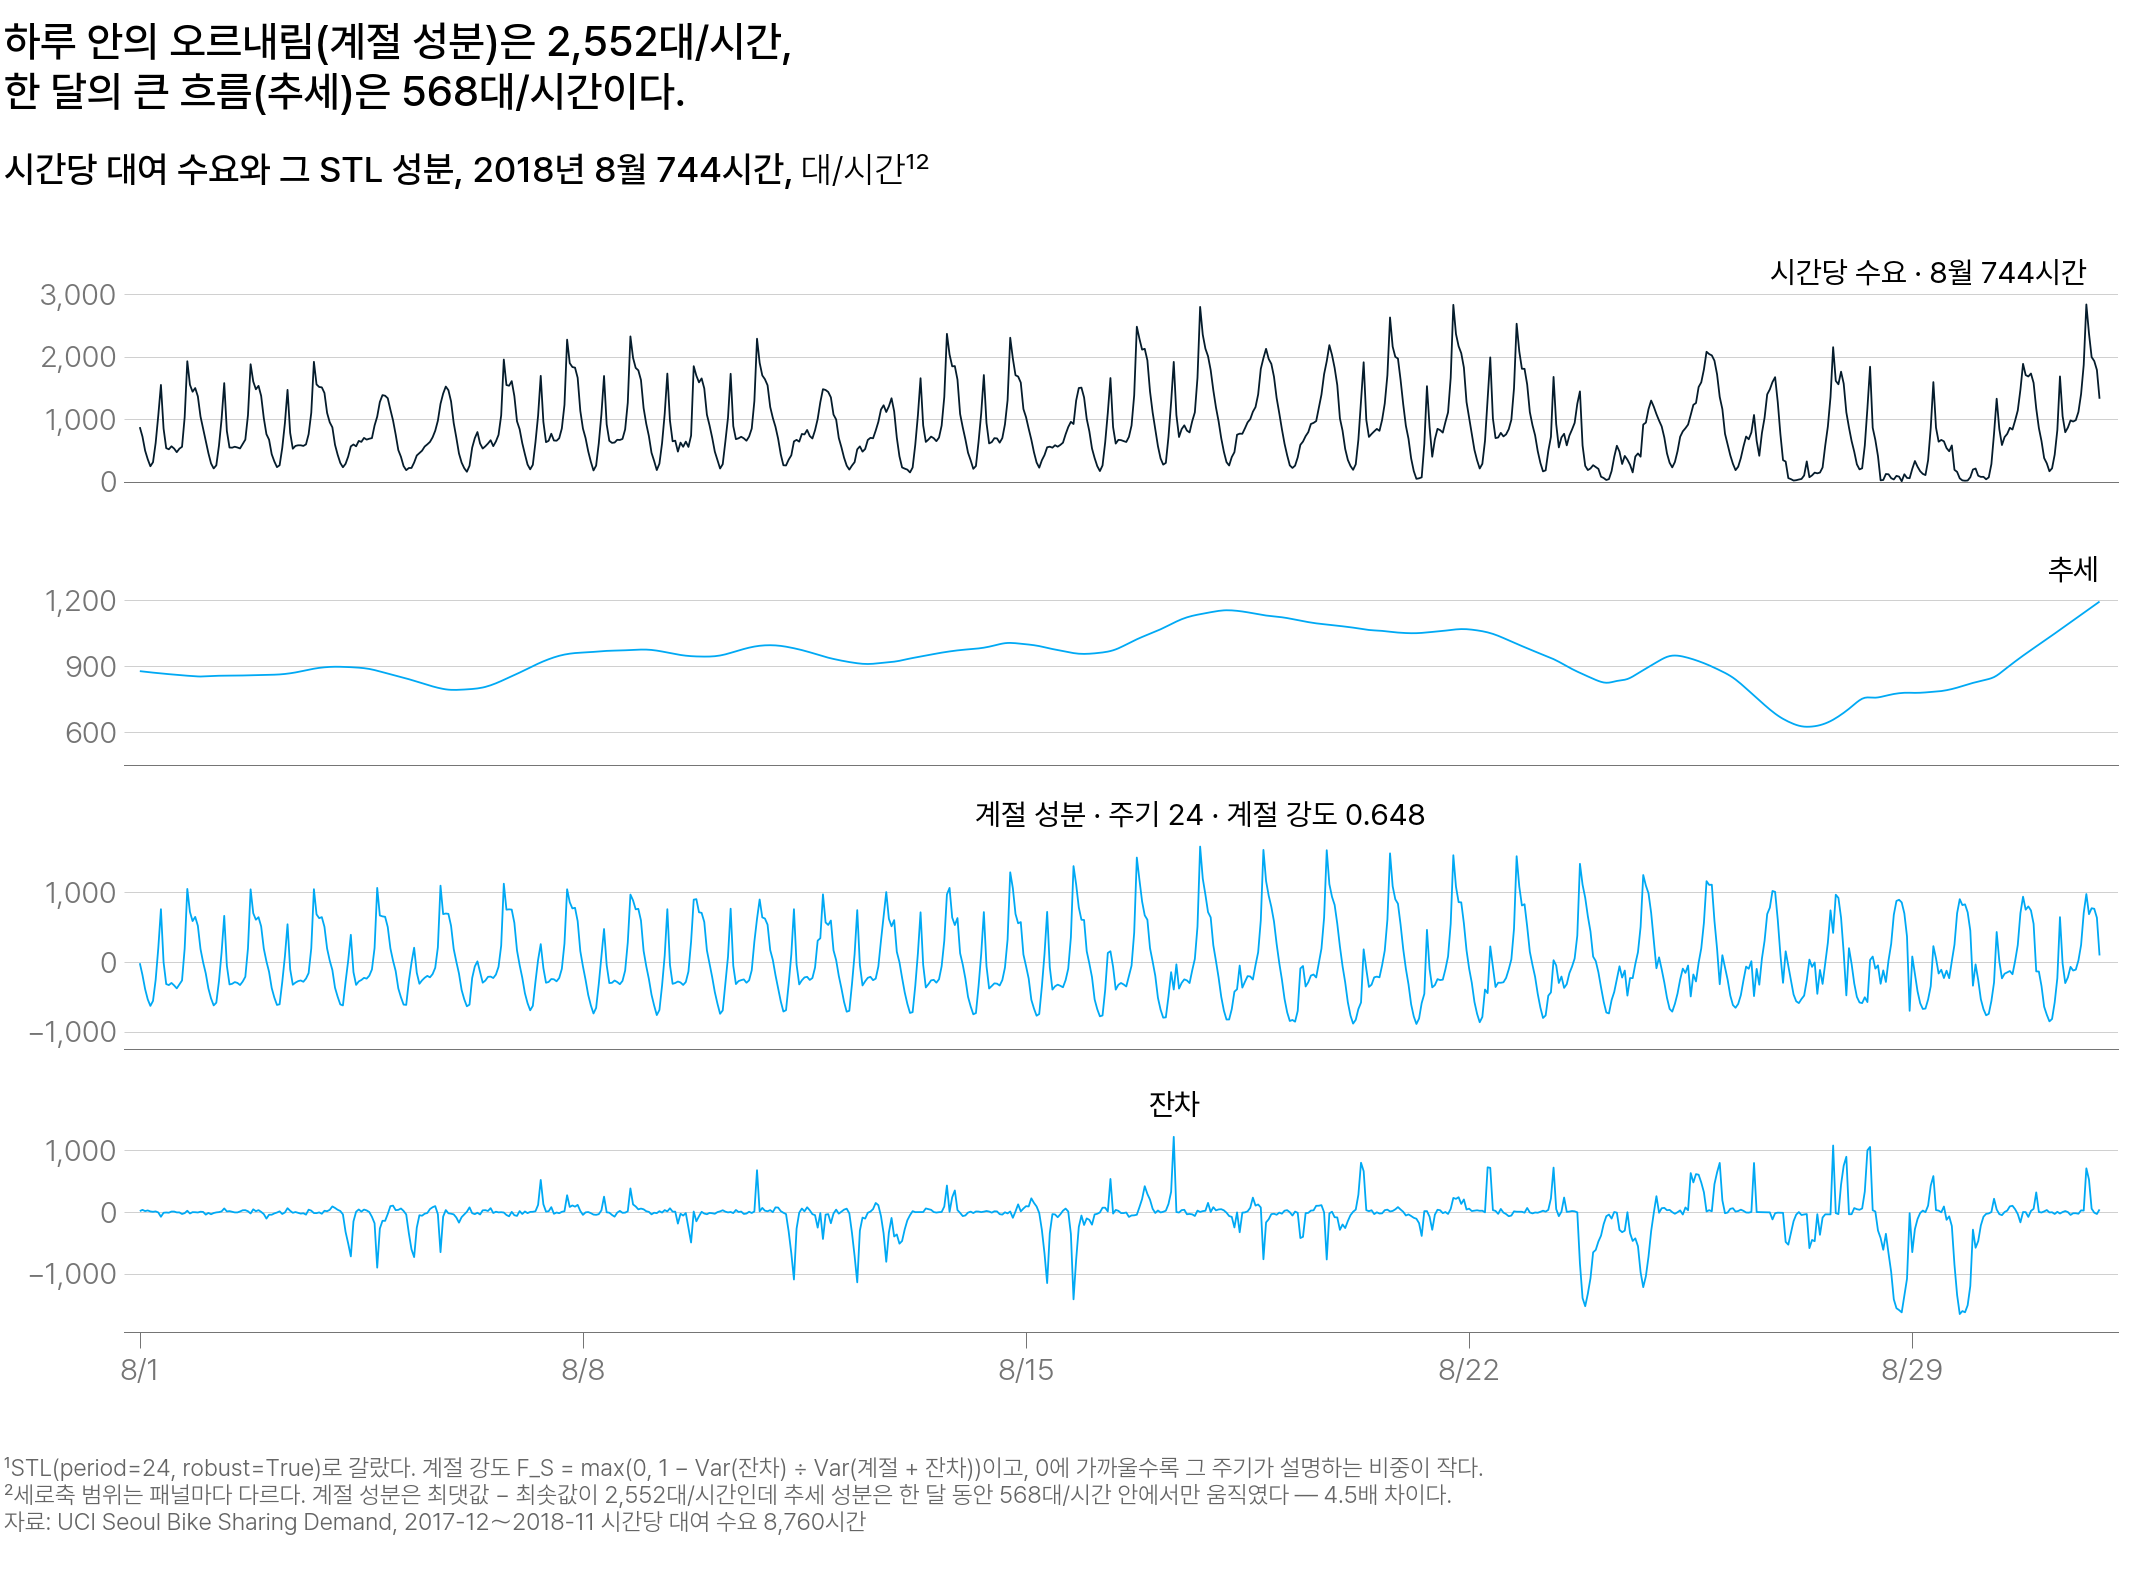

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 서울 공유자전거 시간당 대여 수요의 STL 분해 — 위에서 아래로 시간당 수요 · 추세 · 계절 성분 · 잔차이고, 세로축 범위는 패널마다 다르다</em></p>

**시간당 수요** 8월 744시간의 원래 값이고 매일 같은 모양이 되풀이됩니다.

**추세** 하루 안의 오르내림을 뺀 뒤 남는 기본 수준입니다. 8월 27일 08시의 625대/시간이 가장 낮고, 31일 23시의 1,193대/시간이 가장 높습니다.

**계절 성분** 24시간마다 같은 모양이 되풀이되는 몫입니다. STL 은 그 모양의 크기가 날마다 달라지도록 두므로 날마다 높이가 같지는 않습니다. 가장 큰 값은 8월 17일 18시의 +1,660대/시간, 가장 작은 값은 21일 04시의 −892대/시간입니다. 둘의 차이 2,552대/시간을, 추세가 한 달 동안 움직인 범위 1,193 − 625 = 568대/시간으로 나누면 4.5배입니다.

**잔차** 0 에 가까울수록 추세와 계절 성분으로 잘 설명된 시각입니다. 잔차가 양수인 시각은 예상보다 많이 빌린 시각이고, 음수인 시각은 적게 빌린 시각입니다. 가장 큰 양수는 8월 17일 08시의 +1,218대/시간, 가장 큰 음수는 29일 18시의 −1,653대/시간입니다. 되풀이되는 형태가 없으므로 계절 주기를 맞게 지정한 것입니다.

계절 패널 제목의 0.648 은 계절 강도입니다. 추세를 뺀 나머지 변동 가운데 계절 성분이 설명하는 몫이고, 1 에 가까울수록 계절 성분이 강합니다.

<details class="lms-extra"><summary>자세히 — 국소회귀가 추세값 하나를 정하는 한 걸음</summary>

**① 8월 8일 18시의 추세값 973대/시간이 어떻게 정해졌는지 따라갑니다.**

**② 쓰는 값을 고릅니다.** 그 시각 앞뒤 23시간, 곧 47개 시각의 값만 씁니다. 그 47개에서 계절 성분을 먼저 뺀 값은 맨 앞이 1,039대/시간, 맨 뒤가 451대/시간입니다.

**③ 직선 하나를 맞춥니다.** 47개 점에 직선 하나를 긋는데, 8월 8일 18시에서 먼 시각일수록 적게 반영합니다. 먼 시각의 값은 그 시각의 수준을 대표하지 못하기 때문입니다.

**④ 그 직선이 8월 8일 18시에서 갖는 높이를 적습니다.** 그 높이 973대/시간이 18시의 추세값입니다. 같은 계산을 744개 시각마다 되풀이해 이은 선이 추세 패널입니다.

**⑤ 검산.** 973 에 계절 성분 970 과 잔차 383 을 더하면 2,326 으로 그 시각의 관측값과 같습니다.

`robust=True` 로 두는 까닭은 1년 8,760시간에 대여가 멈춘 휴무 295시간이 있기 때문입니다. `period` 를 실제 주기보다 작게 주면 되풀이되는 형태의 일부가 잔차에 남고, 크게 주면 하루 안의 형태까지 계절 성분에 들어갑니다.

</details>

**그래서** 이 계열에서 가장 큰 몫은 하루 주기입니다.

**한 문장으로** — 분해는 계열 하나를 세 성분으로 나누어 성분마다 크기를 따로 읽게 하는 일입니다.

## 4. 계절 강도: 주기 24와 주기 7의 비교

**여기서 할 일**

1. 평균적인 하루의 형태를 시각별 평균으로 봅니다.
2. 한 주기가 설명하는 비중을 값 하나로 요약합니다.
3. 주기 24 와 주기 7 가운데 계절 주기를 정합니다.

**시각별 프로파일**(hourly profile) 은 8,760시간을 0시부터 23시까지로 묶어 평균한 하루 24시점 값입니다.

18시의 값이 사흘 동안 1,400 · 1,600 · 1,500대/시간이었다고 하겠습니다. 18시의 프로파일 값은 (1,400 + 1,600 + 1,500) ÷ 3 = 1,500대/시간입니다. 실제로는 365일치로 같은 평균을 냅니다.

왜 평균을 내는가. 날마다 다른 날씨와 휴일이 지워지고 평균적인 하루의 형태만 남기 때문입니다.

> **[예측] 하루에 정점이 2개(아침 출근·저녁 퇴근)라면, 저녁 정점은 아침 정점의 몇 배입니까?**
>
> 1. 1.2배쯤 — 거의 비슷하다
> 2. 1.5배쯤 — 저녁이 눈에 띄게 높다
> 3. 2배 이상 — 저녁 쪽으로 크게 쏠린다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

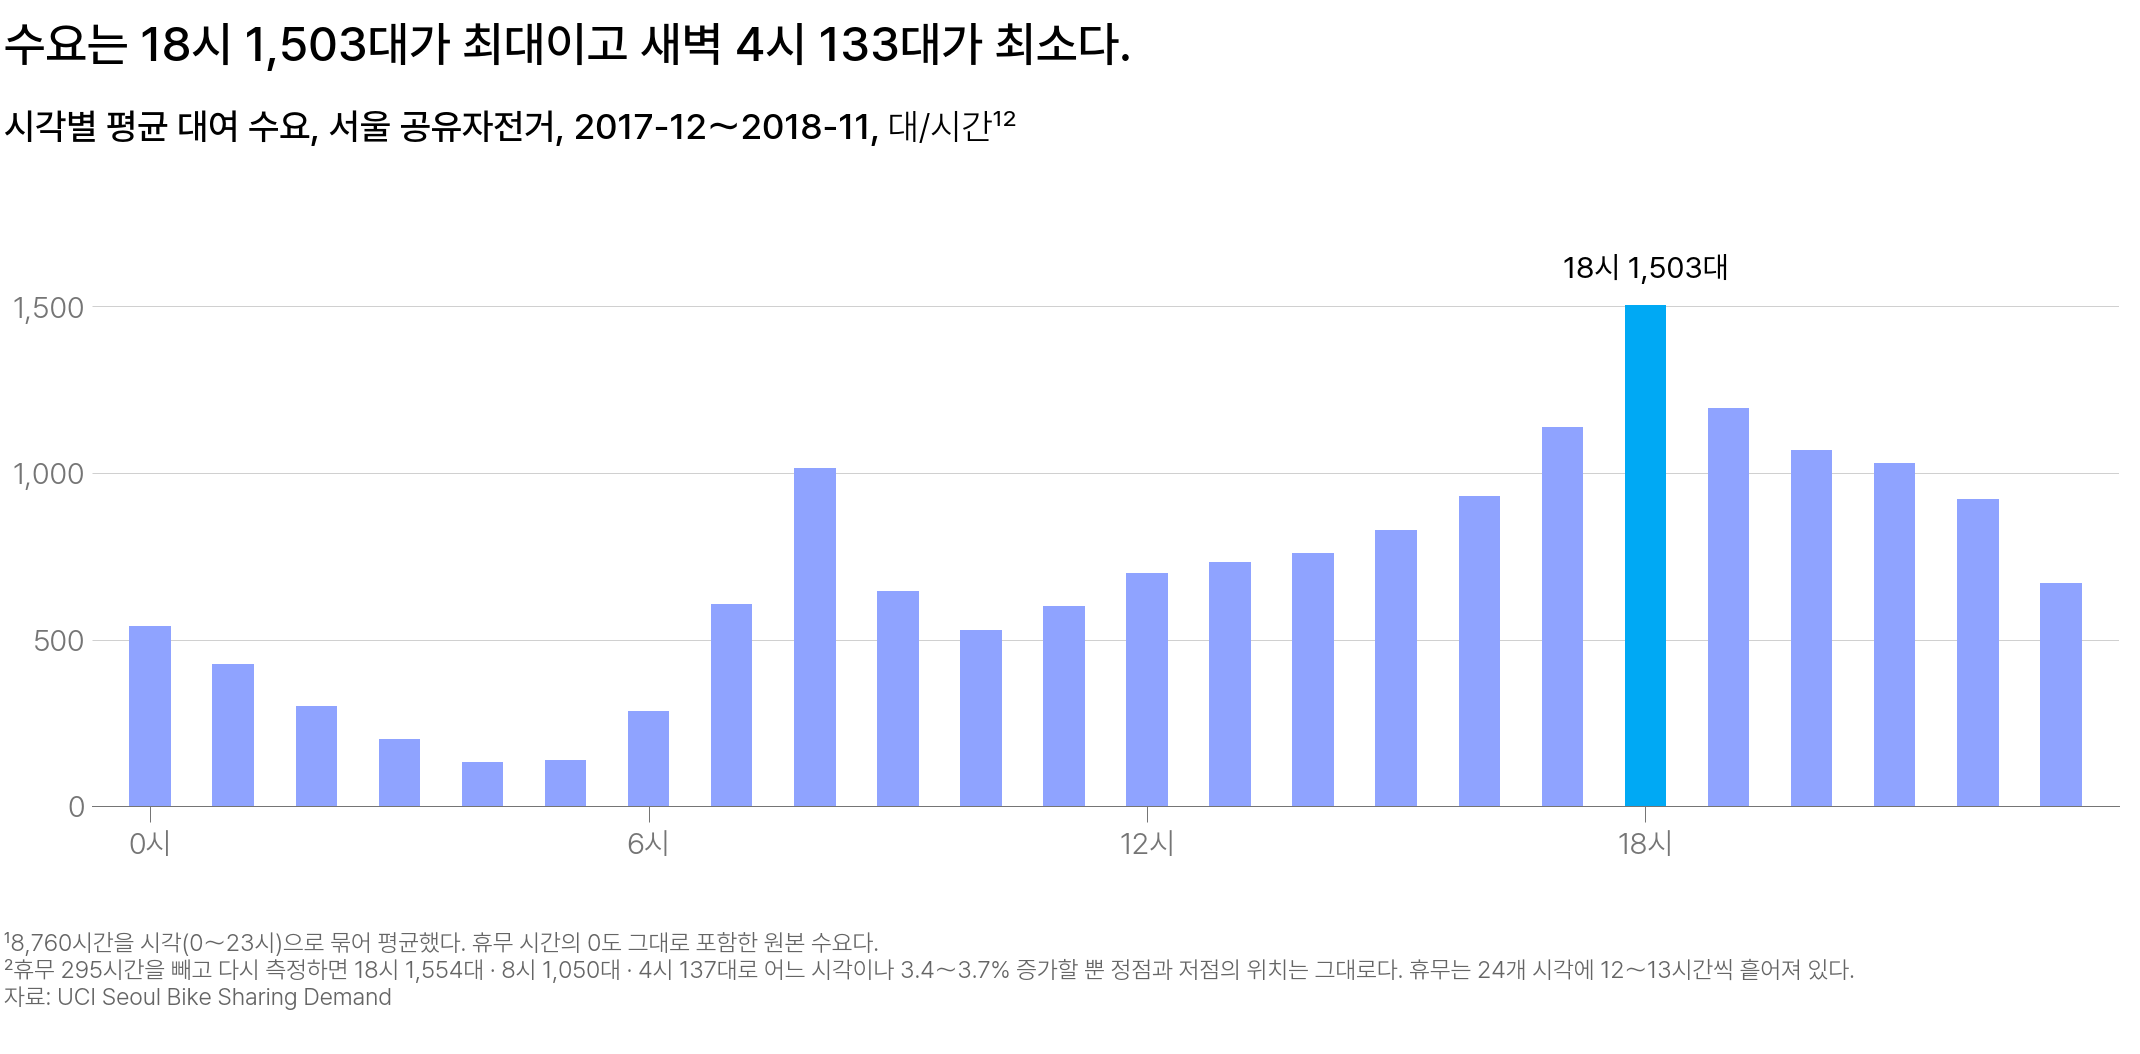

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 시각별 평균 대여 수요 — 하늘색 18시가 1,503대/시간으로 가장 크고, 4시가 133대/시간으로 가장 작다</em></p>

시각 24개를 막대로 그린 그림입니다. 평균적인 하루에서 수요가 언제 오르고 내리는지를 보여 줍니다. 18시 1,503대/시간이 최대, 8시 1,016대/시간이 둘째 정점, 4시 133대/시간이 최소입니다. 정점이 2개, 저점이 1개이고, 출퇴근 시각이 그대로 찍혀 있습니다.

앞에서 예측한 답은 두 번째입니다. 1,503 ÷ 1,016 = 1.48배입니다.

**그래서** 1년 8,760시간의 전체 평균 704.6대/시간은 어느 시각의 수요도 아닙니다. 뒤에서 다룰 정상성은 평균이 시점과 관계없이 같기를 요구합니다. 이 계열은 그 조건부터 어긋납니다.

## 계절 강도: 계절 성분이 변동의 몇 %를 설명하는가

**계절 강도 $F_S$(seasonal strength)** 는 추세를 뺀 나머지 변동 가운데 계절 성분이 설명하는 비중입니다. 0 에 가까우면 거의 설명하지 못하고, 1 에 가까우면 대부분을 설명합니다.

$$
F_S = \max\!\left(0,\; 1 - \frac{\underbrace{\operatorname{Var}(R_t)}_{\text{잔차의 분산}}}{\underbrace{\operatorname{Var}(S_t + R_t)}_{\text{추세를 뺀 나머지의 분산}}}\right)
$$

8월 744시간의 실제 값을 대입하면 이렇습니다.

$$
F_S = 1 - \frac{105{,}186}{298{,}620} = 1 - 0.352 = 0.648
$$

- 분모 $298{,}620$ : 추세를 뺀 나머지 변동의 분산입니다
- 분자 $105{,}186$ : 그 가운데 잔차의 분산입니다
- 분수 $0.352$ : 잔차가 차지한 비중입니다
- 남은 $0.648$ : 계절 성분이 설명한 비중이고 단위가 없습니다
- $\max(0,\ \cdot)$ : 값이 음수로 나오면 0 으로 적습니다

<details class="lms-extra"><summary>자세히 — 계절 강도 식이 왜 이 모양인가</summary>

**① 이 식은 계절 성분이 얼마나 큰지를 0 과 1 사이 수 하나로 적으려는 것입니다.**

**② 크기를 무엇으로 측정하는가.** 계절 성분이 크다는 것은 그 곡선이 위아래로 많이 움직인다는 뜻입니다. 움직인 크기를 측정하는 수가 분산입니다. 계절 성분의 분산을 80 이라 하겠습니다.

$$
\operatorname{Var}(S_t) = 80
$$

**③ 무엇과 비교하는가.** 분산 하나만으로는 큰지 작은지 알 수 없습니다. 대여 수요는 분산이 수십만이고 로그를 취한 값은 1 도 되지 않습니다.

추세를 빼면 남는 것은 계절 성분과 잔차 둘뿐입니다. 그래서 둘을 더한 계열의 분산을 전체로 둡니다. 계절 성분의 분산 80 에 잔차의 분산 20 을 더하면 100 입니다.

$$
\operatorname{Var}(S_t + R_t) = 80 + 20 = 100
$$

**④ 잔차 쪽 비중을 1 에서 뺍니다.** 계절 성분의 분산을 직접 나누지 않고 잔차 쪽 비중을 빼는 것입니다.

$$
F_S = 1 - \frac{\operatorname{Var}(R_t)}{\operatorname{Var}(S_t + R_t)} = 1 - \frac{20}{100} = 0.8
$$

**⑤ 잔차가 커지면 어떻게 되는가.** 잔차의 분산이 20 에서 91 로 커지면 분모도 100 에서 171 로 함께 커집니다. 그래도 잔차 비중은 0.2 에서 0.53 으로 커집니다. 같은 수를 분자와 분모에 함께 더하면 분수가 1 에 가까워지기 때문입니다.

$$
F_S = 1 - \frac{91}{171} = 0.47
$$

**⑥ 왜 음수가 나올 수 있는가.** 계절 성분과 잔차가 서로 반대로 움직이면 둘을 더한 계열의 분산이 잔차 하나의 분산보다 작아질 수 있습니다. 그러면 분수가 1 을 넘어 값이 음수가 됩니다. 계절 강도가 0 보다 작다는 말은 뜻이 없으므로 $\max(0,\ \cdot)$ 로 0 에서 끊습니다.

**⑦ 읽을 때 조심할 것.** 분모에는 추세가 만든 변동이 빠져 있습니다. 그래서 계열 전체 변동 가운데 계절 성분의 비중으로 읽으면 안 됩니다.

</details>

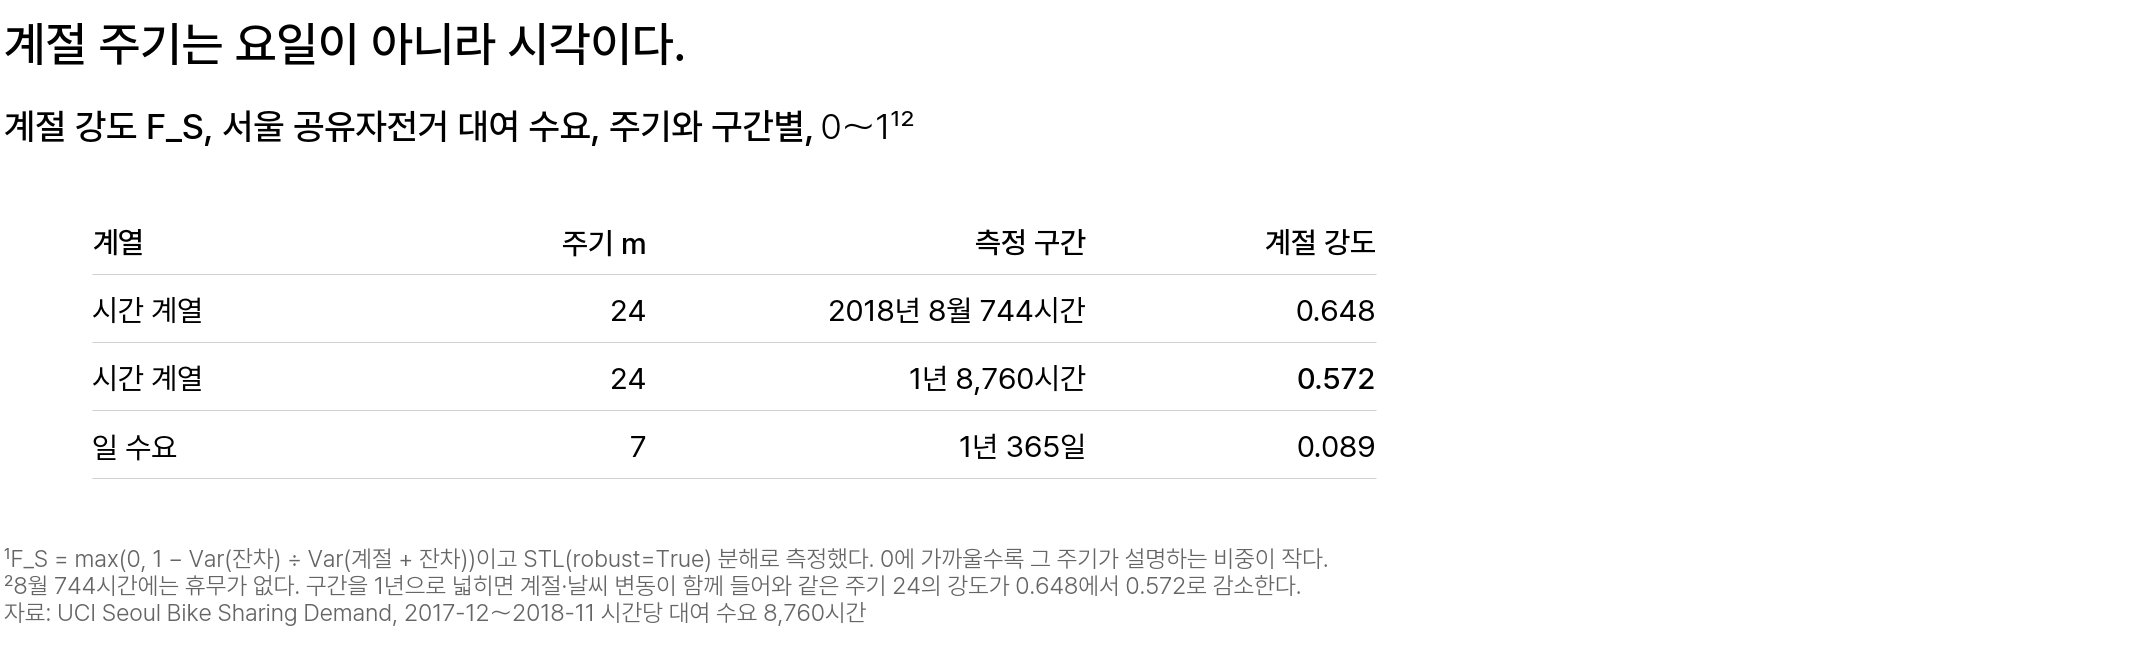

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 계절 강도 — 첫째 열은 분해한 계열, 셋째 열은 그 가운데 실제로 쓴 기간이다</em></p>

**① 시간 계열 · 주기 24 · 8월 744시간 → 0.648** 표의 「시간 계열」은 앞에서 쓰던 시간당 수요입니다. 8월의 하루 주기가 얼마나 강한지 측정한 값입니다.

**② 시간 계열 · 주기 24 · 1년 8,760시간 → 0.572** 구간만 1년으로 넓힌 값입니다. 휴무와 날씨 변동이 잔차로 들어와 0.648 에서 내려갑니다.

**③ 일 수요 · 주기 7 · 1년 365일 → 0.089** 같은 방법으로 요일 주기를 측정했습니다.

셋째 열의 **측정 구간** 은 그 값을 계산한 기간이고, 인용할 때 함께 적습니다.

② 와 ③ 은 같은 1년 구간에서 측정했으므로 나란히 비교할 수 있습니다. 다만 두 값은 각자 자기 계열에서 추세를 뺀 나머지 변동을 분모로 삼습니다. 그래서 0.572 는 크고 0.089 는 작다는 것까지만 말하고, 몇 배인지는 읽지 않습니다.

요일 주기는 왜 일 수요에서 측정하는가. 시간당 수요에서 보면 한 주기가 7 × 24 = 168시간이고, 그러면 하루 주기까지 한 계절 성분에 들어갑니다. 그래서 하루씩 더한 일 수요에서 측정합니다.

#### 0.648 과 0.089 는 실무에서 얼마나 강한가

계절 강도에는 널리 쓰는 판정 기준이 없습니다. 그래서 「그 주기를 쓰면 오차가 얼마나 줄어드는가」로 판단합니다. **제곱평균제곱근오차**(RMSE, root mean square error) 는 예측이 빗나간 크기입니다. 시점마다 실제 값에서 예측값을 뺀 차이를 제곱해 평균한 뒤 제곱근을 씌운 값이고, 작을수록 예측이 실제에 가깝습니다.

- 주기 24, 강도 0.648. 8월 744시간을 8월 전체 평균 876대/시간 하나로 예측하면 RMSE 가 573대/시간입니다. 시각마다 다른 평균 24개로 예측하면 RMSE 가 355대/시간으로 38.0% 내려갑니다. 그래서 하루 주기는 계절 성분으로 떼어 냅니다.
- 주기 7, 강도 0.089. 365일을 1년 전체 평균 16,910대/일 하나로 예측하면 RMSE 가 10,245대/일입니다. 요일마다 다른 평균 7개로 예측해도 RMSE 는 10,202대/일이라 0.4% 만 내려갑니다. 그래서 요일 주기는 떼어 내지 않습니다.

강도 0.3 과 0.5 사이는 값만으로 정하지 않는 구간입니다. 그럴 때도 같은 방법으로 오차가 몇 % 줄어드는지 계산합니다. 오차가 10% 넘게 줄면 그 주기를 계절 성분으로 떼어 내고, 2% 아래면 떼어 내지 않습니다. 그 사이면 일단 떼어 내고, 실제 예측의 RMSE 로 다시 판단합니다.

**이 수요의 계절 주기는 요일이 아니라 시각입니다.**

**한 문장으로** — 계절 강도는 그 주기를 계절 성분으로 떼어 낼지 알려 주는 수입니다.

> **[문제] STL 분해 그림의 계절 성분 패널에 적힌 계절 강도 0.648 은, 추세를 제외한 변동 가운데 잔차가 차지하는 비중이 약 35% 라는 뜻이기도 하다.**
>
> X 를 고르게 만드는 함정은 분모입니다. 0.352 는 계열 전체 변동에서 잔차가 차지한 비중이 아닙니다. 분모에는 추세가 만든 변동이 빠져 있습니다. 「전체의 35%가 잔차」라고 읽으면 틀립니다.
>
> 1. O (맞다)
> 2. X (틀리다)

### [직접 해보기] 성분을 더할수록 달라지는 계열의 형태

추세와 계절 성분과 잔차를 직접 합쳐 관측 계열(화면 이름 `원계열`)을 만드는 위젯입니다. 화면의 `잔차 — 남은 것` 패널이 계절 강도 식의 $R_t$ 이고, 슬라이더 `잡음 크기` 가 그 크기를 정합니다.

1. **조작.** 위쪽 탭으로 `가법 T + S + R` 과 `승법 T × S × R` 을 바꿉니다. 슬라이더는 `계절 진폭` 10 · `주기 길이 m` 12 · `잡음 크기` 2.00 에서 시작하고, 하나씩 이동시킵니다.
2. **관찰.** 맨 위 `원계열 — 조립된 관측값` 아래로 `추세 — 중심 이동평균` · `계절 — 위상별 평균` · `잔차 — 남은 것` 이 차례로 놓입니다. `중심 이동평균` 의 「중심」은 구간의 평균을 그 구간 가운데 시각에 적는다는 뜻입니다. 이 위젯은 STL 이 아니라 이동평균으로 추세를 만듭니다. 양 끝은 평균 낼 앞뒤 구간이 모자라 비어 있습니다. **위상**(phase) 은 한 주기 안의 몇 번째 위치인가입니다. 같은 위치끼리 평균한 것이 계절 패널입니다. 오른쪽 위 `계절 강도` 숫자도 함께 갱신됩니다.
3. **확인 질문.** 먼저 예상해 보십시오. `잡음 크기` 만 키우면 계절 강도는 올라갑니까, 내려갑니까. 이 계열은 `실제 주기 12인 모의 월별 계열` 인데, `주기 길이 m` 을 12 에서 다른 값으로 옮기면 잔차 패널에 무엇이 남습니까.

In [ ]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/time-series/decomp-lab.html", width=980, height=520)

<details class="lms-answer"><summary>답 확인 — 예상을 적은 뒤 열어 보세요</summary>

잡음 크기를 키우면 계절 강도는 내려갑니다. 계절 성분을 건드리지 않았는데도 내려가는 까닭은, 계절 강도가 계절 성분의 절대적인 크기가 아니라 남은 변동 가운데 계절 성분이 차지한 비중이기 때문입니다. 같은 계절 형태라도 잔차가 큰 자료에서는 강도가 작게 나옵니다.

`주기 길이 m` 을 실제 주기와 다르게 두면 잔차 패널에 규칙적인 변동이 그대로 남습니다. 이 계열의 실제 주기는 12 인데 15 로 옮기면, 계절 성분이 실제와 다른 형태를 추정하고 설명되지 않은 부분이 잔차로 갑니다. 잔차에 형태가 남았다는 신호는 대체로 계절 주기를 잘못 지정했다는 뜻입니다.

잔차에 형태가 남았는지 눈이 아니라 숫자로 판정할 도구가 필요합니다. 그 도구가 자기상관이고, 이어서 다룹니다.

</details>

> **[문제] 시각별 프로파일의 운영 문장 변환**
>
> 시각별 평균이 18시 1,503대/시간 · 8시 1,016대/시간 · 새벽 4시 133대/시간으로 나왔습니다. 이 숫자 3개를 운영팀이 바로 쓸 수 있는 문장 한두 개로 옮겨 적고, 이 그림만으로는 아직 말할 수 없는 것을 하나 추가해 보십시오.

## 5. 자기상관과 ACF

**여기서 할 일**

1. 자기상관을 구합니다.
2. ACF 의 대표 형태 3가지를 읽습니다.
3. 자기상관이 0 과 구별되는지 판정선으로 판정합니다.

**자기상관(autocorrelation) $\rho_k$ 는 지금 값과 $k$ 시점 전 값의 상관계수입니다.** 지금 값을 $y_t$, $k$ 시점 전 값을 $y_{t-k}$ 라 적습니다. 상관계수는 두 값이 함께 움직이는 정도를 −1 과 +1 사이로 나타낸 수입니다. 함께 커질수록 +1, 한쪽이 클 때 다른 쪽이 작을수록 −1, 아무 관계가 없으면 0 입니다.

일상에서는 「오늘 기온과 어제 기온이 비슷하면 높다」, 「주사위 눈은 어제와 오늘이 무관하니 0」이 그 예입니다. 직관적으로 말하면 어제를 알면 오늘을 얼마나 짐작할 수 있는가입니다.

왜 자기 자신과 비교하는가. 시계열에는 비교할 다른 열이 없기 때문입니다.

작은 예로 값 5개를 씁니다.

| 시점 $t$ | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|
| 값 $y_t$ | 10 | 12 | 11 | 13 | 12 |

시차 1 에서는 지금 값을 한 시점 전 값과 나란히 적습니다. 값 5개에서는 12와 10, 11과 12, 13과 11, 12와 13 으로 네 번 비교합니다.

**시차 산점도(lag plot)** 는 그렇게 나란히 적은 두 값을 점으로 찍은 그림입니다. 가로축이 $k$ 시점 전 값, 세로축이 지금 값이고, 점이 대각선 가까이 모일수록 자기상관이 1 에 가깝습니다.

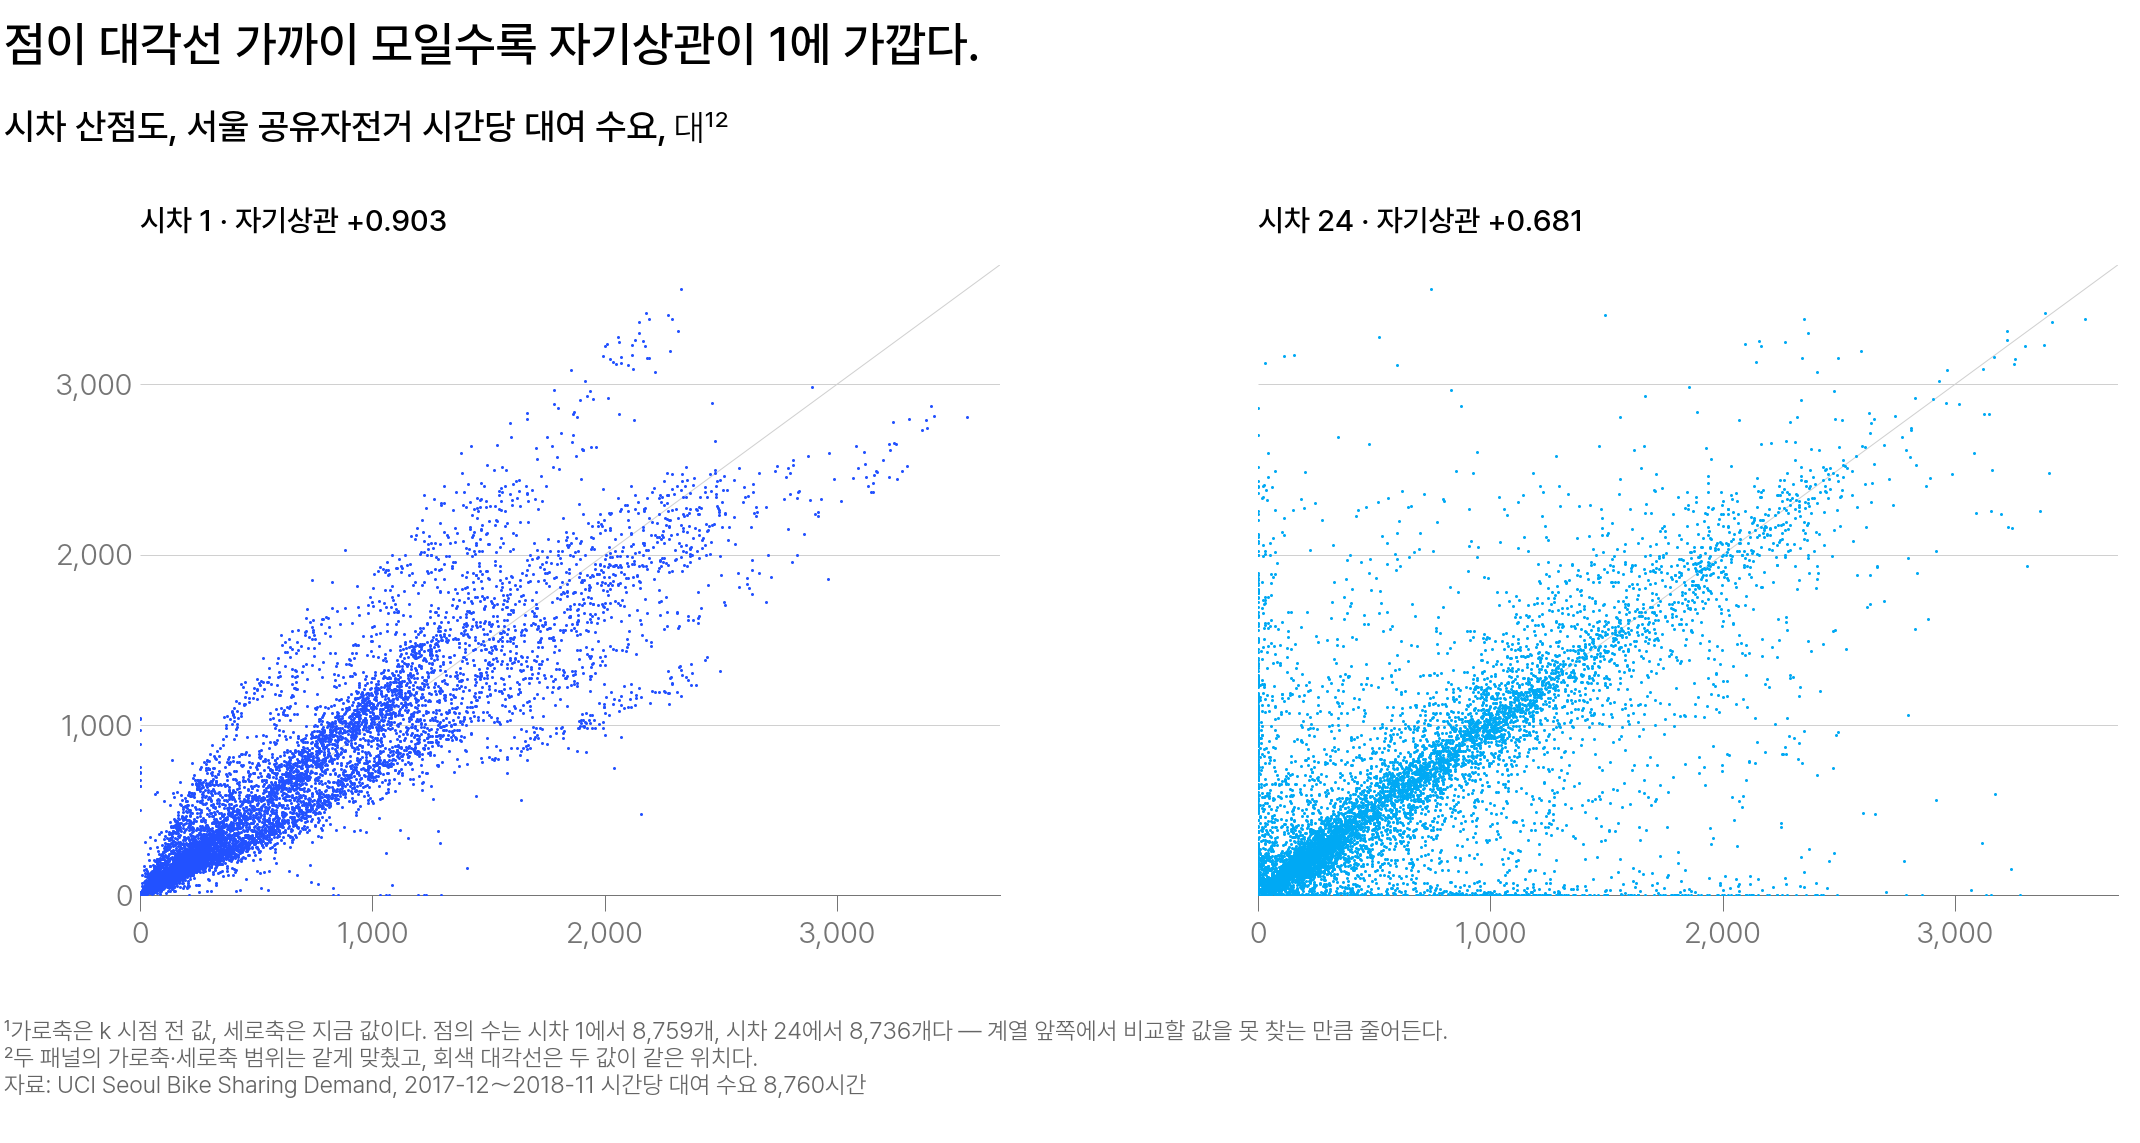

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 시차 산점도 — 시차 1 은 대각선에 좁게 모이고 시차 24 는 멀리 흩어진다</em></p>

**시차 1** 왼쪽 패널은 한 시간 전 값과 지금 값으로 찍은 점 8,759개입니다. 한 시간 전 값을 알면 지금 값을 얼마나 아는지 보는 그림입니다. 점이 대각선에 좁게 모여 있고, 두 값의 차이를 부호 없이 평균하면 178대/시간입니다. 자기상관은 $+0.903$ 입니다.

**시차 24** 오른쪽 패널은 지금 값과 하루 전 같은 시각 값으로 찍은 점 8,736개이고, 점이 대각선에서 더 멀리 떨어집니다. 두 값의 차이를 부호 없이 평균하면 280대/시간입니다. 시차 1 의 178대/시간보다 1.6배 크고, 자기상관은 $+0.681$ 입니다.

## 자기상관을 식으로: 공분산을 분산으로 나누기

$$
\underbrace{\rho_k}_{\text{시차 }k\text{ 자기상관}} = \frac{\overbrace{\gamma_k}^{\text{공분산}}}{\underbrace{\gamma_0}_{\text{분산}}}
$$

- $\gamma_k$ : $k$ 시점 떨어진 두 편차를 곱해 평균한 값, 곧 공분산(covariance)입니다. 자기공분산(autocovariance)이라고도 부릅니다. 편차는 값에서 평균을 뺀 값입니다
- $\gamma_0$ : 편차를 제곱해 평균한 값, 곧 분산입니다

값 5개에 시차 1 을 대입합니다. 이웃한 두 편차의 곱 4개를 더하면 −1.16 이고, 편차의 제곱 5개를 더하면 5.2 입니다. 곱이 4개라도 시차끼리 비교하려고 둘 다 계열 길이 5 로 나눕니다. 그래서 $\gamma_1 = -1.16 \div 5 = -0.232$, $\gamma_0 = 5.2 \div 5 = 1.04$ 입니다.

$$
\rho_1 = \frac{-0.232}{1.04} = -0.223
$$

부호가 음수입니다. 직전보다 크면 다음은 작아진다는 뜻입니다.

같은 식에 이 계열 8,760시간을 넣습니다.

$$
\rho_1 = \frac{375{,}802}{415{,}974} = +0.903
$$

부호가 반대입니다. 이 계열은 한 시간 뒤에도 값이 비슷하기 때문입니다.

#### 왜 공분산을 분산으로 나누는가

단위를 없애려고 나눕니다. 공분산은 값의 단위를 제곱한 단위라, 375,802 만 보아서는 이 수가 큰지 작은지 말할 수 없습니다. 분산도 같은 단위입니다. 둘을 나누면 단위가 서로 지워져 값이 −1 과 +1 사이에 들어오고, 단위가 다른 계열끼리도 나란히 비교할 수 있습니다.

$k$ 가 0 이면 자기 자신과의 상관이라 $\rho_0 = 1$ 로 고정입니다.

<details class="lms-extra"><summary>자세히 — 값 5개로 시차 1 자기상관 −0.223 을 손으로 구하기</summary>

**① 평균과 편차를 구합니다.** 값 $[10,\, 12,\, 11,\, 13,\, 12]$ 의 합은 58 이고 개수가 5 이므로 평균은 11.6 입니다. 각 값에서 평균을 빼면 편차가 $[-1.6,\, +0.4,\, -0.6,\, +1.4,\, +0.4]$ 입니다.

**② 이웃한 편차끼리 곱해 더합니다.** 시차 1 이므로 한 시점 떨어진 두 편차만 곱하고, 그런 곱이 4개입니다.

$$
(0.4)(-1.6) + (-0.6)(0.4) + (1.4)(-0.6) + (0.4)(1.4) = -1.16
$$

**③ 편차를 각각 제곱해 더합니다.**

$$
(-1.6)^2 + (0.4)^2 + (-0.6)^2 + (1.4)^2 + (0.4)^2 = 5.2
$$

**④ ② 를 ③ 으로 나눕니다.**

$$
\rho_1 = \frac{-1.16}{5.2} = -0.223
$$

**⑤ 왜 4 가 아니라 5 로 나누는가.** ② 와 ③ 을 각각 개수로 나누면 $\gamma_1 = -1.16 / 5 = -0.232$, $\gamma_0 = 5.2 / 5 = 1.04$ 입니다. 곱한 값이 4개인데도 4 가 아니라 5 로 나눕니다. 그 곱의 개수가 시차 1 에서 4개, 시차 2 에서 3개로 시차마다 달라져 시차끼리 비교할 수 없기 때문입니다.

분자와 분모의 5 는 약분되므로 ④ 처럼 합끼리 나누기만 해도 같은 값이 나옵니다. 4 로 나누면 $-0.29 / 1.04 = -0.279$ 로 답이 달라집니다.

**⑥ 검산.** 이 값 5개는 이웃한 값의 차이가 $+2,\, -1,\, +2,\, -1$ 로 부호를 번갈아 바꿉니다. 직전보다 크면 다음은 작아지는 경향이 음수 자기상관으로 나온 것이므로 부호가 맞습니다. 아래 코드가 같은 값을 출력합니다.

</details>

## ACF: 시차 1, 2, 3, … 의 자기상관을 한 그림에 늘어놓기

**자기상관함수(ACF, autocorrelation function)** 는 시차별 자기상관을 막대로 배열한 그림입니다. 막대 하나의 높이가 그 시차의 $\rho_k$ 이고, 막대가 다시 커지는 시차를 찾으려고 씁니다.

**백색잡음(white noise)** 은 평균 0, 분산 일정, 이웃끼리 상관이 없는 계열입니다. 모든 시차에서 자기상관이 0 입니다. 되풀이되는 형태도 한 방향 움직임도 없는 계열의 기준이 됩니다. **랜덤워크(random walk)** 는 직전 값에 매 시점 새로 뽑은 무작위 값을 더해 누적하는 계열입니다.

아래 코드는 이 둘과 24시점마다 되풀이되는 주기 24 계열의 자기상관을, 뒤에서 쓸 판정선 값과 함께 구합니다.

In [ ]:
# 자기상관을 정의 그대로 직접 계산해 보기
import numpy as np


def autocorr(y, k):
    # 시차 k 의 자기상관 - 계열과 k 시점 이동시킨 자신의 상관을 분산으로 나눈 값
    y = np.asarray(y, dtype=float)
    m = y.mean()
    num = np.sum((y[k:] - m) * (y[:len(y) - k] - m))   # 겹치는 구간만 곱해 더한다
    den = np.sum((y - m) ** 2)
    return num / den


small = np.array([10, 12, 11, 13, 12], dtype=float)
print(f"직접 계산해 볼 5개 값 {small.astype(int).tolist()} 의 lag 1 자기상관 : {autocorr(small, 1):.3f}")
print()

rng = np.random.default_rng(0)
T = 3000
t = np.arange(T)
wn = rng.normal(0, 1, T)                                          # 백색잡음
rw = np.cumsum(rng.normal(0, 1, T))                               # 랜덤워크
seasonal = 10 * np.sin(2 * np.pi * t / 24) + rng.normal(0, 1, T)  # 주기 24 계열

for name, y in (("백색잡음", wn), ("랜덤워크", rw), ("주기 24 계열", seasonal)):
    vals = " · ".join(f"lag {k:>2} {autocorr(y, k):+.3f}" for k in (1, 12, 24))
    print(f"{name} : {vals}")
print()
print(f"판정선 +-1.96/sqrt(T) = +-{1.96 / np.sqrt(T):.3f}  (T = {T})")

#### 세 계열의 ACF 읽기

출력의 `lag` 는 본문의 시차입니다. 아래 3행이 오늘 기억할 형태 3가지입니다.

| 계열 | 시차 1 | 시차 12 | 시차 24 | 형태와 뜻 |
|---|---|---|---|---|
| 백색잡음 | −0.004 | +0.005 | +0.030 | 모두 0 근처 — 되풀이도 방향도 없다 |
| 랜덤워크 | +0.998 | +0.977 | +0.955 | 큰 양수에서 느린 감소 — 한 방향으로 간다 |
| 주기 24 계열 | +0.947 | −0.977 | +0.973 | 시차 12 는 음수, 시차 24 는 다시 양수 — 24시점마다 되풀이된다 |

시차 12 는 주기 24 의 절반입니다. 지금이 평균보다 높으면 12시점 전은 평균보다 낮아 자기상관이 음수입니다. 시차가 주기와 같아지는 24 에서는 다시 양수가 됩니다.

## 판정선: 이 자기상관이 0 과 구별되는가

**판정선 $\pm 1.96/\sqrt{T}$** 는 자기상관을 0 으로 볼 수 있는 범위를 그은 가로 점선 2개입니다. $T$ 는 계열의 길이입니다.

자기상관이 실제로 0 인 계열에서도, 가진 값으로 계산한 자기상관은 0 에 딱 맞지 않고 0 을 중심으로 조금씩 달라집니다. 그 달라진 값들이 정규분포를 이루고, 가운데 95% 가 표준편차의 1.96배 안에 듭니다. 그 범위가 이 두 선입니다. 안쪽이면 0 과 구별되지 않고, 바깥쪽이면 0 이 아닐 가능성이 큽니다.

$T = 3{,}000$ 인 위 출력은 판정선이 $\pm 0.036$ 이고, 백색잡음의 시차 24 자기상관 $+0.030$ 이 그 안쪽입니다.

- 관측 50개 — $\pm 1.96/\sqrt{50} = \pm 0.28$ 이라 자기상관 0.2 도 0 과 구별되지 않습니다.
- 이 계열의 8,760시간 — $\pm 0.021$ 이라 작은 자기상관도 0 과 구별됩니다.

자기상관이 0 인 계열에서도 막대 하나가 판정선을 벗어날 확률은 0.05 입니다. 그래서 시차 20개를 보면 평균 1개는 그냥 벗어납니다. 주기의 배수마다 막대가 함께 커질 때만 되풀이되는 형태로 봅니다.

<details class="lms-extra"><summary>자세히 — 왜 분모가 T 가 아니라 √T 인가</summary>

**① 참값이 0 인데도 표본 자기상관이 0 에서 얼마나 벗어나는지 구합니다.**

**② 그 크기의 분산부터 적습니다.** 계열이 길수록 작아져, 계열 길이에 반비례합니다.

$$
\operatorname{Var}(\hat\rho_k) \approx \frac{1}{T}
$$

**③ 제곱근을 씌워 표준편차로 바꿉니다.** 선은 분산이 아니라 표준편차로 긋습니다. 분산은 단위가 제곱이라 자기상관과 같은 눈금에 그릴 수 없기 때문입니다.

$$
\operatorname{SD}(\hat\rho_k) \approx \frac{1}{\sqrt{T}}
$$

**④ 1.96 을 곱합니다.** 정규분포에서 가운데 95% 의 경계가 표준편차의 1.96배입니다. 95% 라는 기준은 자연법칙이 아니라 관행으로 정한 값입니다.

$$
\pm\, 1.96 \times \frac{1}{\sqrt{T}}
$$

**⑤ 검산 — 계열이 4배 길어지면.** $T$ 가 50 에서 200 이 되면 ② 의 분산은 4분의 1 입니다. 선은 그 제곱근이라 4분의 1 이 아니라 절반까지만 좁아집니다.

$$
\frac{1.96}{\sqrt{50}} = \pm 0.28 \;\longrightarrow\; \frac{1.96}{\sqrt{200}} = \pm 0.14
$$

</details>

이 계열 8,760시간의 시차 0～72 자기상관을 배열하면 다음과 같습니다.

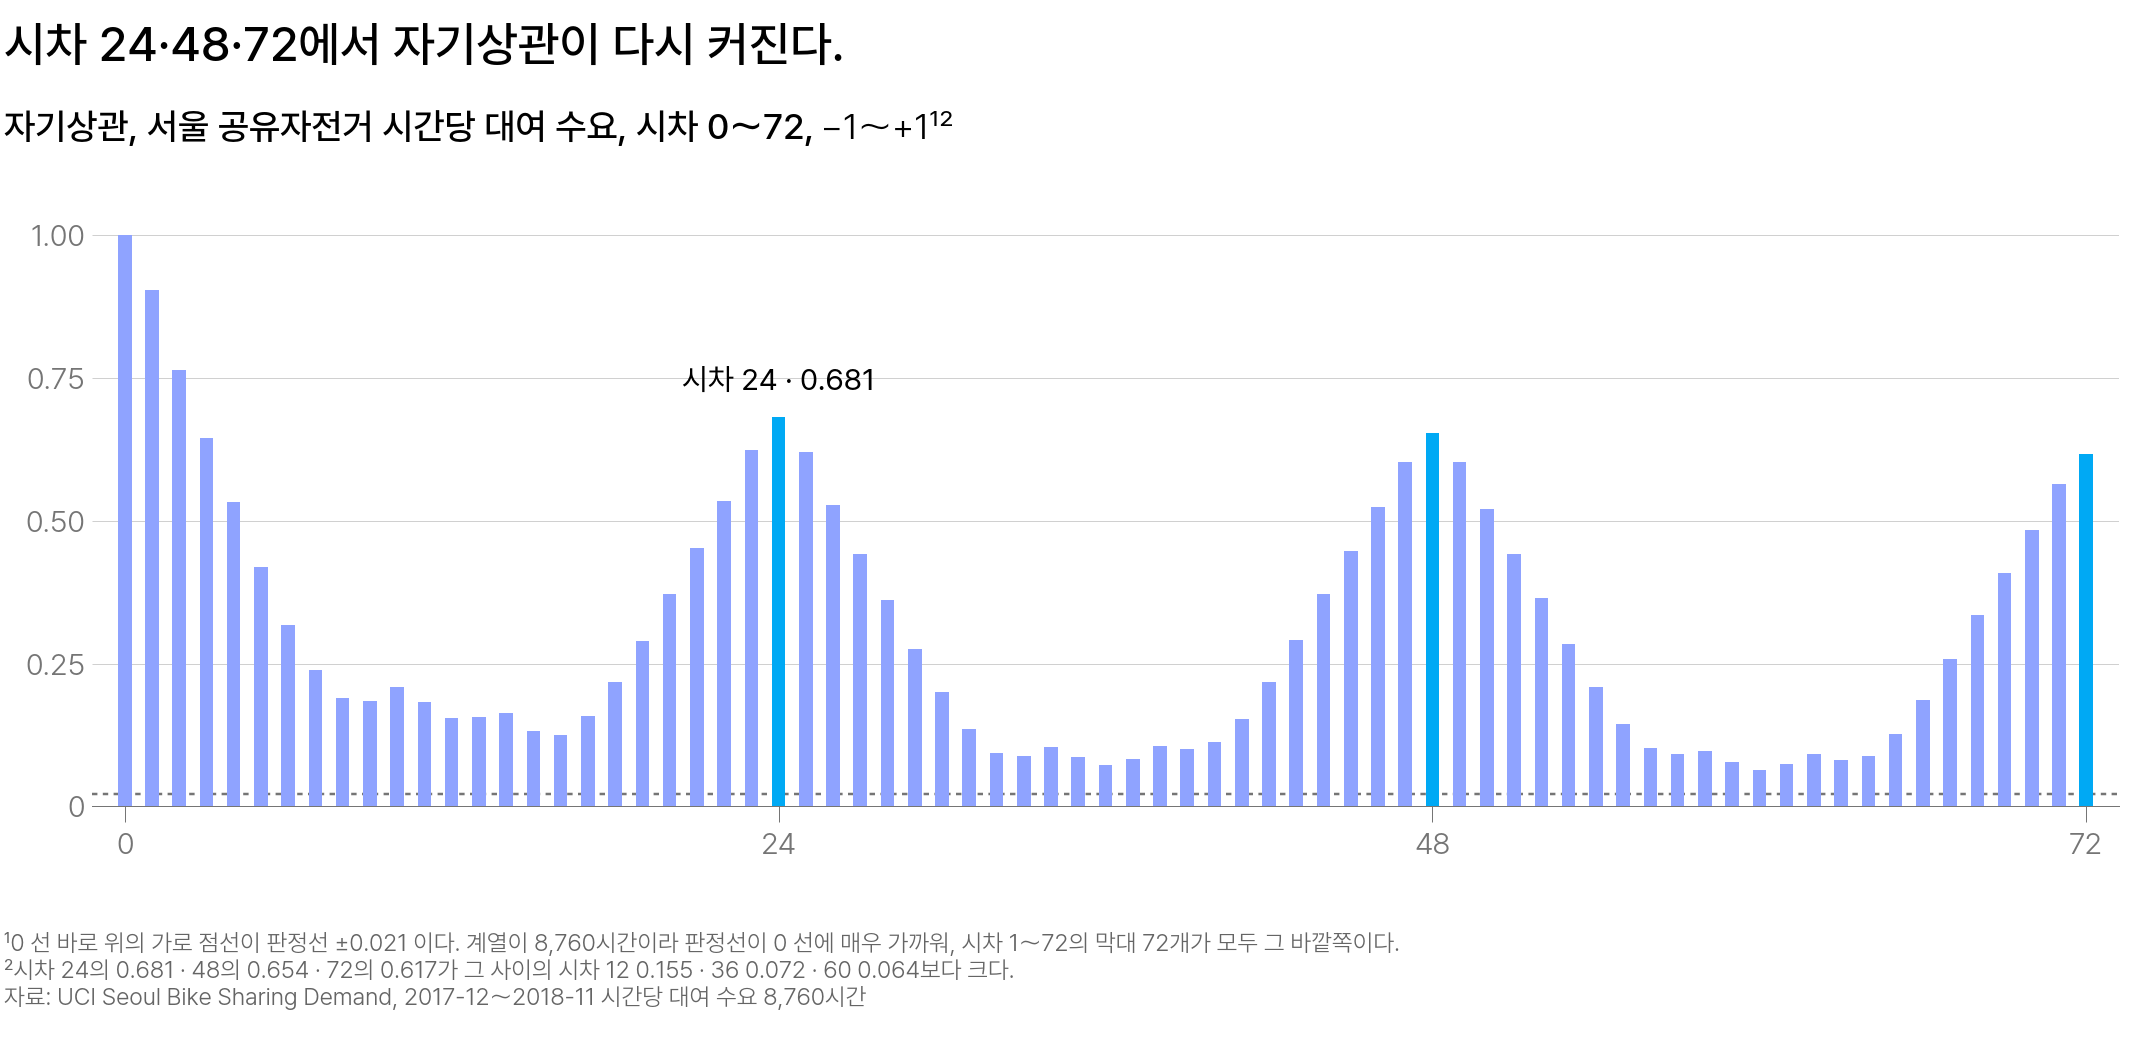

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 시간당 대여 수요의 ACF — 시차 24·48·72 에서 막대가 다시 커진다</em></p>

막대 하나가 앞의 산점도 한 장을 수 하나로 줄인 것입니다.

막대는 시차 1 의 $+0.903$ 에서 시차 12 의 $+0.155$ 까지 내려갑니다. 시차 24 에서 $+0.681$ 로 다시 커지고, 시차 48 의 $+0.654$ 와 72 의 $+0.617$ 도 마찬가지입니다.

24시간마다 다시 커지니 주기는 24 입니다. 앞 출력의 주기 24 계열과 같은 것은 시차 24 에서 다시 커진다는 점입니다.

주기 24 계열은 시차 12 가 음수였지만 이 계열의 시차 12 는 0 위에 있습니다. 대여 수요는 여름에는 하루 종일 많고 겨울에는 하루 종일 적습니다. 그래서 12시간 전 값도 지금과 함께 평균 위이거나 함께 평균 아래입니다.

#### 판정선을 넘으면 무엇을 하는가

판정선 $\pm 0.021$ 바깥에 시차 1 부터 72 까지 막대 72개가 모두 있습니다. 계열이 길면 판정선을 넘었다는 것만으로는 무엇을 할지 정해지지 않습니다. 그래서 그 자기상관으로 예측해 보고 오차가 얼마나 주는지 봅니다.

예측 대상은 8,736시각입니다. 시차 24 는 계열 맨 앞 24시각에 하루 전 값이 없어 8,760시간에서 24시간을 뺀 만큼만 남기 때문입니다.

| 8,736시각을 예측하는 방법 | 예측이 평균 몇 대 빗나가는가(RMSE) | 전체 평균보다 오차가 |
|---|---|---|
| 전체 평균 705대/시간 하나 | 646대/시간 | — |
| 직전 한 시간의 값 (시차 1) | 284대/시간 | 56% 감소 |
| 어제 같은 시각의 값 (시차 24) | 515대/시간 | 20% 감소 |

그래서 시차 1 의 자기상관 $+0.903$ 은 직전 값 하나로 예측해도 될 만큼 큽니다.

추세처럼 값이 한 방향으로 계속 움직여 평균이 시점마다 달라지는 계열을 뒤에서 비정상이라 부릅니다.

> **[예측] 추세가 남아 있어 아직 비정상인 계열의 ACF 는 어떤 모양일까요?**
>
> 1. 처음부터 전부 판정선 안쪽에 있다
> 2. 큰 양수에서 시작해 아주 천천히 줄어든다
> 3. 부호가 매 시차마다 반대가 된다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

앞에서 예측한 답은 두 번째입니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/acfa10-1.png" width="640" height="192"/>
<p align="center"><em>▲ 호주 당뇨약 월 판매액의 ACF — 큰 양수에서 시작해 매우 느리게 감소한다 (출처: fpp3, otexts.com/fpp3)</em></p>

막대는 시차 1 의 약 +0.92 에서 시차 36 의 약 +0.44 까지, 36시차 동안 절반으로밖에 줄지 않습니다. 이 느린 내리막은 어느 한 시차의 신호가 아닙니다. 계열 전체가 한 방향으로 움직인다는 신호입니다. 앞 출력의 랜덤워크와 같은 형태이고, 판매액이 계속 늘면 어느 시차를 골라도 두 값이 함께 크기 때문입니다.

**그래서** ACF 는 되풀이되는 형태가 어느 시차에 있는지 막대 높이로 보여 줍니다.

**한 문장으로** — 자기상관은 지금 값과 $k$ 시점 전 값의 상관계수이고, 다시 커지는 시차가 주기입니다.

## 6. 정상성: 언제 측정해도 같은 값이 나오는 성질

**여기서 할 일**

1. 계열 하나로 과거의 규칙을 계산하려면 무엇이 필요한지 확인합니다.
2. 평균·분산·자기공분산 3조건으로 정상성을 정의합니다.
3. 백색잡음과 랜덤워크를 대조해 판정 기준을 확인합니다.

**정상성(stationarity)** 은 평균·분산·자기공분산이 시점에 의존하지 않는 성질입니다. 일상에서는 「매일 비슷한 시각에 비슷하게 붐비는 카페는 정상」, 「점점 손님이 느는 새 가게는 비정상」이 그 예입니다. 직관적으로 말하면 언제 재도 같은 성질의 계열입니다.

**산포** 는 값들이 중심에서 떨어진 크기이고, 분산이나 표준편차로 측정합니다.

측정 방법은 계열을 같은 길이의 구간으로 자르고 구간마다 평균과 산포를 측정하는 것 하나뿐입니다. 아래 표처럼 값이 6개인 계열이면 3개씩 둘로, 240시점 계열이면 60시점씩 넷으로 자릅니다.

| 계열 | 앞 3개 | 뒤 3개 | 앞 평균 | 뒤 평균 |
|---|---|---|---|---|
| A | 1, −2, 1 | 2, −1, −1 | 0.0 | 0.0 |
| B | 1, 2, 3 | 11, 12, 13 | 2.0 | 12.0 |

A 는 두 구간의 평균이 같고 B 는 달라집니다.

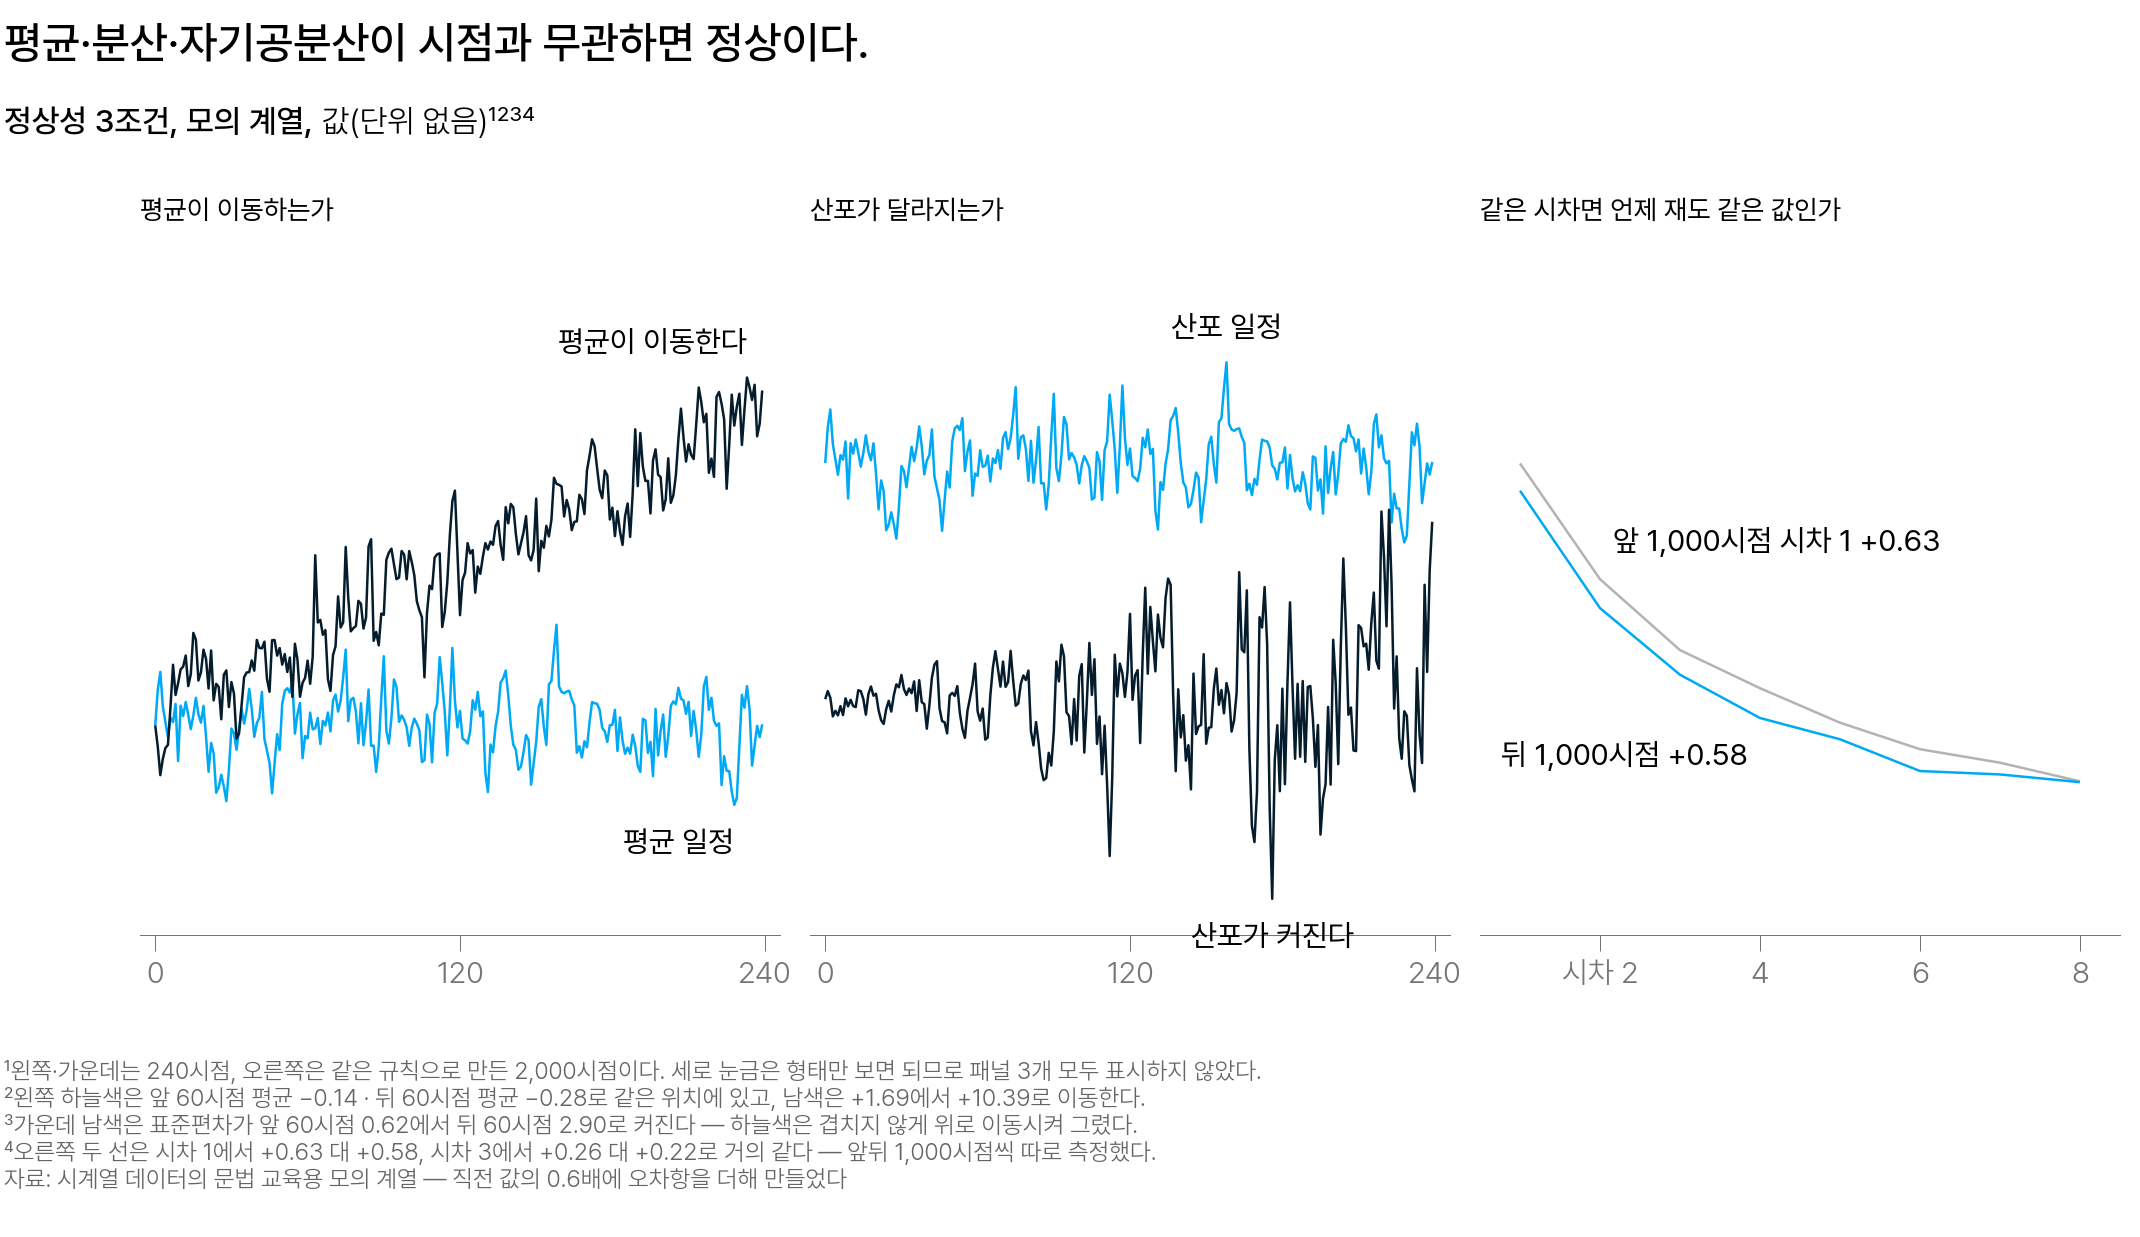

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 정상성이 요구하는 3가지 — 왼쪽은 평균, 가운데는 산포, 오른쪽은 시차별 자기상관이다</em></p>

패널 셋은 조건 셋을 하나씩 보여 줍니다. 셋 다 언제 재도 같은 수이고, 식으로 적으면 이렇습니다.

$$
\mathbb{E}[y_t] = \mu \quad (\text{모든 } t)
$$

$$
\operatorname{Var}(y_t) = \gamma_0 \quad (\text{모든 } t)
$$

$$
\operatorname{Cov}(y_t,\, y_{t-k}) = \gamma_k \quad (t \text{ 와 무관하고 } k \text{ 에만 의존})
$$

- $\mathbb{E}[y_t]$ : 기댓값(expected value)이고, 같은 조건에서 수없이 관측해 평균한 값입니다
- $\mu$ : 시점이 달라도 같은 그 하나의 평균입니다
- $\gamma_0$ : $\operatorname{Var}$ 는 분산을 적는 기호이고, $\gamma_0$ 은 시차 0 의 자기공분산, 곧 분산입니다
- $\gamma_k$ : $\operatorname{Cov}$ 는 공분산을 적는 기호입니다. $\gamma_k$ 는 시차 $k$ 의 자기공분산(autocovariance)이고, 지금 값과 $k$ 시점 전 값이 함께 움직인 정도입니다

앞의 작은 예 A 와 B 를 대입하면 이렇습니다.

- 첫째 식: A 는 $\mu = 0.0$ 하나로 적히고 B 는 적을 수 없습니다
- 둘째 식: A 의 앞 3개도 뒤 3개도 $\gamma_0$ 이 2.0 입니다
- 셋째 식: A 는 값이 6개뿐이라 앞뒤로 갈라 재기에는 짧습니다. 셋째 조건은 이 예로 판정하지 못하고, 여섯 값 전체의 $\gamma_1$ 은 −0.5 입니다

**① 평균이 이동하는가** 앞 60시점과 뒤 60시점의 평균을 비교합니다. 「평균 일정」 곡선은 −0.14 와 −0.28 로 거의 같습니다. 「평균이 이동한다」 곡선은 +1.69 와 +10.39 로 차이가 8.70 입니다. 첫째 식처럼 평균을 한 수 $\mu$ 로 적을 수 있는지가 여기서 갈립니다.

**② 산포가 달라지는가** 같은 두 구간의 표준편차를 봅니다. 「산포가 커진다」 곡선은 0.62 에서 2.90 으로 4.7배가 됩니다. 「산포 일정」 곡선은 1.15 와 1.12 로 비슷합니다. 둘째 식의 $\gamma_0$ 이 시점과 무관한지는 이 차이로 판정합니다.

**③ 같은 시차면 언제 재도 같은 값인가** 정상 계열 2,000시점을 앞뒤 1,000시점씩 잘라 따로 측정했습니다. 시차 1 에서 앞 구간이 $+0.63$, 뒤 구간이 $+0.58$ 입니다. 두 값의 차이 0.05 는 1,000시점에서 자기상관이 우연히 흔들리는 범위 0.062 보다 작습니다. 그래서 셋째 식의 $\gamma_k$ 는 구간이 달라져도 같은 값으로 봅니다.

**표류(drift)** 는 평균이 한 방향으로 천천히 옮겨 가는 것이고, 왼쪽 패널의 「평균이 이동한다」 곡선이 그 모습입니다.

#### 왜 평균·분산·자기공분산이 일정해야 하는가

측정할 계열이 하나뿐이기 때문입니다. 2018년 8월 8일 18시의 대여 수요는 한 번만 관측되고, 같은 조건을 다시 만들 수는 없습니다. 그래서 평균은 시간 방향으로 늘어선 값들을 더해 구합니다.

시점마다 참 평균이 다르면 그 한 수가 무엇의 평균인지 말할 수 없습니다. 분산과 자기공분산도 같은 까닭으로 시점에 의존하지 않아야 합니다.

> **[예측] 위아래로 크게 변동하는 계열과 느리게 표류하는 계열 가운데 비정상인 쪽은 어느 것입니까?**
>
> 1. 크게 변동하는 쪽
> 2. 느리게 표류하는 쪽
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

앞에서 예측한 답은 느리게 표류하는 쪽입니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/White_noise.svg" width="640" height="480"/>
<p align="center"><em>▲ 백색잡음 — 어느 구간을 잘라도 평균과 산포가 비슷하다 (출처: Wikipedia, 시점 0～1,000)</em></p>

**오차항(error term)** 은 앞의 값으로는 예측할 수 없는 새 흔들림입니다. 평균 0 인 수를 매 시점 하나씩 뽑은 것이고, 분해에서 본 잔차가 이 값의 추정값입니다.

**백색잡음(white noise)** 은 그 오차항을 시점 순서대로 적은 계열입니다. 앞의 값을 이어받지 않아 3조건을 모두 만족합니다.

세로 눈금은 0 선 하나뿐입니다. 읽을 것은 0 선 위아래로 오르내린 크기이고, 그 크기가 왼쪽 끝과 오른쪽 끝에서 같습니다.

반대쪽 대표는 랜덤워크입니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Random_Walk_example.svg" width="640" height="480"/>
<p align="center"><em>▲ 랜덤워크 — 경로 8개가 모두 0 에서 출발해 오른쪽으로 갈수록 부채꼴로 퍼진다 (출처: Wikipedia, 시점 0～100 · 세로 범위 약 ±19)</em></p>

**랜덤워크(random walk)** 를 말로 적으면 이번 값은 직전 값에 그 시점의 오차항을 더한 값입니다.

$$
y_t = y_{t-1} + \varepsilon_t
$$

- $y_{t-1}$ : 직전 시점의 값
- $\varepsilon_t$ : 그 시점의 오차항입니다. 평균 0, 분산 $\sigma^2$ 이고 서로 독립입니다

경로 8개는 같은 규칙으로 따로 만든 모의 계열입니다. 계열이 하나뿐인 실제 자료에서는 못 하는 일이지만, 이 그림에서는 한 시점의 산포를 직접 볼 수 있습니다. 어느 시점에서 경로 8개가 차지하는 세로 범위가 그 시점의 산포이고, 오른쪽 끝이 왼쪽 끝보다 넓습니다. 산포가 시점과 함께 커진다는 뜻이고, 그래서 둘째 조건이 성립하지 않습니다.

아래 코드가 두 계열을 구간 넷으로 잘라 평균과 분산이 구간에 따라 달라지는지 확인합니다.

In [ ]:
# 백색잡음과 랜덤워크 - 어느 쪽의 통계적 성질이 시간에 따라 변하나
import numpy as np

rng = np.random.default_rng(42)
T = 2000
eps = rng.normal(0, 1, T)          # 평균 0 · 표준편차 1 의 오차항
wn = eps                           # 백색잡음 = 오차항 그 자체
rw = np.cumsum(eps)                # 랜덤워크 = 오차항을 계속 더해 누적한 것

for name, y in (("백색잡음", wn), ("랜덤워크", rw)):
    a, b, c, d = np.array_split(y, 4)          # 앞에서 뒤로 구간 4개
    means = "  ".join(f"{s.mean():8.2f}" for s in (a, b, c, d))
    stds = "  ".join(f"{s.std():8.2f}" for s in (a, b, c, d))
    print(f"{name} 구간 4개의 평균     : {means}")
    print(f"{name} 구간 4개의 표준편차 : {stds}")
    print()

print("랜덤워크의 분산은 t 에 비례한다 - 이론값 t 와 모의값을 비교한다")
paths = np.cumsum(rng.normal(0, 1, (5000, 400)), axis=1)   # 경로 5,000개
for t in (25, 100, 400):
    print(f"  t = {t:3d} : 모의 분산 {paths[:, t - 1].var():7.1f} / 이론값 {t}")

위 코드는 2,000시점 계열을 500시점씩 구간 넷으로 잘랐습니다. 백색잡음은 구간 넷의 평균이 −0.16 과 −0.00 사이이고, 표준편차는 0.96 과 1.02 사이로 구간마다 같습니다. 랜덤워크는 구간 넷의 평균이 −5.19 · −23.73 · −30.22 · −68.89 로 계속 내려가 첫째 조건이 성립하지 않습니다.

아래쪽 출력의 모의 분산은 $t$ 가 25 · 100 · 400 일 때 24.1 · 101.5 · 387.7 입니다. 시점 번호와 거의 같습니다. 분산이 시점에 비례해 커지므로 둘째 조건도 성립하지 않습니다.

<details class="lms-extra"><summary>자세히 — 랜덤워크의 분산이 왜 시점에 비례하는가</summary>

**① 한 걸음에 더해지는 오차항은 백색잡음과 같은데 랜덤워크는 왜 비정상인지 따져 봅니다.**

**② 오차항이 1, −2, 1 인 경우를 먼저 봅니다.** $y_0 = 0$ 에서 출발한 랜덤워크는 1, −1, 0 입니다.

누적하지 않는 백색잡음은 1, −2, 1 그대로입니다. 랜덤워크는 지금까지의 오차항을 전부 더해 안고 갑니다.

**③ 정의를 한 시점씩 거슬러 올라갑니다.** $y_t = y_{t-1} + \varepsilon_t$ 의 $y_{t-1}$ 에 같은 정의 $y_{t-1} = y_{t-2} + \varepsilon_{t-1}$ 을 대입합니다.

$$
y_t = (y_{t-2} + \varepsilon_{t-1}) + \varepsilon_t
$$

**④ 같은 대입을 $y_0$ 까지 되풀이합니다.** 출발점이 0 이므로 오차항의 합만 남습니다.

$$
y_t = \varepsilon_1 + \varepsilon_2 + \cdots + \varepsilon_t
$$

**⑤ 합의 분산을 각 분산의 합으로 펼칩니다.** 서로 독립인 항들의 합이라 이렇게 펼칠 수 있습니다.

$$
\operatorname{Var}(y_t) = \operatorname{Var}(\varepsilon_1) + \cdots + \operatorname{Var}(\varepsilon_t)
$$

**⑥ 더하는 $t$ 개가 모두 $\sigma^2$ 이므로 곱으로 정리합니다.** $t$ 는 지금까지 더한 오차항의 개수이고 시점 번호와 같습니다. $\sigma^2$ 은 오차항 하나의 분산입니다.

$$
\operatorname{Var}(y_t) = t\,\sigma^2
$$

**⑦ 검산.** $\sigma^2 = 1$, $t = 100$ 을 대입하면 분산이 100 이고 표준편차는 $\sqrt{100} = 10$ 입니다. 위 코드가 경로 5,000개에서 $t = 100$ 의 분산을 101.5 로 산출하므로 이 식과 맞습니다.

</details>

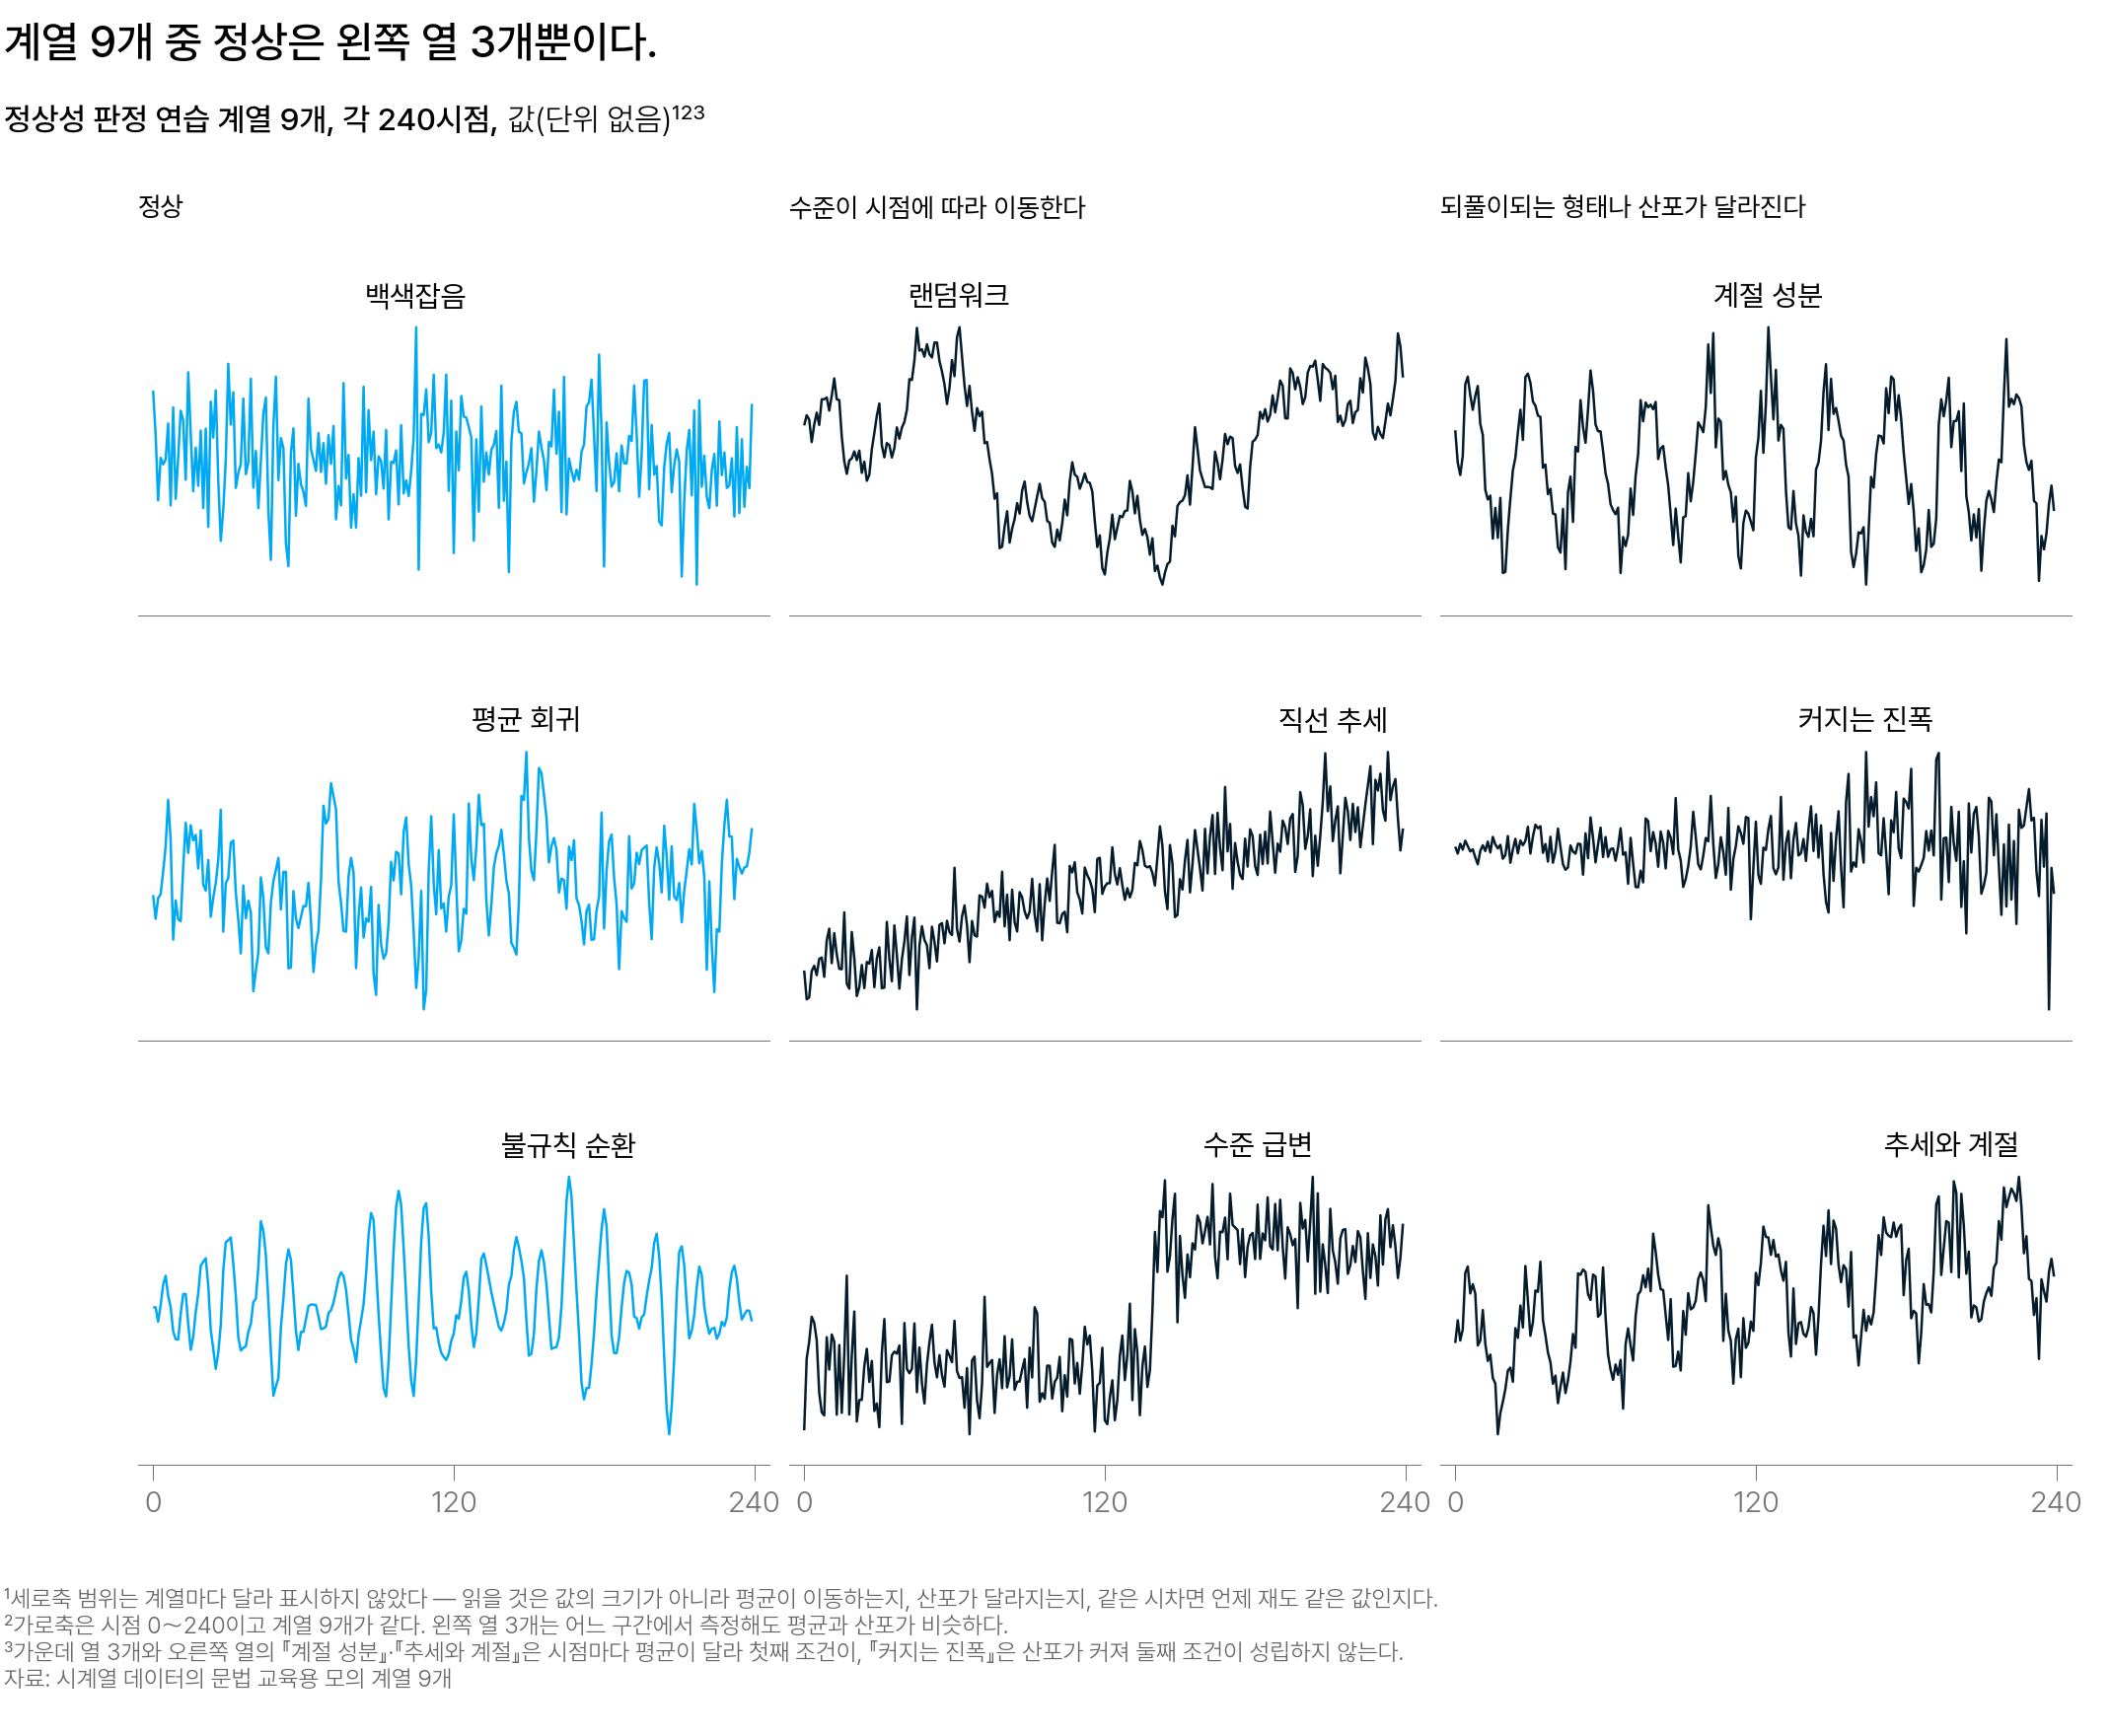

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 모의 계열 9개 — 왼쪽 열 3개만 정상이다</em></p>

이 계열 9개는 앞 코드와 다른 난수로 새로 만들었습니다. 계열마다 60시점씩 구간 넷으로 잘라 평균과 표준편차를 측정했습니다. 표의 「차이」는 구간 평균 넷의 최댓값과 최솟값의 차이이고, 「표준편차」는 구간 표준편차 넷의 최댓값입니다. 구간 평균이 흔들린 범위가 그 구간 값들의 산포 정도면 우연으로 보고, 그보다 크면 수준이 옮겨 간 것으로 봅니다.

`계절 성분` 만 12시점씩 잘랐습니다. 주기 24시점을 한 구간에 다 담으면 큰 값과 작은 값이 상쇄되기 때문입니다.

| 왼쪽 열 — 정상 | 가운데 열 — 수준이 이동한다 | 오른쪽 열 — 형태나 산포가 달라진다 |
|---|---|---|
| `백색잡음` 구간 평균 −0.16 · −0.16 · −0.05 · −0.40 — 차이 0.35 · 표준편차 1.1 | `랜덤워크` 구간 평균 +0.91 · −3.03 · −4.25 · +1.78 — 차이 6.03 · 표준편차 3.1 | `계절 성분` 12시점 구간 20개 중 처음 넷의 평균 +1.88 · −2.00 · +2.05 · −1.78 — 그 넷의 차이 4.05 · 표준편차 1.3 |
| `평균 회귀` 차이 0.73 · 표준편차 1.3 — 커진 값이 다음 시점에 같은 수준으로 복귀한다 | `직선 추세` 차이 5.60 · 표준편차 1.3 — 뒤로 갈수록 평균이 한 방향으로 오른다 | `커지는 진폭` 차이 0.48 로 작지만 구간 표준편차가 0.71 에서 2.74 로 커져 둘째 조건에서 걸린다 |
| `불규칙 순환` 차이 0.58 · 표준편차 3.9 — 큰 값이 되풀이되지만 간격이 일정하지 않다 | `수준 급변` 차이 3.99 · 표준편차 2.2 — 140시점에서 평균이 0 에서 4 로 뛴다 | `추세와 계절` 차이 3.09 · 표준편차 2.2 — 오르는 흐름과 24시점 주기가 겹쳤다 |

첫째 식이 요구하는 것은 시점마다 평균이 정해져 있는가가 아니라, 그 평균이 모든 시점에서 같은 한 수인가입니다. `계절 성분` 은 간격이 일정해 시점 6 은 늘 크고 시점 18 은 늘 작아 시점마다 평균이 다릅니다. `불규칙 순환` 은 간격이 들쭉날쭉해 어느 시점이 클지 정해져 있지 않습니다. 그래서 평균은 어느 시점에서나 같은 수 0 이고, 큰 값이 되풀이되는 것은 경로 하나에 나타난 모양일 뿐입니다.

#### 왜 크게 변동하는 계열이 정상일 수 있는가

판정 기준에 변동의 크기가 없기 때문입니다. 랜덤워크의 분산은 더해 온 오차항의 개수 $t$ 에 오차항 하나의 분산 $\sigma^2$ 을 곱한 값입니다. 오차항의 분산에 양끝 값을 대입해 봅니다.

- $\sigma^2 = 0.01$ : 거의 움직이지 않아 보여도 랜덤워크의 분산은 $t \times 0.01$ 이라 시점과 함께 커져 비정상입니다.
- $\sigma^2 = 100$ : 크게 변동해 보여도 누적하지 않은 백색잡음이면 분산이 늘 100 이라 정상입니다.

**그래서** 정상성은 평균·분산·자기공분산을 한 수로 계산해도 되는지를 가르는 전제입니다.

다음 주제에서 이 판정을 검정으로 바꿉니다.

> **[문제] 변동의 크기와 정상성**
>
> 모의 계열 9개(왼쪽 위 `백색잡음` · 가운데 위 `랜덤워크`)에서 백색잡음은 매 시점 앞의 값과 상관없이 새로 뽑히고, 랜덤워크는 직전 값에서 다시 출발합니다. 비정상인 쪽은 랜덤워크입니다. 위 코드가 출력한 랜덤워크 구간 4개의 평균은 $-5.19 \to -23.73 \to -30.22 \to -68.89$ 였고, 모의 분산은 $t=100$ 에서 101.5 · $t=400$ 에서 387.7 이었습니다. **어느 숫자가 어느 조건이 성립하지 않는다는 증거인지** 연결해 두세 문장으로 적어 보십시오. 백색잡음의 구간 4개 값과 비교하면 더 좋습니다.

## 7. ADF와 KPSS: 귀무가설이 반대인 두 검정

**여기서 할 일**

1. 눈으로 보고 말하던 판정을 두 검정의 답으로 바꿉니다.
2. 직전 값에 곱하는 계수가 1 인지 묻는 ADF 검정을 적용합니다.
3. 묻는 방향이 반대인 KPSS 검정도 적용해, 답 두 개를 맞춰 다음 작업을 정합니다.

**단위근(unit root)** 은 직전 값이 줄지 않고 그대로 전달되는 상태입니다. 「오늘 값 = 어제 값 + 잡음」처럼 직전 값에 곱하는 계수 $\phi$(파이)가 1 이면 계열이 랜덤워크가 됩니다.

작은 수로 봅니다. 어느 시점에 $+10$ 의 충격이 왔다고 하겠습니다. $\phi = 1$ 이면 그 충격이 다음에도 $10$, 그다음에도 $10$ 으로 남습니다. $\phi = 0.5$ 면 $10 \to 5 \to 2.5$ 로 줄어 사라집니다.

일상에도 둘 다 있습니다. 「올해 예금 잔액 = 작년 잔액 + 올해 입출금」은 한 번 입금한 돈이 그대로 남아 단위근입니다. 「오늘 기온이 높아도 며칠 뒤에는 평년 수준이 된다」는 더웠던 날의 영향이 사라져 단위근이 아닙니다.

직관적으로 말하면 충격이 사라지지 않는 계열입니다.

<details class="lms-extra"><summary>자세히 — 왜 「근」이라는 이름인가</summary>

**① 계수 식을 한쪽으로 모읍니다.** $y_t = \phi\, y_{t-1} + \varepsilon_t$ 에서 오차항만 오른쪽에 남깁니다.

$$
y_t - \phi\, y_{t-1} = \varepsilon_t
$$

**② 한 시점 뒤로 미루는 조작을 $L$ 이라는 글자로 적습니다.** $L\, y_t = y_{t-1}$ 이므로 왼쪽이 하나로 묶입니다.

$$
(1 - \phi L)\, y_t = \varepsilon_t
$$

**③ $L$ 을 미지수로 보고 괄호 안을 0 으로 둡니다.**

$$
1 - \phi L = 0
$$

**④ 양변을 정리해 $L$ 만 남깁니다.** $\phi L = 1$ 이 되므로 양변을 $\phi$ 로 나눕니다. 이렇게 구한 해를 그 식의 **근(root)** 이라 합니다.

$$
L = \frac{1}{\phi}
$$

**⑤ 계수에 1 을 대입합니다.** 「단위」는 1 을 뜻하므로, 근이 1 인 이 상태를 단위근이라 부릅니다.

$$
L = \frac{1}{1} = 1
$$

**⑥ 검산.** $\phi = 0.5$ 를 대입하면 근이 $L = 2$ 라 1 이 아닙니다. 앞의 작은 수에서 충격이 $10 \to 5 \to 2.5$ 로 사라진 것과 같은 상태입니다.

</details>

**귀무가설(null hypothesis, $H_0$)** 은 참이라고 일단 두는 문장 하나입니다. 데이터가 그 문장과 너무 어긋나면 문장을 버립니다. 버리는 것이 **기각**이고, 버리지 못하면 비기각입니다.

두 검정은 이 문장을 반대로 둡니다.

- **ADF 검정** — 귀무가설이 「단위근이 있다」입니다. 기각하면 정상 쪽 증거입니다.
- **KPSS 검정** — 귀무가설이 「정상이다」입니다. 기각하면 비정상 쪽 증거입니다.

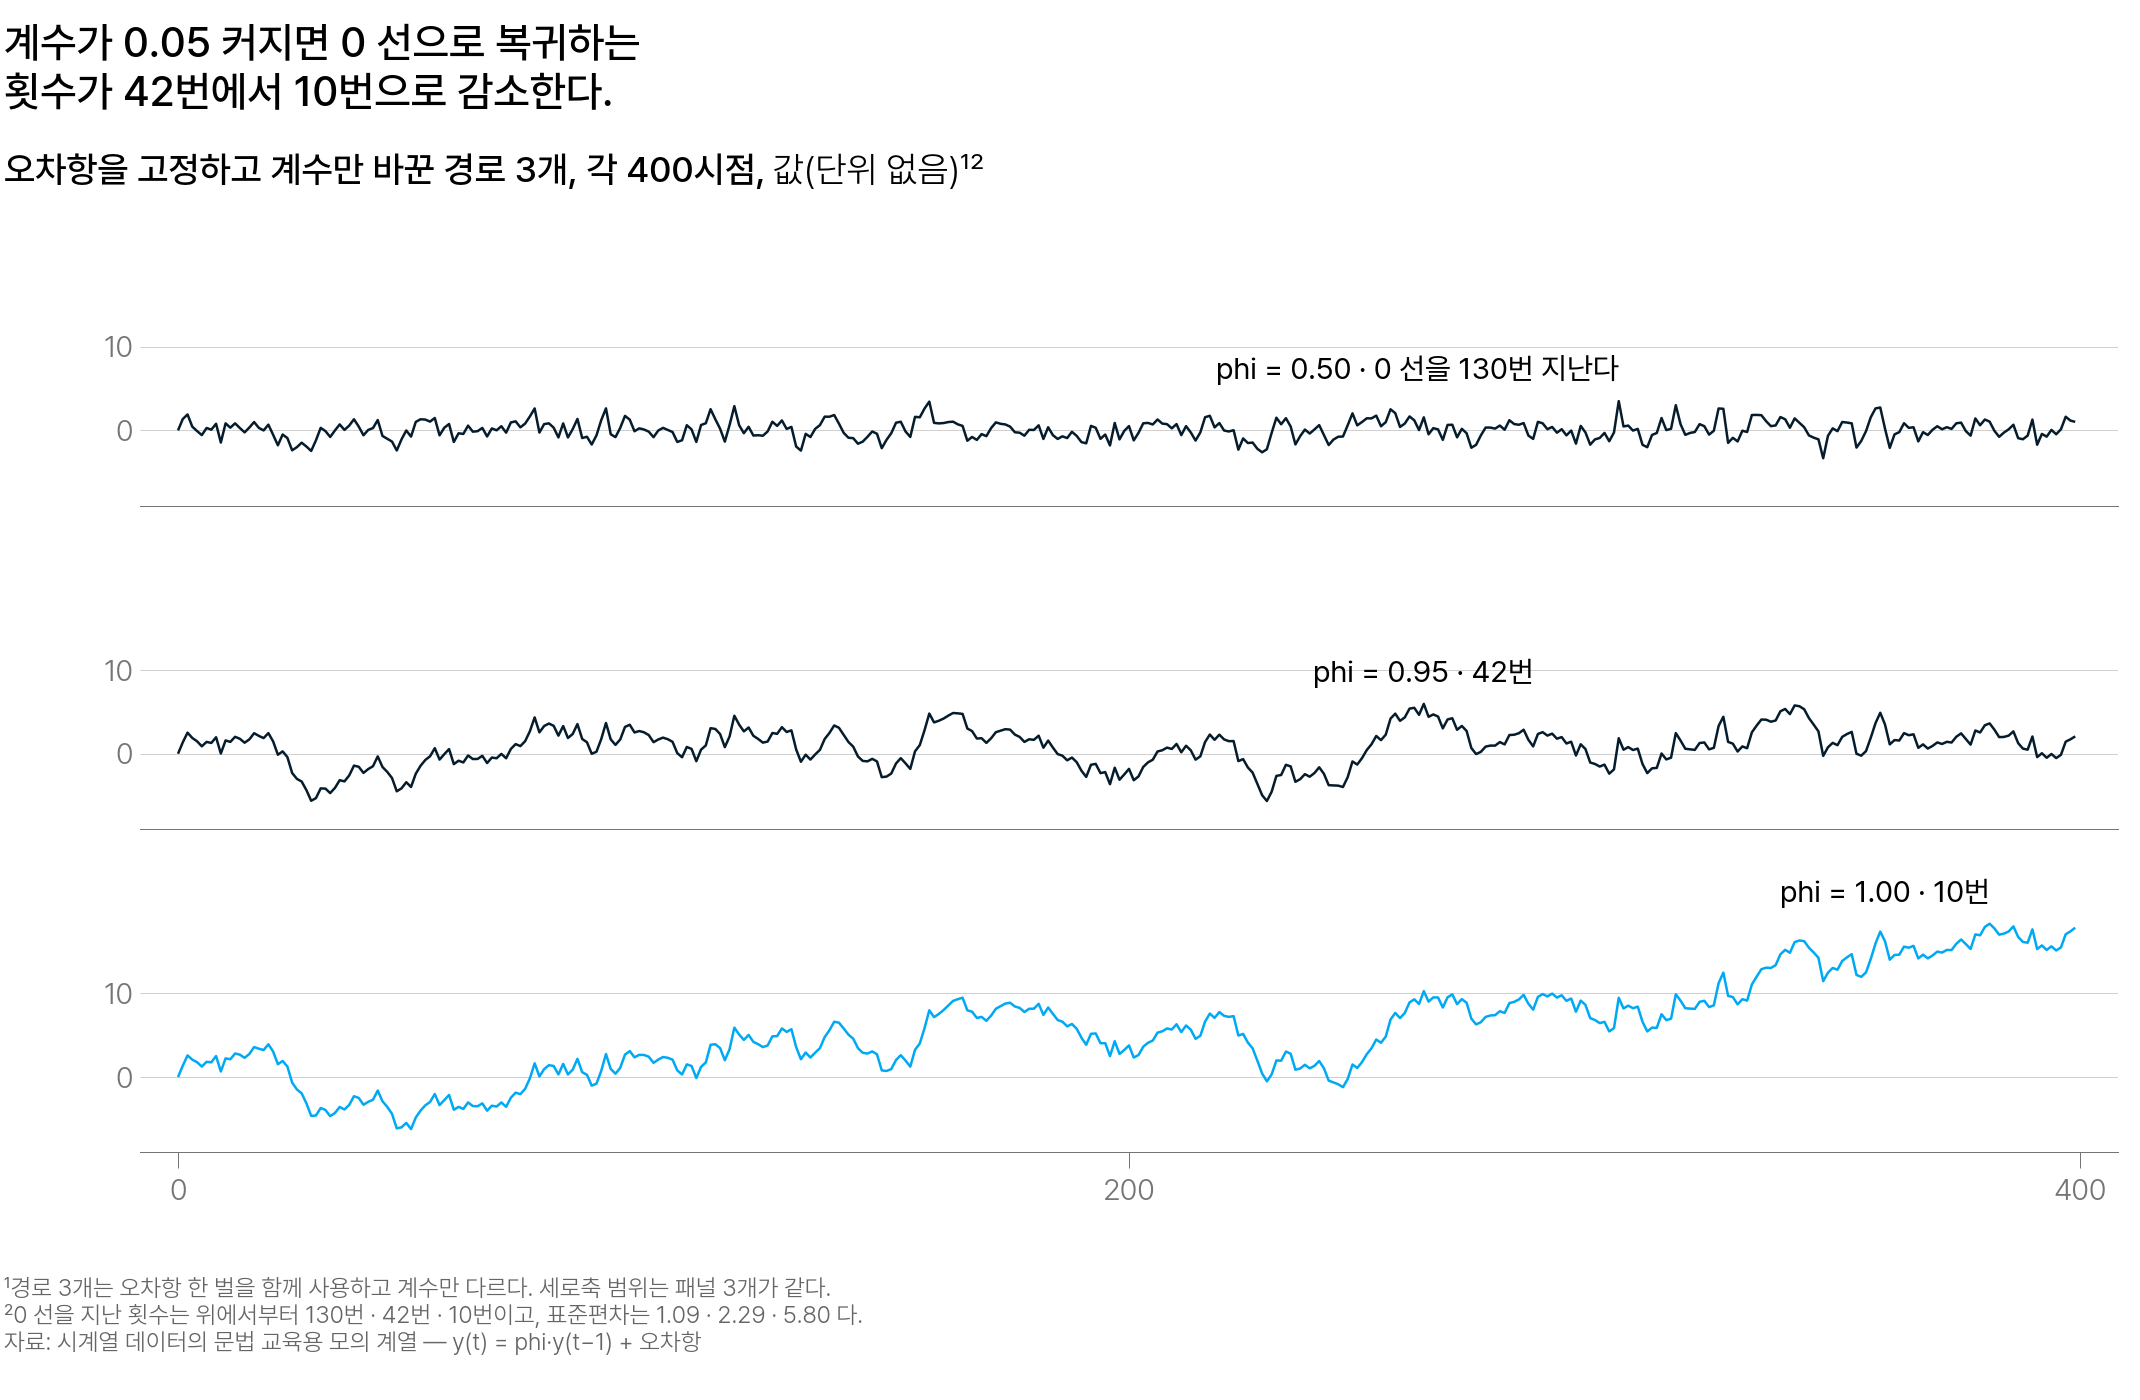

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 계수 phi 만 0.50, 0.95, 1.00 으로 바꾼 경로 3개 — 오차항과 세로축 범위는 같다</em></p>

패널마다 적힌 수는 400시점 동안 계열이 0 선을 지난 횟수입니다. 많이 지날수록 흔들린 뒤 원래 수준으로 빨리 복귀합니다.

**① 계수 0.50** 400시점 동안 0 선을 130회 지납니다. 셋 가운데 가장 많습니다.

**② 계수 0.95** 같은 400시점에서 42회로 줄었습니다. 느리지만 복귀합니다.

**③ 계수 1.00** 같은 400시점에서 10회뿐입니다. 0 선을 지나는 횟수가 이렇게 적다는 것은 한 번 멀어진 값이 오래 복귀하지 않는다는 뜻입니다. 예를 들어 어느 시점의 값이 4 였다면 다음 값도 4 에서 출발합니다. 원래 수준으로 복귀하지 않고, 복귀할 수준이 없는 이 상태가 단위근입니다.

검정이 측정하는 것은 이 복귀입니다.

$$
\underbrace{y_t}_{\text{현재 값}} = \underbrace{\phi}_{\text{전달 계수}}\, \underbrace{y_{t-1}}_{\text{직전 값}} + \underbrace{\varepsilon_t}_{\text{오차항}}
$$

직전 값이 4 이고 오차항이 0 이면 다음 값은 $0.50 \times 4 = 2$ 입니다.

- $\varepsilon_t$ (엡실론) : 그 시점에 새로 더해지는 무작위 값입니다. 앞에서 본 백색잡음이 이것입니다.

$\phi$ 가 1 보다 작으면 평균으로 복귀해 정상입니다.

## ADF 검정: 「단위근이 있다」를 기각할 수 있는가

**ADF 검정(Augmented Dickey-Fuller test)** 은 계수 하나를 측정해 판정합니다.

ADF 가 묻는 것은 「단위근이 있는가」 하나입니다. 귀무가설은 「단위근이 있다」, 곧 비정상입니다.

통계량이 측정하는 대상은 $\phi$ 가 아니라 $\gamma = \phi - 1$ 입니다.

$$
\underbrace{\Delta y_t}_{\text{한 시점의 변화량}} = \underbrace{\gamma}_{\phi - 1}\,\underbrace{y_{t-1}}_{\text{직전 값}} + \underbrace{\varepsilon_t}_{\text{오차항}}
$$

- $\gamma$ (감마) : 검정식의 계수입니다. 앞의 자기공분산 $\gamma_k$ 와 글자만 같습니다.

$\phi = 0.50$ 이면 $\gamma = 0.50 - 1 = -0.50$ 입니다. 직전 값이 4 이면 변화량이 $-0.50 \times 4 = -2$ 라 4 에서 2 로 내려갑니다. 정상인 계열은 $\gamma$ 가 음수이고, 단위근이 있는 계열은 $\gamma$ 가 정확히 0 입니다.

그래서 귀무가설을 기호로 쓰면 $H_0:\ \gamma = 0$ 입니다. **대립가설(alternative hypothesis, $H_1$)** 은 귀무가설을 버렸을 때 대신 받아들이는 문장입니다. 여기에서는 $H_1:\ \gamma < 0$, 곧 「계수가 음수라 평균으로 복귀한다」입니다.

p값은 귀무가설이 참일 때 이만큼 극단적인 결과가 나올 확률입니다. 기각하는 경계는 0.05 로 정합니다. 이 경계를 **유의수준(significance level)** 이라 합니다. p = 0.03 은 기각, p = 0.30 은 비기각입니다.

**검정통계량** 은 데이터로 측정한 $\hat{\gamma}$ 를 그 측정의 흔들림 크기로 나눈 값입니다. $\gamma$ 가 0 에서 얼마나 떨어졌는지를 나타내는 수입니다. 이름의 'Augmented(증강된)' 는 검정식에 변화량 항을 몇 개 더 더해 계산한다는 뜻입니다.

<details class="lms-extra"><summary>자세히 — 「계수가 1 인가」를 「계수가 0 인가」로 바꾸는 한 걸음</summary>

**① 단위근은 $\phi$ 가 1 인 상태인데 검정은 왜 $\gamma$ 가 0 인지를 묻는 까닭을 봅니다.**

**② 식이 하나인 모형에서 출발합니다.**

$$
y_t = \phi\, y_{t-1} + \varepsilon_t
$$

**③ 양변에서 $y_{t-1}$ 을 뺍니다.** 왼쪽은 한 시점의 변화량이 되고, 오른쪽은 공통인 $y_{t-1}$ 로 묶입니다.

$$
y_t - y_{t-1} = (\phi - 1)\, y_{t-1} + \varepsilon_t
$$

**④ 왼쪽을 $\Delta y_t$ 로 줄여 적습니다.** 다음 주제에서 정의할 차분이 이 값입니다.

$$
\Delta y_t = (\phi - 1)\, y_{t-1} + \varepsilon_t
$$

**⑤ 계수 덩어리에 이름을 부여합니다.** $\gamma = \phi - 1$ 로 두면 「계수가 0 인가」를 묻는 회귀의 계수 검정을 그대로 쓸 수 있습니다. $\phi$ 가 1 에 가까워질수록 $\gamma$ 도 0 에 가까워지므로 같은 질문입니다.

$$
\Delta y_t = \gamma\, y_{t-1} + \varepsilon_t
$$

**⑥ 검산.** $\gamma = \phi - 1$ 에 대입하면 $\phi = 0.5$ 일 때 −0.5, $\phi = 0.95$ 일 때 −0.05, $\phi = 1$ 일 때 0 입니다. 아래 코드가 400시점 경로 3개에서 측정한 $\hat{\gamma}$ 는 −0.525, −0.091, −0.010 이고, 대입한 값과의 차이가 셋 다 0.05 안입니다. 400시점 하나에서 측정한 값이라 소수점까지 같지는 않습니다.

경로 그림만 보고 정상과 비정상을 가를 수는 없습니다. 계수 $\phi$ 가 0.95 에서 1.00 으로 0.05 커진 것만으로 판정이 기각에서 비기각으로 바뀝니다.

</details>

In [ ]:
# 파이(phi)가 1 에 접근할 때 - 같은 오차항에 계수만 바꿔 계열 3개를 만든다
import numpy as np


def gamma_and_t(y):
    # 위에서 유도한 식 그대로 - dy = a + gamma * y_(t-1) 을 최소제곱으로 맞춘다
    dy = np.diff(y)
    X = np.column_stack([np.ones(len(dy)), y[:-1]])
    beta = np.linalg.lstsq(X, dy, rcond=None)[0]
    resid = dy - X @ beta
    s2 = resid @ resid / (len(dy) - 2)                  # 잔차 분산
    se = np.sqrt(s2 * np.linalg.inv(X.T @ X)[1, 1])     # gamma 의 표준오차
    return beta[1], beta[1] / se


rng = np.random.default_rng(11)
eps = rng.normal(0, 1, 400)          # 오차항은 하나로 고정하고 phi 만 바꾼다

for phi in (0.5, 0.95, 1.0):
    y = np.zeros(400)
    for t in range(1, 400):
        y[t] = phi * y[t - 1] + eps[t]
    g, tstat = gamma_and_t(y)
    print(f"phi = {phi:4.2f} : 표준편차 {y.std():5.2f} · gamma {g:+.3f} · 검정통계량 {tstat:7.2f}")

print()
print("5% 임계값 -2.87 - 통계량이 이보다 더 음수면 단위근 없음(정상) 쪽")

#### ADF 출력 읽기: 검정통계량과 임계값 비교하기

출력은 다음과 같습니다.

```
phi = 0.50 : 표준편차  1.09 · gamma -0.525 · 검정통계량  -11.87
phi = 0.95 : 표준편차  2.29 · gamma -0.091 · 검정통계량   -4.35
phi = 1.00 : 표준편차  5.80 · gamma -0.010 · 검정통계량   -1.14

5% 임계값 -2.87 - 통계량이 이보다 더 음수면 단위근 없음(정상) 쪽
```

판정에 쓰는 값은 검정통계량입니다. 통계량이 임계값보다 더 음수라는 것과 p값이 0.05 보다 작다는 것은 같은 판정입니다.

**임계값(critical value)** 은 귀무가설이 참인 계열을 수없이 만들어 통계량을 모았을 때 아래쪽 5% 가 시작되는 지점입니다. 관측 수에 따라 조금씩 달라져 관측 400개인 이 계산에서는 −2.87 입니다.

이 출력의 수에 5% 판정을 더하면 이렇습니다.

| 계수 $\phi$ | 측정값 $\hat{\gamma}$ | 검정통계량 | 5% 판정 |
|---|---|---|---|
| 0.50 | −0.525 | −11.87 | 기각 |
| 0.95 | −0.091 | −4.35 | 기각 |
| 1.00 | −0.010 | −1.14 | 비기각 |

## KPSS 검정: 「정상이다」를 기각할 수 있는가

**왜 검정을 하나 더 하는가.** ADF 의 비기각은 입증이 아니라 증거 부족이기 때문입니다. 

**KPSS 검정(Kwiatkowski-Phillips-Schmidt-Shin test)** 을 함께 적용합니다.

KPSS 가 묻는 것은 「평균이 시점에 따라 달라지는가」입니다. 귀무가설은 「정상이다」입니다.

통계량이 측정하는 대상은 누적합입니다. 평균을 뺀 값을 차례로 더한 것입니다.

평균이 10 인 한 계열에서 세 시점씩 두 군데를 떼어 봅니다. 앞의 12, 8, 11 은 평균을 뺀 값이 2, −2, 1 이고 누적합이 2, 0, 1 입니다. 뒤의 12, 13, 14 는 뺀 값이 2, 3, 4 이고 누적합이 2, 5, 9 로 커집니다.

누적합을 제곱해 모두 더하면 앞은 $4 + 0 + 1 = 5$, 뒤는 $4 + 25 + 81 = 110$ 으로 22배입니다. 이 제곱합이 클수록 그 계열은 정상에서 멉니다. KPSS 통계량은 이 제곱합을 시점 수의 제곱과 계열의 분산으로 나눈 값입니다. 그래서 길이가 다른 계열도 같은 임계값으로 판정합니다.

두 검정의 기각과 비기각을 곱하면 결과 조합이 2 × 2 = 4가지입니다. 이 계열에서 어느 조합이 나올지 예상해 보십시오.

> **[예측] 시간당 수요 계열에 ADF 와 KPSS 를 함께 적용하면 어떤 조합이 나옵니까?**
>
> 1. ADF 기각 · KPSS 비기각 — 둘 다 정상이라고 말한다
> 2. ADF 비기각 · KPSS 기각 — 둘 다 비정상이라고 말한다
> 3. 둘 다 기각 — 서로 반대 방향을 지시한다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss

try:
    raw = load_csv("datasets/SeoulBikeData.csv")            # 실행 카드가 주는 읽기 함수
except NameError:                                           # 이 함수가 없는 곳에서는 원본을 받는다
    SRC = ("https://archive.ics.uci.edu/static/public/560/"
           "seoul+bike+sharing+demand.zip")
    raw = pd.read_csv(SRC, encoding="cp1252", compression="zip")
raw = raw.rename(columns={"Date": "date", "Hour": "hour",
                          "Rented Bike Count": "count"})    # 원본 열 이름을 줄인다
stamp = (pd.to_datetime(raw["date"], format="%d/%m/%Y")     # 01/12/2017 = 2017년 12월 1일
         + pd.to_timedelta(raw["hour"], unit="h"))          # 그 행의 시각을 더한다
hourly = pd.Series(raw["count"].values, index=stamp).sort_index()
daily = hourly.resample("D").sum()                          # 시간당 8,760개 -> 일 수요 365개

for name, s in (("시간 계열", hourly), ("일 수요  ", daily)):
    a = adfuller(s)                                # (통계량, p값, …)
    k = kpss(s, regression="c", nlags="auto")      # (통계량, p값, 시차, 임계값표)
    print(f"{name} · ADF {a[0]:6.2f} (p = {a[1]:.3f})"
          f" · KPSS {k[0]:6.3f} (p = {k[1]})")
print("KPSS 임계값표", k[3])                        # 통계량을 이 표와 견준다

출력은 다음과 같습니다.

```
시간 계열 · ADF  -6.95 (p = 0.000) · KPSS  8.005 (p = 0.01)
일 수요   · ADF  -2.60 (p = 0.094) · KPSS  1.838 (p = 0.01)
KPSS 임계값표 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
```

출력의 `시간 계열` 이 시간당 수요입니다.

KPSS 는 p값 대신 통계량을 임계값과 비교합니다. 5% 임계값 0.463 보다 크면 기각입니다. 출력의 p = 0.01 은 조회표가 다루는 가장 작은 값이라 「0.01 이하」로 읽습니다.

시간당 수요의 ADF 검정통계량은 −6.95 입니다. 5% 임계값 −2.86 보다 더 음수라 기각입니다. KPSS 통계량은 8.005 입니다. 5% 임계값 0.463 의 약 17배라 이쪽도 기각입니다.

<details class="lms-extra"><summary>자세히 — 출력의 p값이 0.01 에서 멈춘 이유</summary>

KPSS 는 통계량을 임계값 조회표와 맞추어 p값을 계산합니다. 그 조회표가 다루는 범위는 0.01 에서 0.1 입니다. 통계량이 1% 임계값 0.739 보다 크면 계산할 수 있는 가장 작은 값인 0.01 이 그대로 나옵니다. 시간당 수요의 8.005 와 일 수요의 1.838 이 모두 이 경우입니다.

`regression="c"` 는 「정상이다」를 「평균이 시점에 따라 달라지지 않는다」로 둔 것입니다. 여기에서는 직선 추세를 따로 가정하지 않으므로 이 설정을 씁니다. 보고서에는 「유의수준 5%, KPSS 는 `regression="c"`」를 함께 적어 둘째 날로 전달합니다.

</details>

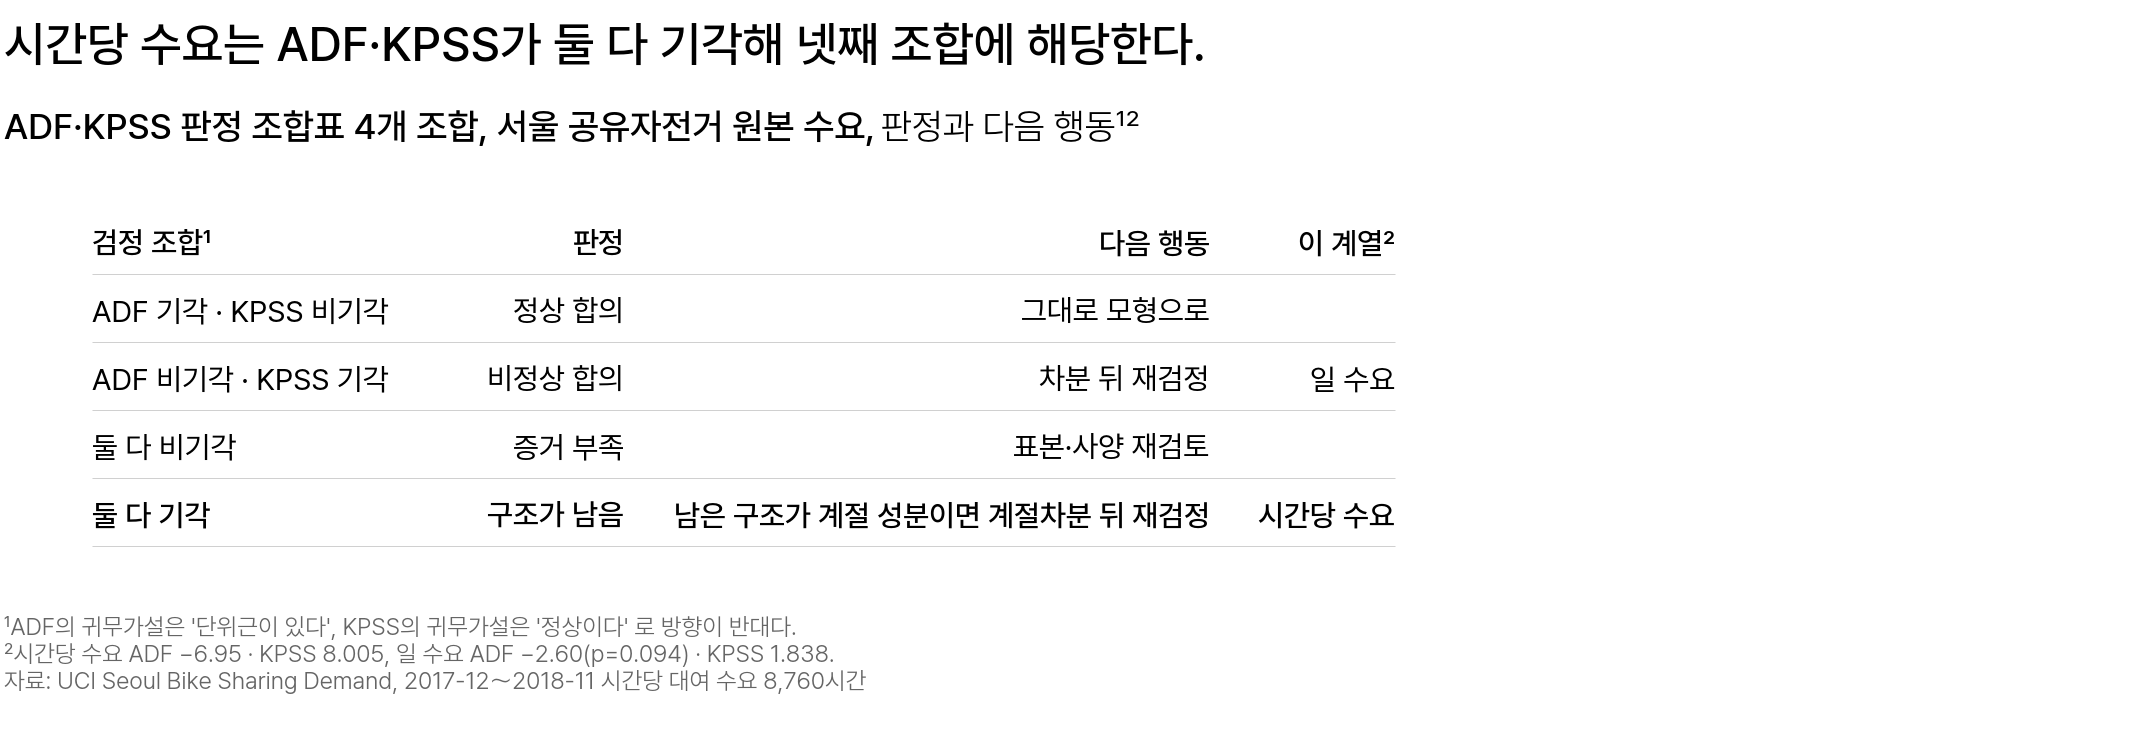

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ ADF·KPSS 판정 조합 4가지 — 두 검정이 모두 기각한 넷째 행이 시간당 수요다</em></p>

앞에서 예측한 답은 세 번째 보기(둘 다 기각)입니다.

표의 다음 행동에 나오는 **차분(differencing)** 은 이웃한 두 값의 차이를 새 계열로 삼는 일입니다. 24시간 계절차분은 24시간 전 값과의 차이를 씁니다. 다음 주제에서 다룹니다.

| ADF | KPSS | 두 답을 합치면 | 다음에 하는 일 |
|---|---|---|---|
| 기각 | 비기각 | 둘 다 정상 쪽 | 그대로 다음 단계로 간다 |
| 비기각 | 기각 | 둘 다 비정상 쪽 | 차분한 뒤 다시 검정한다. 일 수요가 여기다 |
| 비기각 | 비기각 | 어느 쪽도 판정하지 못했다 | 표본이 짧아 증거가 모자란 것이다. 구간을 늘려 다시 본다 |
| 기각 | 기각 | 두 답의 방향이 반대다 | 남은 구조를 보고 그에 맞는 차분을 고른다. 시간당 수요가 여기다 |

둘째 행의 일 수요는 ADF p = 0.094 로 비기각, KPSS 는 기각이었습니다. p = 0.094 를 0.05 에 가까우니 정상으로 본다고 읽지 않습니다. 기준을 정했으면 그 기준으로 판정합니다.

넷째 행에서 두 답의 방향이 반대인 것은 묻는 것이 다르기 때문입니다. ADF 가 판정하는 것은 단위근 하나뿐이라 「랜덤워크는 아니다」까지만 말합니다. 시간당 수요는 겨울에 낮은 값이, 여름에 높은 값이 이어져 누적합이 0 에서 멀어집니다.

둘을 합치면 「랜덤워크는 아닌데 평균이 달라진다」입니다. 평균을 달라지게 하는 구조 가운데 앞에서 측정한 계절 강도가 가장 컸던 것은 하루 주기입니다. 그래서 24시간 계절차분을 먼저 적용합니다.

**그래서** 판정은 검정 하나로 끝나지 않습니다.

**한 문장으로** — 귀무가설이 반대인 ADF 와 KPSS 를 함께 읽어 조합표의 위치를 정하고, 비정상이면 다음 작업은 차분입니다.

> **[문제] ADF p = 0.30 과 KPSS p = 0.01 의 판정**
>
> 어떤 계열에 두 검정을 적용했더니 ADF 는 p = 0.30, KPSS 는 p = 0.01 이 나왔습니다. 유의수준 5% 기준으로 이 조합이 ADF·KPSS 판정 조합표의 어느 조합인지 밝히고, 판정과 다음 행동을 두세 문장으로 적어 보십시오.

## 8. 차분: 비정상을 정상으로 바꾸는 변환

**여기서 할 일**

1. 판정이 비정상일 때 무엇을 쓸지 정합니다.
2. 레벨 차분과 계절차분을 실제 값으로 계산해 봅니다.
3. 필요 이상으로 차분한 신호를 숫자로 확인합니다.

비정상이라는 판정은 무엇을 쓸지까지 알려 주지 않습니다. 원인마다 쓰는 변환이 다릅니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/a10diff-1.png" width="589" height="559"/>
<p align="center"><em>▲ 당뇨약 월 판매액 — 로그가 진폭을, 뺄셈이 수준을 없앤다 (출처: fpp3, otexts.com/fpp3)</em></p>

**① 원계열** 당뇨약의 월 판매액입니다. 1992년 약 3백만 달러에서 2008년 약 3천만 달러로 오릅니다. 한 해 안의 최댓값과 최솟값 차이도 약 2백만에서 약 1천6백만 달러로 커집니다. 진폭이 **수준(level)**, 곧 계열이 머물러 온 높이를 따라 커지면 비정상입니다.

**② 로그 판매액** 세로축은 판매액을 백만 달러 단위로 한 자연로그 값입니다. 1992년의 1.2 는 약 3.3백만 달러이고, 값은 2008년 3.0 까지 오릅니다. 그런데 한 해 안의 최댓값과 최솟값 차이는 어느 해나 0.5～0.9 로 비슷합니다. 로그 값이 1 크면 판매액은 약 2.7배이고, 로그를 씌우면 진폭만 따로 다룰 수 있습니다.

**③ 로그 판매액에서 1년 전 값을 뺀 것** 12개월이 한 주기라 이 뺄셈이 아래 표의 계절차분입니다. 1년 전과의 로그 차이는 0.1 부근에서 오르내립니다. 계절 성분과 수준이 이 뺄셈 하나로 함께 없어집니다.

| 원인 | 무엇으로 아는가 | 쓰는 변환 |
|---|---|---|
| 진폭이 수준에 비례해 커진다(승법 구조) | 월별 표준편차가 평균을 따라 커진다 | 로그 |
| 수준이 한 방향으로 이동한다(확률적 추세) | ACF 막대가 시차 1 부터 천천히만 줄어든다 | 레벨 차분 — 직전 값을 뺀다 |
| 같은 형태가 한 주기마다 되풀이된다(계절 성분) | ACF 막대가 주기의 배수에서 다시 커진다 | 계절차분 — 한 주기 전 값을 뺀다 |

둘째 행의 **확률적 추세(stochastic trend)** 는 오차항이 누적되어 수준이 이동하는 비정상입니다.

**로그는 이 계열에 쓰지 않습니다.** 시간당 대여 수요는 월별 표준편차가 평균의 0.62～0.82배라, 평균이 큰 달에는 표준편차도 함께 큽니다. 표의 첫째 행입니다.

그런데 1년 8,760시간 가운데 수요가 0 인 시각이 295개입니다. 로그는 0 에서 정의되지 않아 뺄셈만 씁니다.

## 차분(differencing): 일정 시점 전의 값을 빼기

**차분(differencing)** 은 값에서 일정 시점 전의 값을 빼 새 계열로 삼는 일입니다. 일상에서는 「오늘 몸무게 − 어제 몸무게」, 「이번 달 매출 − 지난달 매출」이 그 예입니다. 직관적으로 말하면 값 대신 변화만 보는 일입니다.

- **레벨 차분(first differencing)** — 바로 이웃한 값을 뺍니다. 몇 번 빼는지가 차수 $d$ 입니다.
- **계절차분(seasonal differencing)** — 한 주기 전 값을 뺍니다. 그 횟수가 차수 $D$ 입니다.

2018년 8월의 세 시각으로 계산해 봅니다.

#### 레벨 차분: 직전 값을 뺀다

$$
\underbrace{\Delta y_t}_{\text{한 시간 변화}} = \underbrace{y_t}_{\text{그 시각}} - \underbrace{y_{t-1}}_{\text{한 시점 전}}
$$

8월 9일 02시를 시점 $t$ 로 두면 $-267 = 466 - 733$ 입니다.

- $y_t$ 는 02시의 466대/시간, $y_{t-1}$ 은 01시의 733대/시간입니다

새 계열의 값은 그 시각의 수요가 아니라 한 시간 사이에 늘거나 줄어든 양입니다. 양수면 늘어난 시각, 음수면 줄어든 시각입니다.

왜 뺄셈이 수준 이동을 지우는가. 랜덤워크에서 직전 값을 빼면 누적된 수준이 사라지고 오차항만 남아, 남은 계열이 정상이 됩니다.

<details class="lms-extra"><summary>자세히 — 랜덤워크에서 직전 값을 빼면 백색잡음이 되는 과정</summary>

**① 뺄셈 한 번이 어떻게 누적된 수준을 지우는지 확인합니다.**

**② 랜덤워크의 식에서 출발합니다.** $\varepsilon_t$ 는 그 시점에 처음 생기고 앞의 항으로 설명되지 않는 오차항이며, 평균 0 · 분산 $\sigma^2$ 입니다.

$$
y_t = y_{t-1} + \varepsilon_t
$$

**③ 양변에서 $y_{t-1}$ 을 뺍니다.** 오른쪽의 $y_{t-1}$ 이 소거되고 오차항만 남습니다. 지금까지 누적된 수준이 여기에서 통째로 사라집니다.

$$
y_t - y_{t-1} = \varepsilon_t
$$

**④ 왼쪽을 레벨 차분의 기호로 바꿔 적습니다.** 남은 것은 모든 시차에서 자기상관이 0 인 백색잡음이라, 비정상의 대표가 정상의 대표로 바뀝니다.

$$
\Delta y_t = \varepsilon_t
$$

**⑤ 검산.** 아래 코드가 랜덤워크에 레벨 차분을 1회 적용해 얻은 값은 분산 0.983, 시차 1 자기상관 +0.006 입니다. 백색잡음의 자기상관 0 에 대응합니다.

</details>

#### 계절차분: 어제 같은 시각의 값을 뺀다

$$
\underbrace{\Delta_m y_t}_{\text{하루 변화}} = y_t - \underbrace{y_{t-m}}_{\text{한 주기 전}}
$$

시간당 수요는 하루가 한 주기라 $m = 24$ 입니다. 앞과 같은 8월 9일 02시를 시점 $t$ 로 두면 $-23 = 466 - 489$ 입니다.

- $y_{t-m}$ 은 하루 전인 8월 8일 02시의 489대/시간입니다

두 시각 모두 새벽 02시라 그 시각의 낮은 수요가 양쪽에 들어 있습니다. 빼면 그만큼이 사라집니다. 남은 −23 은 하루 전 같은 시각보다 23대/시간 적다는 뜻이고, 새 계열에는 이 −23 이 들어갑니다. 앞에서 구한 같은 시각의 레벨 차분 −267대/시간에는 01시에서 02시로 내려간 몫이 들어 있습니다.

1년 8,760시간 전체에 계절차분을 하면 평균이 705 에서 0.8대/시간으로 내려갑니다. 평균이 0 근처라는 것은 계열이 머물러 온 높이가 사라졌다는 뜻입니다. 표준편차는 645 에서 515대/시간으로 내려갑니다. 남은 515대/시간은 하루 전 같은 시각과의 차이가 그만큼 크다는 뜻입니다.

원인이 수준 이동인지 계절 성분인지는 ACF 로 가립니다. 이 계열의 ACF 는 시차 24·48·72 에서 막대가 다시 커집니다. 주기의 배수에서 커지는 것은 하루 주기가 원인이라는 뜻이라 계절차분을 씁니다.

그래서 차수를 $d$ 가 아니라 $D$ 로 적습니다. $D = 1$ 이고, 더 키우면 **과차분(over-differencing)** 입니다. 필요 이상으로 뺀 상태라는 뜻이고, 아래에서 숫자로 확인합니다.

<details class="lms-extra"><summary>자세히 — 계절차분 뒤 시차 24 의 자기상관이 왜 음수인가</summary>

**① 계절차분 뒤에 시차 24 의 자기상관이 왜 음수로 남는지 알아봅니다.**

계열에서 계절 성분 $S_t$ 를 따로 적고 나머지를 오차항 $\varepsilon_t$ 라 하면 다음과 같습니다.

$$
y_t = S_t + \varepsilon_t
$$

- $S_t$ : 한 주기마다 같은 형태로 되풀이되는 계절 성분입니다
- $\varepsilon_t$ : 그 시점에 처음 발생하고 앞의 항으로 설명되지 않는 오차항입니다

**② 계절차분의 정의에 대입하고 같은 종류끼리 묶습니다.**

$$
\Delta_m y_t = (S_t - S_{t-m}) + (\varepsilon_t - \varepsilon_{t-m})
$$

**③ 계절 성분은 한 주기마다 같은 값이라 $S_t = S_{t-m}$ 이므로, 앞 괄호를 0 으로 소거합니다.** 앞에서 계산한 8월 9일 02시와 8월 8일 02시는 $m = 24$ 만큼 떨어진 두 시각입니다. 두 시각의 계절 성분이 같은 값이면 $S_t - S_{t-24} = 0$ 입니다.

$$
\Delta_m y_t = \varepsilon_t - \varepsilon_{t-m}
$$

상쇄되는 것은 되풀이되던 계절 성분이고 오차항은 상쇄되지 않습니다.

**④ 시차 $m$ 만큼 떨어진 값도 같은 모양으로 적습니다.** ② 의 $t$ 를 $t - m$ 으로 바꾼 것입니다.

$$
\Delta_m y_{t-m} = \varepsilon_{t-m} - \varepsilon_{t-2m}
$$

**⑤ 두 식을 곱해 평균합니다.** $\varepsilon_{t-m}$ 은 ③ 에서 빼는 항이고 ④ 에서는 더하는 항이라, 곱하면 $-\varepsilon_{t-m}^2$ 이 남습니다. 시점이 서로 다른 나머지 세 항은 상관이 없어 평균이 0 입니다.

$$
\operatorname{Cov}(\Delta_m y_t,\, \Delta_m y_{t-m}) = -\,\mathbb{E}[\varepsilon_{t-m}^2]
$$

제곱의 평균은 0 보다 크므로 오른쪽은 음수이고, 시차 $m$ 의 자기상관도 음수입니다.

**⑥ 검산.** 시간당 수요에 주기 24 의 계절차분을 적용하면 시차 24 의 자기상관이 −0.46 입니다.

</details>

#### 차분을 두 번 하면 무엇이 잘못되는가

차수 $d$ 를 올릴수록 좋아질 것 같습니다.

> **[예측] 이미 정상이 된 계열에 차분을 한 번 더 적용하면 무엇이 달라집니까?**
>
> 1. 더 안정되어 분산이 줄어든다
> 2. 분산이 오히려 커지고 시차 1 자기상관이 음수로 크게 내려간다
> 3. 아무 변화가 없다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

In [ ]:
# 차분은 많이 적용할수록 좋아지나 - 레벨 차분 1회와 2회를 비교한다
import numpy as np


def autocorr(y, k):
    # 시차 k 의 자기상관 - 정의 그대로
    y = np.asarray(y, dtype=float)
    m = y.mean()
    return np.sum((y[k:] - m) * (y[:len(y) - k] - m)) / np.sum((y - m) ** 2)


rng = np.random.default_rng(7)
rw = np.cumsum(rng.normal(0, 1, 4000))     # 랜덤워크 - 차분 한 번이 정답인 계열
d1 = np.diff(rw)                           # 레벨 차분 1회
d2 = np.diff(d1)                           # 레벨 차분 2회

for name, y in (("원계열      ", rw), ("레벨 차분 1회", d1), ("레벨 차분 2회", d2)):
    print(f"{name} : 분산 {y.var():8.3f} · 시차 1 자기상관 {autocorr(y, 1):+.3f}")

#### 시차 1 자기상관으로 차수가 맞는지 보기

앞에서 예측한 답은 두 번째입니다. 차분한 계열의 **시차 1 자기상관** 은 너무 많이 뺐는지를 알려 줍니다.

| 시차 1 자기상관 | 무엇을 뜻하는가 | 위 출력 |
|---|---|---|
| +1 근처 | 이웃한 두 값이 거의 같이 움직인다 | 랜덤워크 원계열 +0.996 |
| 0 근처 | 직전 값을 알아도 지금 값을 짐작할 수 없다 — 더 뺄 필요가 없다 | 레벨 차분 1회 +0.006 |
| −0.5 근처 | 필요 이상으로 한 번 더 뺐다 — **과차분** 의 신호다 | 레벨 차분 2회 −0.502 |

차수를 더 키우면 분산도 커집니다. 위 출력에서 레벨 차분 1회의 분산 0.983 이 2회에서 1.955 로 1.99배입니다.

이 계열은 어떤가. 24시간 계절차분한 시간당 수요의 시차 1 자기상관은 +0.881 입니다. 이 수는 너무 많이 뺐는지만 알려 주므로, 첫째 줄에 가까워도 한 번 더 빼지는 않습니다. 정상인지 아닌지는 바로 아래에서 ADF·KPSS 가 정합니다.

−0.5 가 나와도 차분 전이 비정상이었다면 그 차분은 필요했던 것입니다.

| 차분 전 판정 | 차분 뒤 시차 1 자기상관 | 하는 일 |
|---|---|---|
| 비정상 | −0.5 근처 | 이미 뺀 차분은 그대로 두고 더 빼지 않는다 |
| 정상 — 차분이 필요 없었다 | −0.5 근처 | 차분하기 전 계열로 복원해 차수를 1 낮춘다 |

<details class="lms-extra"><summary>자세히 — 한 번 더 차분하면 −0.5 가 나오는 과정</summary>

**① 과차분의 신호가 왜 하필 −0.5 인지 구해 봅니다.**

**② 무엇을 한 번 더 차분하는지 정합니다.** 레벨 차분 1회로 이미 백색잡음 $\varepsilon_t$ 가 된 계열을 한 번 더 차분하면 새 계열은 $w_t = \varepsilon_t - \varepsilon_{t-1}$ 입니다. $\varepsilon_t$ 는 평균 0, 분산 $\sigma^2$ 이고 서로 다른 시점끼리는 상관이 없습니다.

**③ 새 계열의 분산을 구합니다.** 차의 분산 공식을 펼칩니다.

$$
\operatorname{Var}(\varepsilon_t - \varepsilon_{t-1}) = \operatorname{Var}(\varepsilon_t) + \operatorname{Var}(\varepsilon_{t-1}) - 2\operatorname{Cov}(\varepsilon_t,\, \varepsilon_{t-1})
$$

**④ 시점이 다른 두 오차항은 상관이 없으므로 마지막 항을 0 으로 지웁니다.** 남은 두 항이 모두 $\sigma^2$ 입니다.

$$
\operatorname{Var}(w_t) = 2\sigma^2
$$

**⑤ 이웃한 두 값의 공분산을 구합니다.** 먼저 한 시점 전의 값을 적습니다. $w_t = \varepsilon_t - \varepsilon_{t-1}$ 에서 $t$ 를 $t - 1$ 로 바꾼 것입니다.

$$
w_{t-1} = \varepsilon_{t-1} - \varepsilon_{t-2}
$$

두 값을 곱해 네 항으로 펼칩니다.

$$
\operatorname{Cov}(w_t, w_{t-1}) = \mathbb{E}[\varepsilon_t \varepsilon_{t-1}] - \mathbb{E}[\varepsilon_t \varepsilon_{t-2}] - \mathbb{E}[\varepsilon_{t-1}^2] + \mathbb{E}[\varepsilon_{t-1}\varepsilon_{t-2}]
$$

**⑥ 시점이 다른 항은 0 이고 같은 시점의 제곱은 $\sigma^2$ 이므로 대입합니다.** 겹치는 항이 하나뿐이라 음수만 남습니다.

$$
\operatorname{Cov}(w_t, w_{t-1}) = -\sigma^2
$$

**⑦ 공분산을 분산으로 나눕니다.** $\sigma^2$ 이 약분되어 계열이 무엇이든 −0.5 가 나옵니다.

$$
\rho_1 = \frac{-\sigma^2}{2\sigma^2} = -0.5
$$

**⑧ 검산.** 위 코드의 오차항은 `rng.normal(0, 1, 4000)` 이라 $\sigma^2 = 1$ 이고, ④ 의 $2\sigma^2$ 은 2 입니다. 산출값은 분산이 1.955, 시차 1 자기상관이 −0.502 로 나왔습니다. 남은 차이는 표본이 유한해서 생긴 변동입니다.

</details>

<img src="https://otexts.com/fpp3/fpp_files/figure-html/acfstationary-1.png" width="640" height="224"/>
<p align="center"><em>▲ 구글 종가와 하루 변화량의 ACF — 차분 1회로 느린 감소가 사라진다 (출처: fpp3, otexts.com/fpp3)</em></p>

**① 구글 종가의 ACF** 차분 전입니다. 자기상관이 시차 1 에서 0.97, 12 에서 0.78, 24 에서 0.58 근처이고, 막대 24개가 모두 판정선 ±0.12 밖입니다. 느리게만 줄어드는 이 모양이면 수준이 이동하고 있다는 뜻이라 비정상입니다.

**② 하루 변화량의 ACF** 레벨 차분 1회 뒤입니다. 시차 1 이 +0.10 이고 나머지는 거의 판정선 안입니다. 판정선 안의 막대는 0 과 구별되지 않으니, 차분으로 그 모양이 없어졌습니다.

**차분한 뒤에는 다시 검정하고 ACF 를 다시 그립니다.** 시간당 수요를 24시간 계절차분하면 ADF 통계량 −17.0, KPSS 통계량 0.008 입니다. 둘 다 5% 임계값(−2.86, 0.463) 기준으로 정상 쪽이라 계절차분 1회로 정상이 되었습니다.

**한 문장으로** — 원인에 맞는 뺄셈을 한 뒤 다시 검정합니다.

## 9. 이 계열의 판정과 오늘의 정리

**여기서 할 일**

1. 준비 5단계를 한 장으로 봅니다.
2. 주제마다 답한 질문을 정리합니다.
3. 둘째 날로 전달할 값을 정합니다.

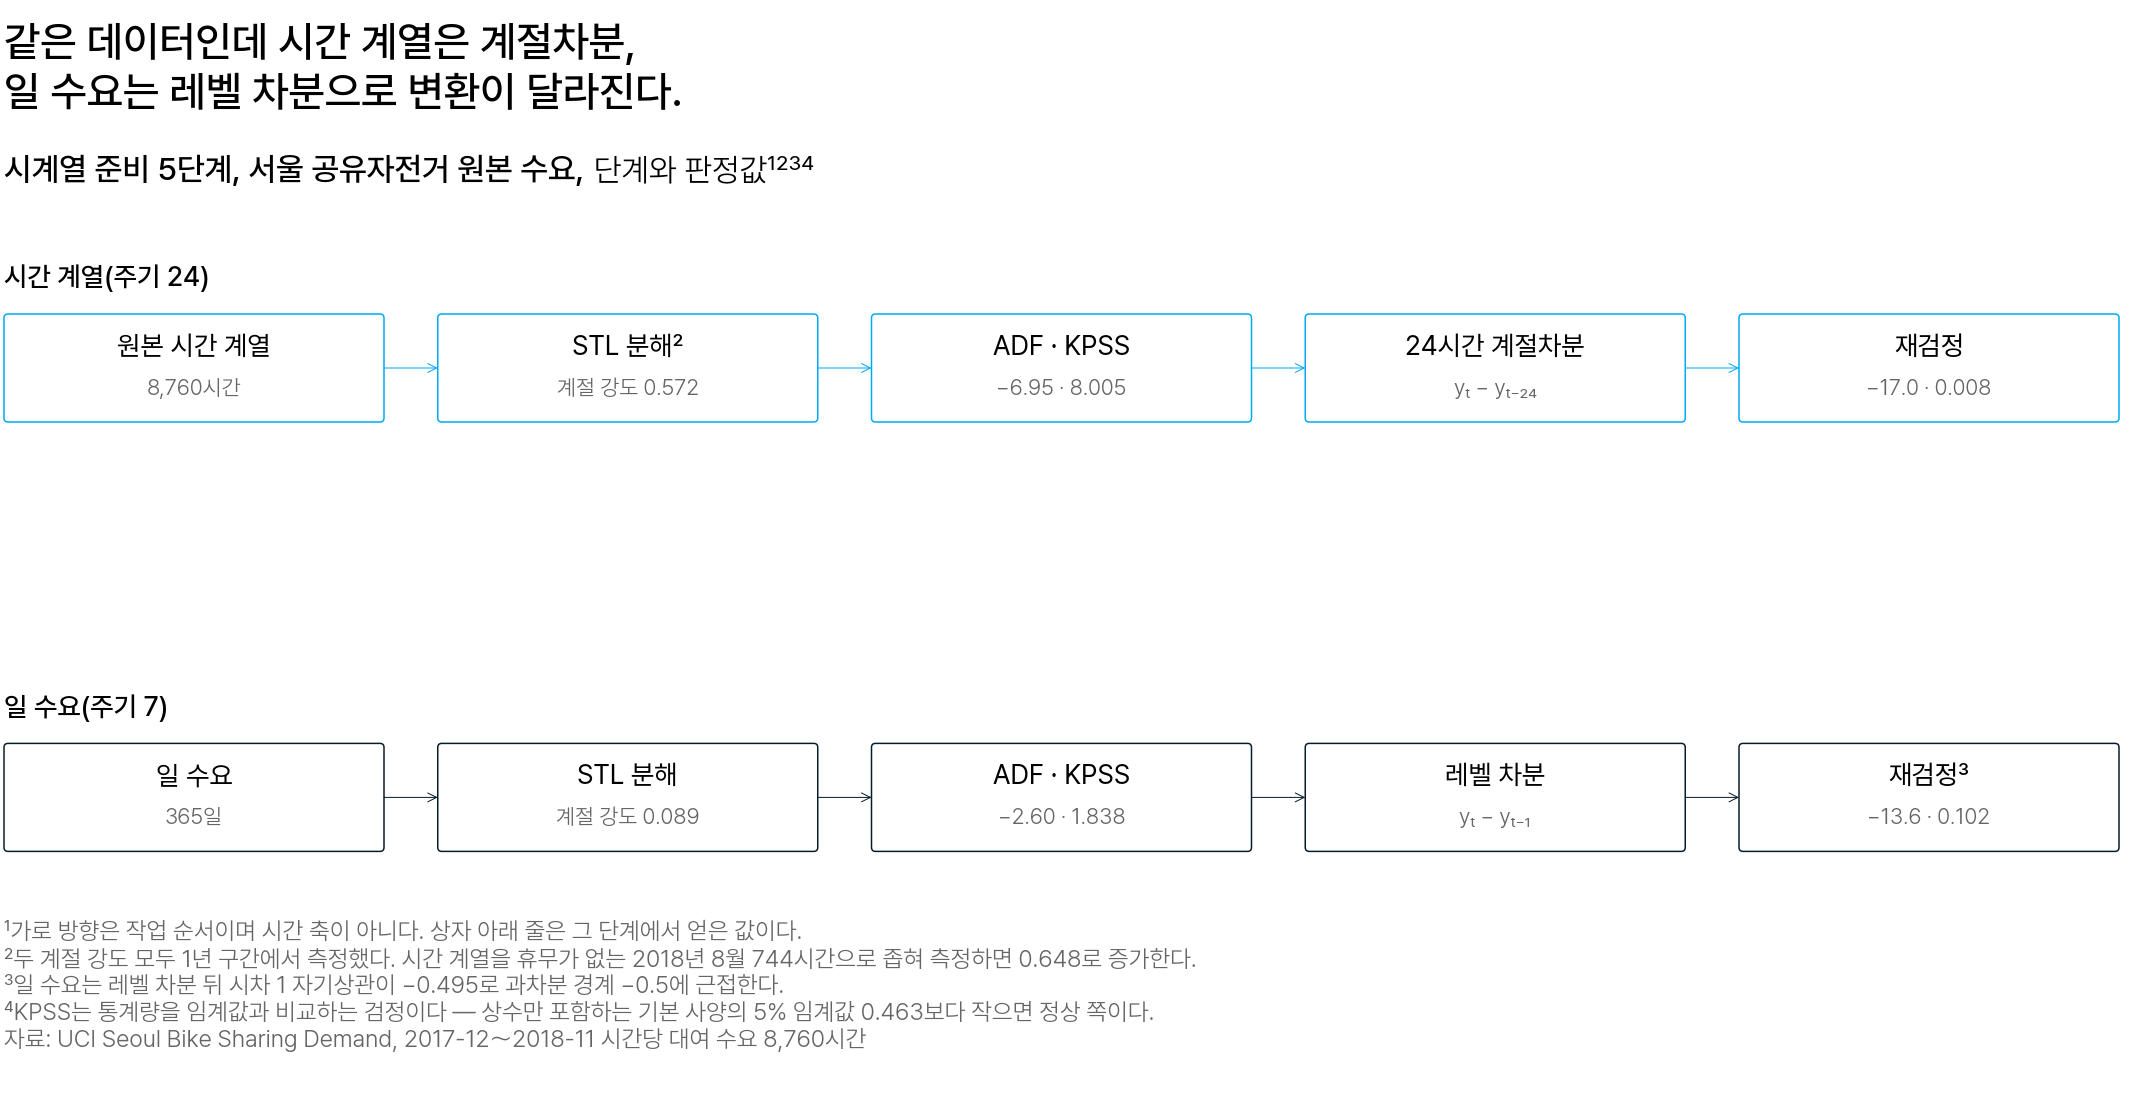

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 오늘의 한 장 요약 — 가로가 준비 5단계이고 넷째 단계에서 변환이 갈린다</em></p>

상자 아래의 ADF·KPSS 값은 p값이 아니라 검정통계량입니다. 상수항만 포함하는 검정식의 5% 임계값과 견줍니다. ADF 임계값은 표본 수에 따라 달라져 8,760시간에서는 −2.86, 365일에서는 −2.87 입니다. KPSS 임계값은 0.463 입니다.

ADF 는 임계값보다 더 음수면 정상 쪽이고, KPSS 는 작으면 정상 쪽입니다.

둘째 상자의 계절 강도는 두 행 모두 1년 구간에서 측정했습니다.

**시간 계열(주기 24)** 위 행은 시간당 수요 8,760시간입니다. 원본은 ADF −6.95 · KPSS 8.005 로 두 답의 방향이 반대입니다. 계절차분 뒤 재검정은 ADF −17.0 · KPSS 0.008 로 둘 다 정상 쪽입니다.

**일 수요(주기 7)** 아래 행은 하루씩 더한 365일입니다. 원본은 ADF −2.60 · KPSS 1.838 로 둘 다 비정상 쪽입니다. 레벨 차분 뒤 재검정은 ADF −13.6 · KPSS 0.102 로 둘 다 정상 쪽입니다.

각주 ³ 의 −0.495 는 과차분 신호가 아닙니다. 차분 전 판정이 비정상이었습니다.

**넷째 단계는 무엇으로 고르는가** 계절 성분이 남아 있으면 계절차분, 수준이 한 방향으로 옮겨 가면 레벨 차분입니다. 일 수요는 ADF 가 단위근을 기각하지 못했고 KPSS 는 정상을 기각했습니다. 요일 주기가 없고 수준이 옮겨 가는 쪽이라 레벨 차분입니다.

겨울과 여름의 차이는 자료가 1년치라 한 번만 나타납니다. 되풀이를 확인할 수 없어 계절 성분으로 두지 않습니다.

<details class="lms-extra"><summary>더 깊이 — 한 번 더 차분해도 되는가, 보고서에 적을 설정</summary>

**일 수요를 한 번 더 차분해도 되는가.** −0.5 는 이미 정상이던 계열을 한 번 더 차분할 때 나오는 이론값입니다. 일 수요의 분산은 레벨 차분으로 오히려 전의 0.71배가 되었습니다. 한 번 더 빼면 커집니다.

**사양** 은 검정식에 상수항만 넣을지 추세항까지 넣을지 고르는 설정입니다. 본문에 인용한 임계값은 모두 상수만 포함하는 기본 사양의 값입니다. 상수와 추세를 함께 포함하는 사양으로 바꾸면 같은 통계량이 다른 판정을 받습니다.

그래서 보고서에는 통계량과 함께 어느 사양의 몇 % 임계값과 비교했는지, 표본이 몇 개인지 적습니다. 집계 단위도 분석자가 고르는 값이므로 「1시간 간격 · 계절 주기 24」를 함께 적습니다.

**주 단위로 모으면 어떻게 되는가.** 하루 안의 오르내림이 한 값에 들어가 주기 24 의 계절 성분이 남지 않고, 계절차분할 대상이 없어집니다. 반대로 분 단위로 보려면 하루 한 주기가 24시점에서 1,440시점으로 늘어납니다. 계절 성분의 값 1,440개를 정해야 하는데 값 하나를 뒷받침하는 날은 365일 그대로입니다.

</details>

## 오늘의 정리

| 주제 | 질문 | 답 |
|---|---|---|
| 1 | 행 순서를 재배열하면 무엇이 사라지는가 | 위치가 사라져 되살릴 수 없다 |
| 2 | 계열의 한 시점은 무엇인가 | 한 시각과 그 시각의 값이다 |
| 3 | 겹쳐 있는 성분을 어떻게 분리하는가 | 가법·승법을 고르고 STL 로 분해한다 |
| 4 | 두 주기의 계절 강도는 얼마인가 | 주기 24 는 0.572, 주기 7 은 0.089 |
| 5 | 계절 성분을 숫자로 어떻게 확인하는가 | 자기상관을 판정선과 비교한다 |
| 6 | 과거의 규칙을 미래에 써도 되는 조건은 무엇인가 | 평균·분산·자기공분산이 시점에 의존하지 않는다 |
| 7 | 눈으로 하던 판정을 어떻게 검정으로 바꾸는가 | 귀무가설이 반대인 두 검정을 함께 본다 |
| 8 | 비정상이면 무엇을 적용하는가 | 원인에 맞는 차분 뒤 다시 검정한다 |

둘째 날로 전달하는 값은 시간당 수요 쪽 판정입니다. 계절 주기 24, 계절차분 1회, 레벨 차분 0회입니다. 일 수요의 레벨 차분 1회는 비교로 본 값이라 전달하지 않습니다.

<details class="lms-extra"><summary>더 깊이 — 학습 구간과 검증 구간 · 둘째 날의 설정값</summary>

이 세 값(주기 24 · 계절차분 1회 · 레벨 차분 0회)은 시간당 수요 1년 8,760시간에서 정했습니다. 실무에서는 뒷부분을 떼고 앞부분으로 정합니다. 값을 정하는 앞부분이 **학습 구간(training set)** 입니다. 떼어 둔 뒷부분이 **검증 구간(validation set)** 입니다.

마지막 744시간을 떼면 학습 구간 8,016시간에서 세 값을 정하고 남은 744시간으로 맞았는지 봅니다.

둘째 날에는 이 변환을 적용해 첫 예측 모형을 만듭니다. 세 값이 그대로 설정값이 됩니다. 주기 24 는 $m = 24$, 계절차분 1회는 $D = 1$, 레벨 차분 0회는 $d = 0$ 입니다.

</details>

외부 그림은 대부분 fpp3 3판(otexts.com/fpp3)에서 왔습니다. fpp3 는 Hyndman 과 Athanasopoulos 의 교재입니다. 원제는 *Forecasting: Principles and Practice* 입니다.

## 팀장의 질문에 대한 답과 수업에서 다룰 질문

먼저 팀장이 물은 두 가지에 답하고, 마지막에 답이 갈리는 질문 하나를 남깁니다. 첫째, 계절 주기는 7일이 아니라 24시간입니다. 둘째, 시간당 수요를 원본 그대로 예측 모형에 입력할 수는 없습니다. 24시간 계절차분을 한 번 해야 과거에서 찾은 규칙을 미래에 그대로 쓸 수 있습니다.

<div style="background:linear-gradient(135deg,#faf6ee,#f0e6d2);color:#5a4a33;padding:28px;border-radius:12px;border:1px solid #e0d5bd;margin-top:18px">
<h2 style="color:#5a4a33;margin:0 0 10px 0">오늘의 한 문장</h2>
<div style="font-size:1.05em">"정상성 확보는 예측을 해결하는 일이 아닙니다. 모형이 다룰 형태를 만드는 준비이고, 그 준비는 집계 단위에 따라 달라집니다."</div>
</div>

아래 문항이 그 질문입니다. 각자 답을 정한 뒤 팀의 답과 대조합니다.

> **[문제] 팀 라운드 — 두 검정이 엇갈릴 때 변환을 정하는 근거**
>
> 시간당 수요 8,760시간에 두 검정을 적용하면 ADF 통계량은 −6.95 로 "단위근이 있다"를 강하게 기각하고, KPSS 통계량은 8.005 로 "정상이다"도 강하게 기각합니다. ADF·KPSS 판정 조합표의 넷째 조합, 두 검정이 서로 다른 방향을 지시하는 경우입니다. 둘째 날 이 계열을 예측 모형에 입력해야 하는데, 어떤 차분을 적용할지 팀 안에서 의견이 3가지로 나뉘었습니다.
> 
> - **관점 A — 검정 결과를 그대로 따른다.** ADF 가 단위근을 기각했으니 레벨 차분은 필요 없다. KPSS 가 판정한 비정상의 원인은 주기 24 의 계절 성분이므로 24시간 계절차분만 적용하고, 재검정에서 ADF −17.0 · KPSS 0.008 로 두 검정이 합의했으니 그것으로 마친다. 판정 규칙을 정했으면 그 규칙대로 읽는 것이 원칙이다.
> - **관점 B — 그림과 자기상관을 먼저 본다.** 검정은 계열 전체에 숫자 하나를 부여하는 방법이라 어디가 문제인지 알려 주지 않는다. ACF 시차 1 이 0.903, 시차 24 가 0.681 인 것과 1년 8,760시간에서 측정한 계절 강도 0.572 를 함께 보고 차분을 정해야 하며, 계절차분 뒤에 시차 1 의 자기상관이 남아 있다면 레벨 차분을 한 번 더 적용할지 검토해야 한다.
> - **관점 C — 계열 전체에 한 번 검정하는 것 자체가 문제다.** 이 1년 계열에는 겨울 평균 225.5대/시간과 여름 평균 1,034.1대/시간가 함께 들어 있고 휴무 295시간까지 포함되어 있다. 이렇게 성질이 다른 구간이 함께 있는 계열에 검정 하나를 적용해 나온 판정으로 변환을 정하기보다, 구간을 나눠 판정하거나 휴무를 먼저 정리한 뒤 다시 검정해야 한다.
> 
> 자기 입장 하나와 근거 3가지, 그리고 확신도를 정해 오십시오.